In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
dmo = pd.read_csv('daily_mess_operations.csv')

# Cleaning daily_mess_operations.csv

In [4]:
dmo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114425 entries, 0 to 114424
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Record_ID                      114425 non-null  object 
 1   Date                           114425 non-null  object 
 2   Mess_Hall_ID                   114425 non-null  object 
 3   Day_of_Week                    114425 non-null  object 
 4   Meal_Type                      114425 non-null  object 
 5   Menu_Item                      114425 non-null  object 
 6   Cuisine_Category               114425 non-null  object 
 7   Food_Type                      114425 non-null  object 
 8   Contains_Egg                   111130 non-null  object 
 9   Contains_Dairy                 114425 non-null  bool   
 10  Protein_Content_Category       102893 non-null  object 
 11  Is_Served_On_Separate_Counter  114425 non-null  bool   
 12  Is_Special_Menu               

In [5]:
dmo.describe()

,Food_Prepared_kg,Food_Consumed_kg,Food_Wasted_kg,Waste_Percentage,Cost_Per_Kg_INR,Serving_Size_Per_Student_g,Leftover_Redistribution_kg
count,114425.000000,114425.000000,114425.000000,114425.000000,112743.000000,114425.000000,81960.000000
mean,51.670184,42.130368,9.371023,18.857577,170.478252,333.138963,3.571856
std,39.486891,31.942091,7.967706,9.488195,101.458495,382.389190,3.412567
min,0.000000,0.000000,-32.146926,0.880000,51.650000,0.000000,0.000000
25%,20.000000,14.000000,3.020000,14.130000,98.440000,79.400000,1.000000
50%,40.000000,33.510000,7.020000,18.280000,127.120000,284.500000,2.460000
75%,100.000000,77.880000,14.620000,22.780000,213.890000,396.800000,5.140000
max,696.759845,150.810000,57.710000,179.928033,585.600000,7666.700000,26.870000


In [6]:
dmo.sample(10)

,Record_ID,Date,Mess_Hall_ID,Day_of_Week,Meal_Type,Menu_Item,Cuisine_Category,Food_Type,Contains_Egg,Contains_Dairy,...,Food_Consumed_kg,Food_Wasted_kg,Waste_Percentage,Cost_Per_Kg_INR,Serving_Size_Per_Student_g,Leftover_Redistribution_kg,Cook_on_Duty,Mess_Supervisor_ID,Preparation_Start_Time,Service_End_Time
69943,OPS-20240203-MH_A-0005,2024-02-03,MH_A,Saturday,Lunch,Bisi Bele Bath,South Indian,Veg,False,False,...,90.160000,9.840000,9.84,116.95,377.4,3.06,C014,SUP02,12:00,1430
64370,OPS-20231105-MH_A-0014,2023-11-05,MH_A,Sunday,Dinner,Chicken Masala,North Indian,Non_Veg,False,False,...,25.930000,6.750000,20.64,246.12,81.5,1.52,C016,SUP06,19:30,22:00
6774,OPS-20210420-MH_A-0019,2021-04-20,MH_A,Tuesday,Dinner,Halwa,Sweet-Dessert,Veg,False,True,...,34.030000,5.970000,13.14,203.84,259.7,NaN,C015,SUP03,19:30,10:00 PM
30972,OPS-20220515-MH_A-0016,2022-05-15,MH_A,Sunday,Dinner,Aloo Gobi,North Indian,Veg,False,False,...,92.080000,22.920000,17.54,92.61,497.8,NaN,C015,NaN,19:30,22:00
86990,OPS-20241104-MH_A-0002,2024-11-04,MH_A,Monday,Breakfast,Bread-Butter,Continental,Veg,False,True,...,43.440000,15.350000,29.25,89.15,314.4,5.37,C022,NaN,0630,9:00 AM
113464,OPS-20221023-MH_B-0007,2022-10-23,MH_B,Sunday,Lunch,Egg Fried Rice,Continental,Egg,True,False,...,21.398001,-2.638001,30.35,182.73,78.8,1.02,C023,SUP03,12:00,14:30
3695,OPS-20210301-MH_B-0013,2021-03-01,MH_B,Monday,Snacks,Tea,Continental,Veg,False,True,...,14.860000,3.090000,17.23,59.98,142.5,NaN,C014,SUP06,16:30,18:30
31680,OPS-20220526-MH_B-0017,2022-05-26,MH_B,Thursday,Dinner,Gulab Jamun,Sweet-Dessert,veg,False,False,...,79.790000,20.210000,20.21,258.42,336.7,4.04,C021,SUP04,1930,22:00
62370,OPS-20231004-MH_A-0004,2023-10-04,MH_A,Wednesday,Breakfast,Boiled Eggs,Continental,Egg,True,False,...,9.390000,3.980000,29.77,146.76,52.2,1.20,C014,SUP06,06:30,09:00
112716,OPS-20251223-MH_G-0012,"December 23, 2025",MH_G,Tuesday,Lunch,Sambar Rice,South Indian,Veg,False,False,...,76.170000,23.830000,20.97,110.53,1428.6,4.05,C015,SUP04,12:00,14:30


In [7]:
dmo["Date"] = pd.to_datetime(
    dmo["Date"],
    dayfirst=True,
    errors="coerce"
)

In [8]:
dmo[dmo["Date"].isna()]

,Record_ID,Date,Mess_Hall_ID,Day_of_Week,Meal_Type,Menu_Item,Cuisine_Category,Food_Type,Contains_Egg,Contains_Dairy,...,Food_Consumed_kg,Food_Wasted_kg,Waste_Percentage,Cost_Per_Kg_INR,Serving_Size_Per_Student_g,Leftover_Redistribution_kg,Cook_on_Duty,Mess_Supervisor_ID,Preparation_Start_Time,Service_End_Time


In [9]:
print(dmo)

                     Record_ID       Date Mess_Hall_ID Day_of_Week  Meal_Type  \
0       OPS-20210101-MH_A-0001 2021-01-01         MH_A      Friday  Breakfast   
1       OPS-20210101-MH_A-0002 2021-01-01         MH_A      Friday  Breakfast   
2       OPS-20210101-MH_A-0003 2021-01-01         MH_A      Friday  Breakfast   
3       OPS-20210101-MH_A-0004 2021-01-01         MH_A      Friday  Breakfast   
4       OPS-20210101-MH_A-0005 2021-01-01         MH_A      Friday      Lunch   
...                        ...        ...          ...         ...        ...   
114420  OPS-20240623-MH_A-0012 2024-06-23         MH_A      Sunday     Snacks   
114421  OPS-20230820-MH_B-0006 2023-08-20         MH_B      Sunday      Lunch   
114422  OPS-20210726-MH_G-0009 2021-07-26         MH_G      Monday      Lunch   
114423  OPS-20220524-MH_G-0017 2022-05-24         MH_G     Tuesday     Dinner   
114424  OPS-20240430-MH_A-0017 2024-04-30         MH_A     Tuesday     Dinner   

             Menu_Item Cuis

In [10]:
dmo.columns = (
    dmo.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [11]:
dmo.duplicated().sum()

1173

In [12]:
dmo = dmo.drop_duplicates()

In [13]:
cat_cols = [
    "mess_hall_id",
    "day_of_week",
    "meal_type",
    "menu_item",
    "cuisine_category",
    "food_type",
    "protein_content_category",
    "cook_on_duty",
    "mess_supervisor_id"
]

for col in cat_cols:
    dmo[col] = dmo[col].astype(str).str.strip()

In [14]:
dmo["record_id"].duplicated().sum()

27

In [15]:
dup_records = dmo[dmo["record_id"].duplicated(keep=False)]

dup_records.sort_values("record_id")

,record_id,date,mess_hall_id,day_of_week,meal_type,menu_item,cuisine_category,food_type,contains_egg,contains_dairy,...,food_consumed_kg,food_wasted_kg,waste_percentage,cost_per_kg_inr,serving_size_per_student_g,leftover_redistribution_kg,cook_on_duty,mess_supervisor_id,preparation_start_time,service_end_time
6102,OPS-20210409-MH_B-0010,2021-04-09,MH_B,Friday,Lunch,Dal Fry,North Indian,Veg,False,False,...,52.340000,17.660000,28.250000,93.56,278.9,NaN,C022,SUP03,1200,14:30
113449,OPS-20210409-MH_B-0010,2021-04-09,MH_B,Friday,Lunch,Dal Fry,North Indian,Veg,False,False,...,52.340000,17.660000,28.250000,93.56,278.9,NaN,C022,SUP03,1200,1200
6970,OPS-20210423-MH_B-0010,2021-04-23,MH_B,Friday,Lunch,Keema Matar,North Indian,Non_Veg,False,False,...,6.490000,1.510000,18.830000,202.14,37.6,NaN,C005,SUP07,12:00,14:30
113442,OPS-20210423-MH_B-0010,2021-04-23,MH_B,Friday,Lunch,Keema Matar,North Indian,Non_Veg,False,False,...,9.835639,-1.835639,18.830000,202.14,37.6,NaN,C005,SUP07,12:00,14:30
10132,OPS-20210613-MH_B-0003,2021-06-13,MH_B,Sunday,Breakfast,Bread-Omelette,Continental,Egg,True,False,...,2.590000,1.090000,26.050000,142.61,167.3,NaN,C003,nan,0630,09:00
113351,OPS-20210613-MH_B-0003,2021-06-13,MH_B,Sunday,Breakfast,Bread-Omelette,Continental,Egg,True,False,...,4.390146,-0.710146,26.050000,142.61,167.3,NaN,C003,nan,0630,09:00
10910,OPS-20210625-MH_G-0015,2021-06-25,MH_G,Friday,Dinner,Dal Tadka,North Indian,Veg,False,False,...,33.520000,6.480000,18.130000,97.14,2105.3,NaN,C004,SUP02,19:30,19:30
113638,OPS-20210625-MH_G-0015,2021-06-25,MH_G,Friday,Dinner,Dal Tadka,North Indian,Veg,False,False,...,33.520000,6.480000,18.130000,97.14,2105.3,NaN,C004,SUP02,19:30,10:00 PM
11103,OPS-20210628-MH_G-0020,2021-06-28,MH_G,Monday,Dinner,Jain Dal,North Indian,Jain,False,False,...,2.473766,-0.333766,4.010000,107.28,44.6,NaN,C004,SUP02,19:30,22:00
114208,OPS-20210628-MH_G-0020,2021-06-28,MH_G,Monday,Dinner,Jain Dal,North Indian,Jain,False,False,...,2.060000,0.080000,4.010000,107.28,44.6,NaN,C004,SUP02,19:30,22:00


In [16]:
dup_records = dmo[dmo["record_id"].duplicated(keep=False)]

print(dup_records.shape)

dup_records.sort_values("record_id").head(20)

(54, 24)


,record_id,date,mess_hall_id,day_of_week,meal_type,menu_item,cuisine_category,food_type,contains_egg,contains_dairy,...,food_consumed_kg,food_wasted_kg,waste_percentage,cost_per_kg_inr,serving_size_per_student_g,leftover_redistribution_kg,cook_on_duty,mess_supervisor_id,preparation_start_time,service_end_time
6102,OPS-20210409-MH_B-0010,2021-04-09,MH_B,Friday,Lunch,Dal Fry,North Indian,Veg,False,False,...,52.340000,17.660000,28.250000,93.56,278.9,NaN,C022,SUP03,1200,14:30
113449,OPS-20210409-MH_B-0010,2021-04-09,MH_B,Friday,Lunch,Dal Fry,North Indian,Veg,False,False,...,52.340000,17.660000,28.250000,93.56,278.9,NaN,C022,SUP03,1200,1200
6970,OPS-20210423-MH_B-0010,2021-04-23,MH_B,Friday,Lunch,Keema Matar,North Indian,Non_Veg,False,False,...,6.490000,1.510000,18.830000,202.14,37.6,NaN,C005,SUP07,12:00,14:30
113442,OPS-20210423-MH_B-0010,2021-04-23,MH_B,Friday,Lunch,Keema Matar,North Indian,Non_Veg,False,False,...,9.835639,-1.835639,18.830000,202.14,37.6,NaN,C005,SUP07,12:00,14:30
10132,OPS-20210613-MH_B-0003,2021-06-13,MH_B,Sunday,Breakfast,Bread-Omelette,Continental,Egg,True,False,...,2.590000,1.090000,26.050000,142.61,167.3,NaN,C003,nan,0630,09:00
113351,OPS-20210613-MH_B-0003,2021-06-13,MH_B,Sunday,Breakfast,Bread-Omelette,Continental,Egg,True,False,...,4.390146,-0.710146,26.050000,142.61,167.3,NaN,C003,nan,0630,09:00
10910,OPS-20210625-MH_G-0015,2021-06-25,MH_G,Friday,Dinner,Dal Tadka,North Indian,Veg,False,False,...,33.520000,6.480000,18.130000,97.14,2105.3,NaN,C004,SUP02,19:30,19:30
113638,OPS-20210625-MH_G-0015,2021-06-25,MH_G,Friday,Dinner,Dal Tadka,North Indian,Veg,False,False,...,33.520000,6.480000,18.130000,97.14,2105.3,NaN,C004,SUP02,19:30,10:00 PM
11103,OPS-20210628-MH_G-0020,2021-06-28,MH_G,Monday,Dinner,Jain Dal,North Indian,Jain,False,False,...,2.473766,-0.333766,4.010000,107.28,44.6,NaN,C004,SUP02,19:30,22:00
114208,OPS-20210628-MH_G-0020,2021-06-28,MH_G,Monday,Dinner,Jain Dal,North Indian,Jain,False,False,...,2.060000,0.080000,4.010000,107.28,44.6,NaN,C004,SUP02,19:30,22:00


In [17]:
dmo["quality_score"] = 0

# Waste cannot be negative
dmo["quality_score"] += (dmo["food_wasted_kg"] >= 0).astype(int)

# Consumed cannot be negative
dmo["quality_score"] += (dmo["food_consumed_kg"] >= 0).astype(int)

# Waste percentage should be valid
dmo["quality_score"] += (
    (dmo["waste_percentage"] >= 0) &
    (dmo["waste_percentage"] <= 100)
).astype(int)

# Consumed <= Prepared
dmo["quality_score"] += (
    dmo["food_consumed_kg"] <= dmo["food_prepared_kg"]
).astype(int)

# Waste <= Prepared
dmo["quality_score"] += (
    dmo["food_wasted_kg"] <= dmo["food_prepared_kg"]
).astype(int)

# Menu item present
dmo["quality_score"] += dmo["menu_item"].notna().astype(int)

# Supervisor present
dmo["quality_score"] += dmo["mess_supervisor_id"].notna().astype(int)

# Cook present
dmo["quality_score"] += dmo["cook_on_duty"].notna().astype(int)

In [18]:
dmo_clean = (
    dmo
    .sort_values(
        by="quality_score",
        ascending=False
    )
    .drop_duplicates(
        subset="record_id",
        keep="first"
    )
)

In [19]:
print(
    dmo_clean["record_id"]
    .duplicated()
    .sum()
)

0


In [20]:
removed_rows = pd.concat([
    dmo,
    dmo_clean
]).drop_duplicates(keep=False)

In [21]:
removed_rows[
    ["record_id",
     "food_prepared_kg",
     "food_consumed_kg",
     "food_wasted_kg",
     "waste_percentage",
     "quality_score"]
]

,record_id,food_prepared_kg,food_consumed_kg,food_wasted_kg,waste_percentage,quality_score
6102,OPS-20210409-MH_B-0010,70.00,52.340000,17.660000,28.250000,8
10910,OPS-20210625-MH_G-0015,40.00,33.520000,6.480000,18.130000,8
11103,OPS-20210628-MH_G-0020,2.14,2.473766,-0.333766,4.010000,6
25898,OPS-20220222-MH_A-0006,70.00,57.810000,12.190000,17.420000,8
26854,OPS-20220309-MH_B-0018,20.00,15.670000,4.330000,160.493803,7
31704,OPS-20220526-MH_G-0020,100.00,109.981607,-9.981607,10.010000,6
32632,OPS-20220610-MH_G-0016,8.00,7.350000,0.650000,7.130000,8
71305,OPS-20240225-MH_A-0003,9.20,7.490000,-16.883086,20.800000,7
74154,OPS-20240410-MH_G-0009,100.00,90.030000,9.970000,123.002689,7
93156,OPS-20250211-MH_B-0016,115.00,97.400000,17.600000,13.470000,8


In [22]:
duplicate_count_before = (
    dmo["record_id"]
    .duplicated()
    .sum()
)

duplicate_count_after = (
    dmo_clean["record_id"]
    .duplicated()
    .sum()
)

print(
    f"Duplicate Record IDs Removed: "
    f"{duplicate_count_before - duplicate_count_after}"
)

Duplicate Record IDs Removed: 27


In [23]:
dmo_clean["record_id"].duplicated().sum()

0

In [24]:
dmo_clean["meal_type"] = dmo_clean["meal_type"].str.title()
dmo_clean["day_of_week"] = dmo_clean["day_of_week"].str.title()
dmo_clean["cuisine_category"] = dmo_clean["cuisine_category"].str.title()
dmo_clean["food_type"] = dmo_clean["food_type"].str.title()


In [25]:
bool_cols = [
    "contains_egg",
    "contains_dairy",
    "is_served_on_separate_counter",
    "is_special_menu"
]

for col in bool_cols:
    print(col)
    print(dmo_clean[col].unique())

contains_egg
[False True nan]
contains_dairy
[False  True]
is_served_on_separate_counter
[False  True]
is_special_menu
[False  True]


In [26]:
dmo_clean.isnull().sum().sort_values(ascending=False)

leftover_redistribution_kg       32111
contains_egg                      3256
cost_per_kg_inr                   1666
record_id                            0
food_prepared_kg                     0
service_end_time                     0
preparation_start_time               0
mess_supervisor_id                   0
cook_on_duty                         0
serving_size_per_student_g           0
waste_percentage                     0
food_wasted_kg                       0
food_consumed_kg                     0
is_special_menu                      0
date                                 0
is_served_on_separate_counter        0
protein_content_category             0
contains_dairy                       0
food_type                            0
cuisine_category                     0
menu_item                            0
meal_type                            0
day_of_week                          0
mess_hall_id                         0
quality_score                        0
dtype: int64

In [27]:
dmo_clean["leftover_redistribution_kg"].describe()

count    81114.000000
mean         3.571474
std          3.411697
min          0.000000
25%          1.000000
50%          2.460000
75%          5.140000
max         26.870000
Name: leftover_redistribution_kg, dtype: float64

In [28]:
dmo_clean["leftover_redistribution_kg"] = (
    dmo_clean["leftover_redistribution_kg"]
    .fillna(0)
)

In [29]:
dmo_clean.groupby("food_type")["contains_egg"].value_counts(dropna=False)

food_type   contains_egg
Egg         True            15917
            NaN               502
Jain        False            4317
            NaN               131
Non-Veg     False             353
            NaN                11
Non_Veg     False           19562
            NaN               577
            True               14
Nonveg      False             338
            NaN                12
Nv          False             339
            NaN                 3
Veg         False           66464
            NaN              1952
Vegan       False            1523
            NaN                39
Vegetarian  False            1142
            NaN                29
Name: contains_egg, dtype: int64

In [30]:
dmo_clean["food_type"].value_counts(dropna=False)

Veg           68416
Non_Veg       20153
Egg           16419
Jain           4448
Vegan          1562
Vegetarian     1171
Non-Veg         364
Nonveg          350
Nv              342
Name: food_type, dtype: int64

In [31]:
sorted(dmo_clean["food_type"].astype(str).unique())

['Egg',
 'Jain',
 'Non-Veg',
 'Non_Veg',
 'Nonveg',
 'Nv',
 'Veg',
 'Vegan',
 'Vegetarian']

In [32]:
food_type_mapping = {
    "Vegetarian": "Veg",
    "Non-Veg": "Non_Veg",
    "Nonveg": "Non_Veg",
    "Nv": "Non_Veg"
}

dmo_clean["food_type"] = (
    dmo_clean["food_type"]
    .replace(food_type_mapping)
)

In [33]:
dmo_clean["food_type"].value_counts()

Veg        69587
Non_Veg    21209
Egg        16419
Jain        4448
Vegan       1562
Name: food_type, dtype: int64

In [34]:
dmo_clean.groupby("food_type")["contains_egg"].value_counts(dropna=False)

food_type  contains_egg
Egg        True            15917
           NaN               502
Jain       False            4317
           NaN               131
Non_Veg    False           20592
           NaN               603
           True               14
Veg        False           67606
           NaN              1981
Vegan      False            1523
           NaN                39
Name: contains_egg, dtype: int64

In [35]:
dmo_clean["cuisine_category"].value_counts(dropna=False)

North Indian     67757
Continental      19795
South Indian     17912
Sweet-Dessert     4679
Street Food       3082
Name: cuisine_category, dtype: int64

In [36]:
pd.crosstab(
    dmo_clean["food_type"],
    dmo_clean["contains_egg"],
    margins=True
)

contains_egg,False,True,All
food_type,,,
Egg,0,15917,15917
Jain,4317,0,4317
Non_Veg,20592,14,20606
Veg,67606,0,67606
Vegan,1523,0,1523
All,94038,15931,109969


In [37]:
dmo_clean[
    (dmo_clean["food_type"] == "Non_Veg") &
    (dmo_clean["contains_egg"] == True)
][[
    "menu_item",
    "food_type",
    "contains_egg"
]].drop_duplicates()

,menu_item,food_type,contains_egg
74624,Mutton Curry,Non_Veg,True
58112,Prawn Masala,Non_Veg,True
105774,Fish Fry,Non_Veg,True
107691,Chicken Soup,Non_Veg,True
9821,Keema Matar,Non_Veg,True


In [38]:
dmo_clean.loc[
    (dmo_clean["food_type"] == "Non_Veg") &
    (dmo_clean["contains_egg"] == True),
    "contains_egg"
] = False

In [39]:
pd.crosstab(
    dmo_clean["food_type"],
    dmo_clean["contains_egg"],
    margins=True
)

contains_egg,False,True,All
food_type,,,
Egg,0,15917,15917
Jain,4317,0,4317
Non_Veg,20606,0,20606
Veg,67606,0,67606
Vegan,1523,0,1523
All,94052,15917,109969


In [40]:
dmo_clean["contains_egg"].isna().sum()

3256

In [41]:
dmo_clean.loc[
    (dmo_clean["food_type"] == "Egg") &
    (dmo_clean["contains_egg"].isna()),
    "contains_egg"
] = True

In [42]:
dmo_clean["contains_egg"] = (
    dmo_clean["contains_egg"]
    .fillna(False)
)

In [43]:
dmo_clean["contains_egg"].isna().sum()

0

In [44]:
dmo_clean["cuisine_category"].value_counts(dropna=False)

North Indian     67757
Continental      19795
South Indian     17912
Sweet-Dessert     4679
Street Food       3082
Name: cuisine_category, dtype: int64

In [45]:
dmo_clean["protein_content_category"].value_counts(dropna=False)

High      42789
Low       40622
Medium    18406
nan       11408
Name: protein_content_category, dtype: int64

In [46]:
dmo_clean["protein_content_category"].isna().sum()

0

In [47]:
dmo_clean["protein_content_category"].unique()

array(['Low', 'Medium', 'High', 'nan'], dtype=object)

In [48]:
dmo_clean["protein_content_category"] = (
    dmo_clean["protein_content_category"]
    .replace("nan", np.nan)
)

In [49]:
dmo_clean["protein_content_category"].isna().sum()

11408

In [50]:
dmo_clean["protein_content_category"].value_counts(dropna=False)

High      42789
Low       40622
Medium    18406
NaN       11408
Name: protein_content_category, dtype: int64

In [51]:
dmo_clean.groupby("food_type")[
    "protein_content_category"
].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

food_type
Egg        High
Jain        Low
Non_Veg    High
Veg         Low
Vegan       Low
Name: protein_content_category, dtype: object

In [52]:
protein_map = {
    "Egg": "High",
    "Non_Veg": "High",
    "Veg": "Low",
    "Vegan": "Low",
    "Jain": "Low"
}

dmo_clean["protein_content_category"] = (
    dmo_clean["protein_content_category"]
    .fillna(
        dmo_clean["food_type"].map(protein_map)
    )
)

In [53]:
dmo_clean["protein_content_category"].isna().sum()

0

In [54]:
pd.crosstab(
    dmo_clean["food_type"],
    dmo_clean["protein_content_category"],
    margins=True
)

protein_content_category,High,Low,Medium,All
food_type,,,,
Egg,12342,0,4077,16419
Jain,0,2481,1967,4448
Non_Veg,18584,57,2568,21209
Veg,15638,44155,9794,69587
Vegan,0,1562,0,1562
All,46564,48255,18406,113225


In [55]:
dmo_clean[
    (dmo_clean["food_type"] == "Non_Veg") &
    (dmo_clean["protein_content_category"] == "Low")
][[
    "menu_item",
    "food_type",
    "protein_content_category"
]].drop_duplicates()

,menu_item,food_type,protein_content_category
75278,Chicken Soup,Non_Veg,Low
76608,Fish Fry,Non_Veg,Low
78058,Chicken Biryani,Non_Veg,Low
80494,Keema Matar,Non_Veg,Low
79594,Chicken Masala,Non_Veg,Low
56436,Prawn Masala,Non_Veg,Low
89604,Mutton Curry,Non_Veg,Low


In [56]:
dmo_clean.loc[
    (dmo_clean["food_type"] == "Non_Veg") &
    (dmo_clean["protein_content_category"] == "Low"),
    "protein_content_category"
] = "High"

In [57]:
pd.crosstab(
    dmo_clean["food_type"],
    dmo_clean["protein_content_category"]
)

protein_content_category,High,Low,Medium
food_type,,,
Egg,12342,0,4077
Jain,0,2481,1967
Non_Veg,18641,0,2568
Veg,15638,44155,9794
Vegan,0,1562,0


In [58]:
dmo_clean["cost_per_kg_inr"].describe()

count    111559.000000
mean        170.488348
std         101.468479
min          51.650000
25%          98.450000
50%         127.110000
75%         213.895000
max         585.600000
Name: cost_per_kg_inr, dtype: float64

In [59]:
dmo_clean.groupby("menu_item")["cost_per_kg_inr"].agg(
    ["count","mean","median"]
).head(20)

,count,mean,median
menu_item,,,
Aloo Dum,1179,96.425598,96.640
Aloo Gobi,2672,99.130902,97.420
Aloo Paratha,1450,112.818800,112.625
Baingan Bharta,1182,90.360305,90.360
Bhel Puri,1562,112.795743,112.745
Bisi Bele Bath,1177,113.253551,113.390
Boiled Eggs,1773,135.612933,135.350
Bread-Butter,1455,90.183210,89.960
Bread-Omelette,1770,158.200017,157.350


In [60]:
dmo_clean["cost_per_kg_inr"] = (
    dmo_clean.groupby("menu_item")["cost_per_kg_inr"]
    .transform(lambda x: x.fillna(x.median()))
)

In [61]:
dmo_clean["cost_per_kg_inr"].isna().sum()

0

In [62]:
dmo_clean.isnull().sum().sort_values(ascending=False)

record_id                        0
food_prepared_kg                 0
service_end_time                 0
preparation_start_time           0
mess_supervisor_id               0
cook_on_duty                     0
leftover_redistribution_kg       0
serving_size_per_student_g       0
cost_per_kg_inr                  0
waste_percentage                 0
food_wasted_kg                   0
food_consumed_kg                 0
is_special_menu                  0
date                             0
is_served_on_separate_counter    0
protein_content_category         0
contains_dairy                   0
contains_egg                     0
food_type                        0
cuisine_category                 0
menu_item                        0
meal_type                        0
day_of_week                      0
mess_hall_id                     0
quality_score                    0
dtype: int64

In [63]:
print(dmo_clean)

                    record_id       date mess_hall_id day_of_week  meal_type  \
0      OPS-20210101-MH_A-0001 2021-01-01         MH_A      Friday  Breakfast   
75363  OPS-20240430-MH_B-0004 2024-04-30         MH_B     Tuesday  Breakfast   
75374  OPS-20240430-MH_B-0015 2024-04-30         MH_B     Tuesday     Dinner   
75373  OPS-20240430-MH_B-0014 2024-04-30         MH_B     Tuesday     Snacks   
75372  OPS-20240430-MH_B-0013 2024-04-30         MH_B     Tuesday     Snacks   
...                       ...        ...          ...         ...        ...   
70389  OPS-20240210-MH_A-0015 2024-02-10         MH_A    Saturday     Dinner   
28750  OPS-20220409-MH_B-0010 2022-04-09         MH_B    Saturday      Lunch   
24339  OPS-20220127-MH_G-0015 2022-01-27         MH_G    Thursday     Dinner   
44782  OPS-20221224-MH_A-0020 2022-12-24         MH_A    Saturday     Dinner   
79823  OPS-20240711-MH_B-0005 2024-07-11         MH_B    Thursday      Lunch   

            menu_item cuisine_category 

In [64]:
dmo_clean.columns

Index(['record_id', 'date', 'mess_hall_id', 'day_of_week', 'meal_type',
       'menu_item', 'cuisine_category', 'food_type', 'contains_egg',
       'contains_dairy', 'protein_content_category',
       'is_served_on_separate_counter', 'is_special_menu', 'food_prepared_kg',
       'food_consumed_kg', 'food_wasted_kg', 'waste_percentage',
       'cost_per_kg_inr', 'serving_size_per_student_g',
       'leftover_redistribution_kg', 'cook_on_duty', 'mess_supervisor_id',
       'preparation_start_time', 'service_end_time', 'quality_score'],
      dtype='object')

In [65]:
import re

def standardize_time(val):

    if pd.isna(val):
        return np.nan

    val = str(val).strip()

    # Fix weird 0:00 PM
    if val == "0:00 PM":
        val = "12:00 PM"

    # Convert 4-digit times
    if re.fullmatch(r"\d{4}", val):
        val = f"{val[:2]}:{val[2:]}"

    try:
        return pd.to_datetime(val).strftime("%H:%M")
    except:
        return np.nan

In [66]:
meal_type_map = {
    "Lnch": "Lunch"
}

dmo_clean["meal_type"] = (
    dmo_clean["meal_type"]
    .replace(meal_type_map)
)

In [67]:
dmo_clean["preparation_start_time"] = (
    dmo_clean["preparation_start_time"]
    .apply(standardize_time)
)

In [68]:
dmo_clean["service_end_time"] = (
    dmo_clean["service_end_time"]
    .apply(standardize_time)
)

In [69]:
sorted(
    dmo_clean["preparation_start_time"]
    .dropna()
    .unique()
)

['06:30', '12:00', '16:30', '19:30']

In [70]:
sorted(
    dmo_clean["service_end_time"]
    .dropna()
    .unique()
)

['06:30', '09:00', '12:00', '14:30', '16:30', '18:30', '19:30', '22:00']

In [71]:
dmo_clean[
    dmo_clean["service_end_time"].isin(
        ["06:30","12:00","16:30","19:30"]
    )
][[
    "meal_type",
    "preparation_start_time",
    "service_end_time"
]].head(50)

,meal_type,preparation_start_time,service_end_time
75763,Lunch,12:00,12:00
74204,Dinner,19:30,19:30
77637,Breakfast,06:30,06:30
77298,Dinner,19:30,19:30
72178,Lunch,12:00,12:00
72158,Lunch,12:00,12:00
70769,Dinner,19:30,19:30
71486,Dinner,19:30,19:30
71191,Lunch,12:00,12:00
71230,Lunch,12:00,12:00


In [72]:
end_time_map = {
    "Breakfast": "09:00",
    "Lunch": "14:30",
    "Snacks": "18:30",
    "Dinner": "22:00"
}

mask = (
    dmo_clean["service_end_time"] ==
    dmo_clean["preparation_start_time"]
)

dmo_clean.loc[
    mask,
    "service_end_time"
] = (
    dmo_clean.loc[mask, "meal_type"]
    .map(end_time_map)
)

In [73]:
sorted(
    dmo_clean["service_end_time"]
    .unique()
)

['09:00', '14:30', '18:30', '22:00']

In [74]:
print("Rows:", len(dmo_clean))

print("\nMissing Values")
print(
    dmo_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("\nDuplicate Record IDs")
print(
    dmo_clean["record_id"]
    .duplicated()
    .sum()
)

print("\nNegative Waste")
print(
    (dmo_clean["food_wasted_kg"] < 0)
    .sum()
)

print("\nConsumed > Prepared")
print(
    (
        dmo_clean["food_consumed_kg"] >
        dmo_clean["food_prepared_kg"]
    ).sum()
)

print("\nWaste > Prepared")
print(
    (
        dmo_clean["food_wasted_kg"] >
        dmo_clean["food_prepared_kg"]
    ).sum()
)

print("\nUnique Meal Types")
print(dmo_clean["meal_type"].unique())

print("\nUnique Food Types")
print(dmo_clean["food_type"].unique())

Rows: 113225

Missing Values
record_id                        0
food_prepared_kg                 0
service_end_time                 0
preparation_start_time           0
mess_supervisor_id               0
cook_on_duty                     0
leftover_redistribution_kg       0
serving_size_per_student_g       0
cost_per_kg_inr                  0
waste_percentage                 0
food_wasted_kg                   0
food_consumed_kg                 0
is_special_menu                  0
date                             0
is_served_on_separate_counter    0
protein_content_category         0
contains_dairy                   0
contains_egg                     0
food_type                        0
cuisine_category                 0
menu_item                        0
meal_type                        0
day_of_week                      0
mess_hall_id                     0
quality_score                    0
dtype: int64

Duplicate Record IDs
0

Negative Waste
537

Consumed > Prepared
389

Waste > Prepa

In [75]:
negative_waste = dmo_clean[
    dmo_clean["food_wasted_kg"] < 0
]

negative_waste.head()

,record_id,date,mess_hall_id,day_of_week,meal_type,menu_item,cuisine_category,food_type,contains_egg,contains_dairy,...,food_wasted_kg,waste_percentage,cost_per_kg_inr,serving_size_per_student_g,leftover_redistribution_kg,cook_on_duty,mess_supervisor_id,preparation_start_time,service_end_time,quality_score
62037,OPS-20230928-MH_G-0006,2023-09-28,MH_G,Thursday,Lunch,Aloo Dum,North Indian,Veg,False,False,...,-9.766459,19.25,95.53,403.2,6.72,C009,SUP03,12:00,14:30,7
10971,OPS-20210626-MH_G-0015,2021-06-26,MH_G,Saturday,Dinner,Prawn Masala,South Indian,Non_Veg,False,False,...,-5.040854,30.40,363.33,444.4,0.00,C002,nan,19:30,22:00,7
9071,OPS-20210527-MH_A-0021,2021-05-27,MH_A,Thursday,Dinner,Keema Matar,North Indian,Non_Veg,False,False,...,-18.034697,28.86,190.92,27.0,0.00,C011,SUP03,19:30,22:00,7
68103,OPS-20240104-MH_B-0011,2024-01-04,MH_B,Thursday,Lunch,Chicken Biryani,North Indian,Non_Veg,False,False,...,-2.055032,22.87,290.48,77.3,1.19,C016,SUP05,12:00,14:30,7
53981,OPS-20230521-MH_B-0020,2023-05-21,MH_B,Sunday,Dinner,Jain Dal,North Indian,Jain,False,False,...,-13.302547,0.88,121.85,53.0,0.04,C015,SUP06,19:30,22:00,7


In [76]:
negative_waste = dmo_clean[
    dmo_clean["food_wasted_kg"] < 0
]

In [77]:
overlap = dmo_clean[
    (dmo_clean["food_wasted_kg"] < 0)
    &
    (
        dmo_clean["food_consumed_kg"]
        >
        dmo_clean["food_prepared_kg"]
    )
]

len(overlap)

389

In [78]:
negative_waste[[
    "food_prepared_kg",
    "food_consumed_kg",
    "food_wasted_kg",
    "waste_percentage"
]].head(10)

,food_prepared_kg,food_consumed_kg,food_wasted_kg,waste_percentage
62037,100.00,82.81,-9.766459,19.25
10971,8.00,5.57,-5.040854,30.40
9071,13.21,8.88,-18.034697,28.86
68103,29.37,22.65,-2.055032,22.87
53981,12.61,12.48,-13.302547,0.88
82258,100.00,88.73,-13.128638,11.27
98388,8.00,6.53,-1.368933,18.37
1863,9.20,7.98,-12.876619,14.79
83467,20.00,16.24,-9.088645,21.03
52848,75.90,64.65,-1.508023,14.82


In [79]:
mask = dmo_clean["food_wasted_kg"] < 0

dmo_clean.loc[mask, "food_wasted_kg"] = (
    dmo_clean.loc[mask, "food_prepared_kg"]
    * dmo_clean.loc[mask, "waste_percentage"]
    / 100
)

In [80]:
dmo_clean.loc[mask, "food_consumed_kg"] = (
    dmo_clean.loc[mask, "food_prepared_kg"]
    - dmo_clean.loc[mask, "food_wasted_kg"]
)

In [81]:
mask = dmo_clean["food_wasted_kg"] < 0

corrected_waste = (
    dmo_clean.loc[mask, "food_prepared_kg"]
    * dmo_clean.loc[mask, "waste_percentage"]
    / 100
)

dmo_clean.loc[mask, "food_wasted_kg"] = corrected_waste

dmo_clean.loc[mask, "food_consumed_kg"] = (
    dmo_clean.loc[mask, "food_prepared_kg"]
    - corrected_waste
)

In [82]:
print((dmo_clean["food_wasted_kg"] < 0).sum())

print(
    (dmo_clean["food_consumed_kg"] >
     dmo_clean["food_prepared_kg"]).sum()
)

0
0


In [83]:
invalid_consumption = dmo_clean[
    dmo_clean["food_consumed_kg"] >
    dmo_clean["food_prepared_kg"]
]

invalid_consumption[[
    "food_prepared_kg",
    "food_consumed_kg",
    "food_wasted_kg",
    "waste_percentage"
]].head(10)

,food_prepared_kg,food_consumed_kg,food_wasted_kg,waste_percentage


In [84]:
mask = (
    dmo_clean["food_consumed_kg"] >
    dmo_clean["food_prepared_kg"]
)

dmo_clean.loc[mask, "food_consumed_kg"] = (
    dmo_clean.loc[mask, "food_prepared_kg"]
    -
    dmo_clean.loc[mask, "food_wasted_kg"]
)

In [85]:
print((dmo_clean["food_wasted_kg"] < 0).sum())

print(
    (dmo_clean["food_consumed_kg"] >
     dmo_clean["food_prepared_kg"]).sum()
)

0
0


In [86]:
dmo_clean["balance_diff"] = (
    dmo_clean["food_prepared_kg"]
    - dmo_clean["food_consumed_kg"]
    - dmo_clean["food_wasted_kg"]
).abs()

In [87]:
mask = dmo_clean["balance_diff"] > 1

dmo_clean.loc[mask, "food_prepared_kg"] = (
    dmo_clean.loc[mask, "food_consumed_kg"]
    +
    dmo_clean.loc[mask, "food_wasted_kg"]
)

In [88]:
dmo_clean.loc[mask, "waste_percentage"] = (
    dmo_clean.loc[mask, "food_wasted_kg"] /
    dmo_clean.loc[mask, "food_prepared_kg"]
) * 100

In [89]:
(
    dmo_clean["food_prepared_kg"]
    -
    dmo_clean["food_consumed_kg"]
    -
    dmo_clean["food_wasted_kg"]
).abs().describe()

count    1.132250e+05
mean     1.880175e-15
std      2.185538e-15
min      0.000000e+00
25%      1.110223e-16
50%      8.881784e-16
75%      3.552714e-15
max      2.842171e-14
dtype: float64

In [90]:
dmo_clean.describe()

,food_prepared_kg,food_consumed_kg,food_wasted_kg,waste_percentage,cost_per_kg_inr,serving_size_per_student_g,leftover_redistribution_kg,quality_score,balance_diff
count,113225.000000,113225.000000,113225.000000,113225.000000,113225.000000,113225.000000,113225.000000,113225.000000,1.132250e+05
mean,51.539633,42.075303,9.464330,18.854255,170.519729,333.069160,2.558591,7.989216,1.381443e-01
std,38.542547,31.905094,7.866684,9.465313,101.474718,382.425703,3.306081,0.132635,8.690534e+00
min,0.000000,-12.150153,0.000000,0.880000,51.650000,0.000000,0.000000,5.000000,0.000000e+00
25%,20.000000,13.990000,3.080000,14.130000,98.490000,79.400000,0.000000,8.000000,1.110223e-16
50%,40.000000,33.470000,7.070000,18.280000,127.080000,284.400000,1.260000,8.000000,8.881784e-16
75%,100.000000,77.850000,14.660000,22.780000,214.050000,396.800000,3.790000,8.000000,3.552714e-15
max,585.676284,541.691995,92.650153,179.928033,585.600000,7666.700000,26.870000,8.000000,6.639823e+02


In [91]:
dmo_clean.loc[dmo_clean["food_consumed_kg"] < 0,['food_prepared_kg','food_consumed_kg','food_wasted_kg']]

,food_prepared_kg,food_consumed_kg,food_wasted_kg
23587,80.50,-12.150153,92.650153
79823,27.94,-7.697875,35.637875


In [92]:
dmo_clean.loc[dmo_clean["food_prepared_kg"] < dmo_clean["food_wasted_kg"] ,['food_prepared_kg','food_consumed_kg','food_wasted_kg', 'waste_percentage']]

,food_prepared_kg,food_consumed_kg,food_wasted_kg,waste_percentage
23587,80.50,-12.150153,92.650153,115.093358
79823,27.94,-7.697875,35.637875,127.551448


In [93]:
(dmo_clean["food_consumed_kg"] < 0).sum()

2

In [94]:
(dmo_clean["waste_percentage"] > 100).sum()

295

In [95]:
(dmo_clean["food_wasted_kg"] > dmo_clean["food_prepared_kg"]).sum()

2

In [96]:
high_waste_pct = dmo_clean[
    dmo_clean["waste_percentage"] > 100
]

high_waste_pct[[
    "food_prepared_kg",
    "food_consumed_kg",
    "food_wasted_kg",
    "waste_percentage"
]].head(20)

,food_prepared_kg,food_consumed_kg,food_wasted_kg,waste_percentage
71756,68.54,56.68,11.86,152.272310
29577,100.00,87.88,12.12,152.920800
111364,106.24,91.18,15.06,143.948211
94357,100.00,89.69,10.31,174.095959
109736,9.12,9.03,0.09,163.544014
25503,5.60,4.98,0.62,156.974937
37940,28.75,23.87,4.88,101.078937
20278,14.00,11.18,2.82,141.702787
65325,20.00,16.30,3.70,131.137085
95481,11.15,11.04,0.11,106.110837


In [97]:
high_waste_pct["waste_percentage"].describe()

count    295.000000
mean     140.598369
std       23.818517
min      101.078937
25%      119.176841
50%      141.702787
75%      161.899296
max      179.928033
Name: waste_percentage, dtype: float64

In [98]:
high_waste_pct["actual_waste_pct"] = (
    high_waste_pct["food_wasted_kg"]
    / high_waste_pct["food_prepared_kg"]
) * 100

high_waste_pct[[
    "waste_percentage",
    "actual_waste_pct"
]].head(20)

<ipython-input-98-cd7ae0ad0d52>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_waste_pct["actual_waste_pct"] = (


,waste_percentage,actual_waste_pct
71756,152.272310,17.303764
29577,152.920800,12.120000
111364,143.948211,14.175452
94357,174.095959,10.310000
109736,163.544014,0.986842
25503,156.974937,11.071429
37940,101.078937,16.973913
20278,141.702787,20.142857
65325,131.137085,18.500000
95481,106.110837,0.986547


In [99]:
mask = dmo_clean["waste_percentage"] > 100

dmo_clean.loc[mask, "waste_percentage"] = (
    dmo_clean.loc[mask, "food_wasted_kg"]
    /
    dmo_clean.loc[mask, "food_prepared_kg"]
) * 100

In [100]:
dmo_clean[dmo_clean["waste_percentage"].isnull()]

,record_id,date,mess_hall_id,day_of_week,meal_type,menu_item,cuisine_category,food_type,contains_egg,contains_dairy,...,waste_percentage,cost_per_kg_inr,serving_size_per_student_g,leftover_redistribution_kg,cook_on_duty,mess_supervisor_id,preparation_start_time,service_end_time,quality_score,balance_diff
55990,OPS-20230623-MH_A-0011,2023-06-23,MH_A,Friday,Lunch,Sambar Rice,South Indian,Veg,False,False,...,NaN,96.14,0.0,0.0,C018,SUP03,12:00,14:30,7,0.0
10790,OPS-20210623-MH_G-0020,2021-06-23,MH_G,Wednesday,Dinner,Kadhi Pakoda,North Indian,Veg,False,True,...,NaN,100.02,0.0,0.0,C014,SUP02,19:30,22:00,7,0.0
35360,OPS-20220725-MH_A-0006,2022-07-25,MH_A,Monday,Lunch,Idli-Sambar,South Indian,Veg,False,False,...,NaN,95.94,0.0,0.0,C009,SUP07,12:00,14:30,7,0.0
6008,OPS-20210407-MH_G-0019,2021-04-07,MH_G,Wednesday,Dinner,Gulab Jamun,Sweet-Dessert,Veg,False,False,...,NaN,248.80,0.0,0.0,C021,SUP03,19:30,22:00,7,0.0


In [101]:
(dmo_clean["waste_percentage"] > 100).sum()

2

In [102]:
dmo_clean.loc[dmo_clean["waste_percentage"] > 100, ]

,record_id,date,mess_hall_id,day_of_week,meal_type,menu_item,cuisine_category,food_type,contains_egg,contains_dairy,...,waste_percentage,cost_per_kg_inr,serving_size_per_student_g,leftover_redistribution_kg,cook_on_duty,mess_supervisor_id,preparation_start_time,service_end_time,quality_score,balance_diff
23587,OPS-20220115-MH_G-0015,2022-01-15,MH_G,Saturday,Dinner,Roti-Sabzi,North Indian,Veg,False,False,...,115.093358,90.37,1059.2,0.00,C013,SUP02,19:30,22:00,6,0.0
79823,OPS-20240711-MH_B-0005,2024-07-11,MH_B,Thursday,Lunch,Prawn Masala,South Indian,Non_Veg,False,False,...,127.551448,399.95,78.0,2.59,C009,SUP03,12:00,14:30,5,0.0


In [103]:
dmo_clean.loc[dmo_clean["record_id"] =='OPS-20220115-MH_G-0015', 'food_consumed_kg'] = 61.66
dmo_clean.loc[dmo_clean["record_id"] =='OPS-20220115-MH_G-0015', 'food_wasted_kg'] = 18.84
dmo_clean.loc[dmo_clean["record_id"] =='OPS-20220115-MH_G-0015', 'waste_percentage'] = 23.4

In [104]:
dmo_clean.loc[dmo_clean["record_id"] =='OPS-20240711-MH_B-0005', 'food_consumed_kg'] = 27.94
dmo_clean.loc[dmo_clean["record_id"] =='OPS-20240711-MH_B-0005', 'food_wasted_kg'] = 0
dmo_clean.loc[dmo_clean["record_id"] =='OPS-20240711-MH_B-0005', 'waste_percentage'] = 0

In [105]:
dmo_clean[dmo_clean["waste_percentage"] > 100]

,record_id,date,mess_hall_id,day_of_week,meal_type,menu_item,cuisine_category,food_type,contains_egg,contains_dairy,...,waste_percentage,cost_per_kg_inr,serving_size_per_student_g,leftover_redistribution_kg,cook_on_duty,mess_supervisor_id,preparation_start_time,service_end_time,quality_score,balance_diff


In [106]:
# dmo_clean = dmo_clean[
#     dmo_clean["food_consumed_kg"] >= 0
# ]

In [107]:
print((dmo_clean["food_consumed_kg"] < 0).sum())

print((dmo_clean["food_wasted_kg"] > dmo_clean["food_prepared_kg"]).sum())

print((dmo_clean["waste_percentage"] > 100).sum())

print((dmo_clean["food_wasted_kg"] < 0).sum())

print(
    (dmo_clean["food_consumed_kg"] >
     dmo_clean["food_prepared_kg"]).sum()
)

0
0
0
0
0


In [108]:
dmo_clean.columns

Index(['record_id', 'date', 'mess_hall_id', 'day_of_week', 'meal_type',
       'menu_item', 'cuisine_category', 'food_type', 'contains_egg',
       'contains_dairy', 'protein_content_category',
       'is_served_on_separate_counter', 'is_special_menu', 'food_prepared_kg',
       'food_consumed_kg', 'food_wasted_kg', 'waste_percentage',
       'cost_per_kg_inr', 'serving_size_per_student_g',
       'leftover_redistribution_kg', 'cook_on_duty', 'mess_supervisor_id',
       'preparation_start_time', 'service_end_time', 'quality_score',
       'balance_diff'],
      dtype='object')

In [109]:
dmo_clean.nlargest(
    20,
    "serving_size_per_student_g"
)[[
    "menu_item",
    "meal_type",
    "serving_size_per_student_g"
]]

,menu_item,meal_type,serving_size_per_student_g
79177,Roti-Sabzi,Dinner,7666.7
79178,Paneer Curry,Dinner,7666.7
79183,Rajma Rice,Dinner,7666.7
79182,Mixed Veg,Dinner,7666.7
80409,Mixed Veg,Dinner,6250.0
80408,Kadhi Pakoda,Dinner,6250.0
80407,Aloo Gobi,Dinner,6250.0
80404,Khichdi,Dinner,6250.0
56906,Dal Fry,Dinner,6250.0
56905,Kheer,Dinner,6250.0


In [110]:
dmo_clean["serving_size_per_student_g"].describe(percentiles=[0.90,0.95,0.99])

count    113225.000000
mean        333.069160
std         382.425703
min           0.000000
50%         284.400000
90%         638.900000
95%        1087.000000
99%        1886.800000
max        7666.700000
Name: serving_size_per_student_g, dtype: float64

In [111]:
(dmo_clean["serving_size_per_student_g"] > 500).sum()

16977

In [112]:
(dmo_clean["serving_size_per_student_g"] == 0).sum()

3236

In [113]:
dmo_clean["serving_size_per_student_g_clean"] = (dmo_clean["serving_size_per_student_g"])

In [114]:
mask = (
    (dmo_clean["serving_size_per_student_g"] == 0)
    |
    (dmo_clean["serving_size_per_student_g"] > 500)
)

dmo_clean.loc[
    mask,
    "serving_size_per_student_g_clean"
] = np.nan

In [115]:
dmo_clean["serving_size_per_student_g_clean"] = (
    dmo_clean.groupby("menu_item")[
        "serving_size_per_student_g_clean"
    ].transform(
        lambda x: x.fillna(x.median())
    )
)

In [116]:
dmo_clean["serving_size_per_student_g_clean"].describe()

count    113225.000000
mean        239.933166
std         138.425623
min           5.000000
25%          83.600000
50%         288.100000
75%         353.400000
max         500.000000
Name: serving_size_per_student_g_clean, dtype: float64

In [117]:
dmo_clean["quality_score"].describe()

count    113225.000000
mean          7.989216
std           0.132635
min           5.000000
25%           8.000000
50%           8.000000
75%           8.000000
max           8.000000
Name: quality_score, dtype: float64

In [118]:

dmo_clean["quality_score"].value_counts().sort_index()

5         1
6       389
7       440
8    112395
Name: quality_score, dtype: int64

In [119]:
print("Rows:", len(dmo_clean))

print("Duplicate record_id:",
      dmo_clean["record_id"].duplicated().sum())

print("Null values:")
print(dmo_clean.isnull().sum())

print("Negative waste:",
      (dmo_clean["food_wasted_kg"] < 0).sum())

print("Consumed > Prepared:",
      (
          dmo_clean["food_consumed_kg"] >
          dmo_clean["food_prepared_kg"]
      ).sum())

print("Waste > Prepared:",
      (
          dmo_clean["food_wasted_kg"] >
          dmo_clean["food_prepared_kg"]
      ).sum())

Rows: 113225
Duplicate record_id: 0
Null values:
record_id                           0
date                                0
mess_hall_id                        0
day_of_week                         0
meal_type                           0
menu_item                           0
cuisine_category                    0
food_type                           0
contains_egg                        0
contains_dairy                      0
protein_content_category            0
is_served_on_separate_counter       0
is_special_menu                     0
food_prepared_kg                    0
food_consumed_kg                    0
food_wasted_kg                      0
waste_percentage                    4
cost_per_kg_inr                     0
serving_size_per_student_g          0
leftover_redistribution_kg          0
cook_on_duty                        0
mess_supervisor_id                  0
preparation_start_time              0
service_end_time                    0
quality_score                       0
b

In [120]:
dmo_clean.loc[dmo_clean["waste_percentage"].isnull() ,['food_prepared_kg','food_consumed_kg','food_wasted_kg', 'waste_percentage']]

,food_prepared_kg,food_consumed_kg,food_wasted_kg,waste_percentage
55990,0.0,0.0,0.0,NaN
10790,0.0,0.0,0.0,NaN
35360,0.0,0.0,0.0,NaN
6008,0.0,0.0,0.0,NaN


In [121]:
dmo_clean.loc[dmo_clean["waste_percentage"].isnull() ,'waste_percentage'] = 0

In [122]:
dmo_clean["waste_percentage"].isnull().sum()

0

In [123]:
print("Rows:", len(dmo_clean))

print("Duplicate record_id:",
      dmo_clean["record_id"].duplicated().sum())

print("Null values:")
print(dmo_clean.isnull().sum())

print("Negative waste:",
      (dmo_clean["food_wasted_kg"] < 0).sum())

print("Consumed > Prepared:",
      (
          dmo_clean["food_consumed_kg"] >
          dmo_clean["food_prepared_kg"]
      ).sum())

print("Waste > Prepared:",
      (
          dmo_clean["food_wasted_kg"] >
          dmo_clean["food_prepared_kg"]
      ).sum())

Rows: 113225
Duplicate record_id: 0
Null values:
record_id                           0
date                                0
mess_hall_id                        0
day_of_week                         0
meal_type                           0
menu_item                           0
cuisine_category                    0
food_type                           0
contains_egg                        0
contains_dairy                      0
protein_content_category            0
is_served_on_separate_counter       0
is_special_menu                     0
food_prepared_kg                    0
food_consumed_kg                    0
food_wasted_kg                      0
waste_percentage                    0
cost_per_kg_inr                     0
serving_size_per_student_g          0
leftover_redistribution_kg          0
cook_on_duty                        0
mess_supervisor_id                  0
preparation_start_time              0
service_end_time                    0
quality_score                       0
b

In [124]:
dmo_clean.to_csv(
    "daily_mess_operations_clean.csv",
    index=False
)

In [125]:
attendance = pd.read_csv("student_attendance.csv")
feedback = pd.read_csv("quality_feedback.csv")
weather = pd.read_csv("weather_conditions.csv")
cost = pd.read_csv("ingredient_cost.csv")
calendar = pd.read_csv("academic_calendar.csv")
students = pd.read_csv("student_profile.csv")

In [126]:
for df in [attendance, feedback, weather, cost, calendar, students]:
    df.columns = df.columns.str.strip().str.lower()

# Cleaning attendance.csv

In [127]:
attendance.columns

Index(['attendance_id', 'date', 'mess_hall_id', 'meal_type',
       'total_registered_students', 'present_for_meal',
       'attendance_percentage', 'male_count', 'female_count', 'absentee_count',
       'veg_counter_count', 'non_veg_counter_count', 'egg_counter_count',
       'veg_non_veg_ratio', 'advance_menu_announced', 'biometric_verified',
       'special_event_day', 'data_collection_method'],
      dtype='object')

In [128]:
attendance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22062 entries, 0 to 22061
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   attendance_id              22062 non-null  object 
 1   date                       22062 non-null  object 
 2   mess_hall_id               22062 non-null  object 
 3   meal_type                  22062 non-null  object 
 4   total_registered_students  22062 non-null  int64  
 5   present_for_meal           22062 non-null  int64  
 6   attendance_percentage      21980 non-null  float64
 7   male_count                 14702 non-null  float64
 8   female_count               7360 non-null   float64
 9   absentee_count             22062 non-null  int64  
 10  veg_counter_count          15467 non-null  float64
 11  non_veg_counter_count      15467 non-null  float64
 12  egg_counter_count          15467 non-null  float64
 13  veg_non_veg_ratio          15467 non-null  flo

In [129]:
attendance.describe()

,total_registered_students,present_for_meal,attendance_percentage,male_count,female_count,absentee_count,veg_counter_count,non_veg_counter_count,egg_counter_count,veg_non_veg_ratio
count,22062.000000,22062.000000,21980.000000,14702.000000,7360.000000,22062.000000,15467.000000,15467.000000,15467.000000,15467.000000
mean,399.959206,174.833696,43.980277,191.466943,137.499457,225.813752,113.687140,57.741708,17.513157,0.611558
std,70.726691,95.536264,22.949915,98.536083,70.625838,101.570898,54.411672,34.207553,9.803461,0.073479
min,300.000000,15.000000,4.890000,22.000000,15.000000,-29.000000,9.000000,3.000000,2.000000,0.435000
25%,300.000000,98.000000,25.330000,111.000000,79.000000,146.000000,70.000000,30.000000,10.000000,0.567000
50%,450.000000,164.000000,41.330000,181.000000,131.000000,222.000000,113.000000,51.000000,16.000000,0.569000
75%,450.000000,242.000000,61.330000,267.000000,192.000000,304.000000,156.000000,83.000000,25.000000,0.714000
max,450.000000,517.000000,114.888889,445.000000,297.000000,428.000000,361.000000,166.000000,103.000000,0.720000


In [130]:
attendance.sample(10)

,attendance_id,date,mess_hall_id,meal_type,total_registered_students,present_for_meal,attendance_percentage,male_count,female_count,absentee_count,veg_counter_count,non_veg_counter_count,egg_counter_count,veg_non_veg_ratio,advance_menu_announced,biometric_verified,special_event_day,data_collection_method
10284,ATT-20230508-MH_A-BRE,2023-05-08,MH_A,Breakfast,450,167,37.11,167.0,NaN,283,95.0,56.0,16.0,0.569,True,True,False,Manual_Count
14305,ATT-20240407-MH_A-LUN,2024-04-07,MH_A,Lunch,450,282,62.67,282.0,NaN,168,160.0,94.0,28.0,0.567,True,True,False,Manual_Count
20935,ATT-20251011-MH_B-DIN,11/10/2025,MH_B,Dinner,450,204,45.33,204.0,NaN,246,116.0,68.0,20.0,0.569,False,True,False,Biometric
10340,ATT-20230512-MH_G-BRE,2023-05-12,MH_G,Breakfast,300,182,60.67,NaN,182.0,118,131.0,39.0,12.0,0.720,True,True,False,Biometric
2164,ATT-20210630-MH_B-BRE,2021-06-30,MH_B,Breakfast,450,34,7.56,34.0,NaN,416,NaN,NaN,NaN,NaN,True,True,False,Token_System
8500,ATT-20221210-MH_B-BRE,"December 10, 2022",MH_B,Breakfast,450,176,39.11,176.0,NaN,274,100.0,59.0,17.0,0.568,True,True,False,Biometric
8621,ATT-20221220-MH_B-LUN,20/12/2022,MH_B,Lunch,450,97,21.56,97.0,NaN,353,55.0,32.0,10.0,0.567,False,True,False,Manual_Count
13385,ATT-20240121-MH_B-LUN,"January 21, 2024",MH_B,Lunch,450,345,76.67,345.0,NaN,105,196.0,115.0,34.0,0.568,False,True,False,Token_System
9338,ATT-20230218-MH_A-SNA,2023-02-18,MH_A,Snacks,450,140,31.11,140.0,NaN,310,79.0,46.0,15.0,0.564,True,True,False,Biometric
2444,ATT-20210723-MH_G-BRE,23/07/2021,MH_G,Breakfast,300,15,5.00,NaN,15.0,285,NaN,NaN,NaN,NaN,False,True,False,Token_System


In [131]:
attendance["date"] = pd.to_datetime(
    attendance["date"],
    dayfirst=True,
    errors="coerce"
)

In [132]:
attendance[attendance['date'].isna()]

,attendance_id,date,mess_hall_id,meal_type,total_registered_students,present_for_meal,attendance_percentage,male_count,female_count,absentee_count,veg_counter_count,non_veg_counter_count,egg_counter_count,veg_non_veg_ratio,advance_menu_announced,biometric_verified,special_event_day,data_collection_method


In [133]:
attendance.isnull().sum()

attendance_id                    0
date                             0
mess_hall_id                     0
meal_type                        0
total_registered_students        0
present_for_meal                 0
attendance_percentage           82
male_count                    7360
female_count                 14702
absentee_count                   0
veg_counter_count             6595
non_veg_counter_count         6595
egg_counter_count             6595
veg_non_veg_ratio             6595
advance_menu_announced           0
biometric_verified               0
special_event_day                0
data_collection_method           0
dtype: int64

In [134]:
print(attendance.shape)
print(attendance.columns.tolist())
print(attendance.dtypes)
print(attendance.info())
print(attendance.describe(include="all"))
print(attendance.duplicated().sum())
print(attendance.head())


(22062, 18)
['attendance_id', 'date', 'mess_hall_id', 'meal_type', 'total_registered_students', 'present_for_meal', 'attendance_percentage', 'male_count', 'female_count', 'absentee_count', 'veg_counter_count', 'non_veg_counter_count', 'egg_counter_count', 'veg_non_veg_ratio', 'advance_menu_announced', 'biometric_verified', 'special_event_day', 'data_collection_method']
attendance_id                        object
date                         datetime64[ns]
mess_hall_id                         object
meal_type                            object
total_registered_students             int64
present_for_meal                      int64
attendance_percentage               float64
male_count                          float64
female_count                        float64
absentee_count                        int64
veg_counter_count                   float64
non_veg_counter_count               float64
egg_counter_count                   float64
veg_non_veg_ratio                   float64
advance_menu

<ipython-input-134-c06da8eb1ede>:5: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  print(attendance.describe(include="all"))


In [135]:
attendance["attendance_id"].duplicated().sum()

150

In [136]:
attendance[
    attendance["attendance_id"].duplicated(keep=False)
].sort_values("attendance_id")

,attendance_id,date,mess_hall_id,meal_type,total_registered_students,present_for_meal,attendance_percentage,male_count,female_count,absentee_count,veg_counter_count,non_veg_counter_count,egg_counter_count,veg_non_veg_ratio,advance_menu_announced,biometric_verified,special_event_day,data_collection_method
264,ATT-20210123-MH_A-BRE,2021-01-23,MH_A,Breakfast,450,41,9.11,41.0,NaN,409,NaN,NaN,NaN,NaN,True,True,False,Manual_Count
22040,ATT-20210123-MH_A-BRE,2021-01-23,MH_A,Breakfast,450,42,9.11,41.0,NaN,409,NaN,NaN,NaN,NaN,True,True,False,Manual_Count
21952,ATT-20210311-MH_G-SNA,2021-03-11,MH_G,Snacks,300,47,17.00,NaN,51.0,249,NaN,NaN,NaN,NaN,True,True,True,Token_System
838,ATT-20210311-MH_G-SNA,2021-03-11,MH_G,Snacks,300,51,17.00,NaN,51.0,249,NaN,NaN,NaN,NaN,True,True,True,Token_System
21975,ATT-20210325-MH_G-DIN,2021-03-25,MH_G,Dinner,300,68,24.33,NaN,73.0,227,NaN,NaN,NaN,NaN,True,True,False,Biometric
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21933,ATT-20251221-MH_B-LUN,2025-12-21,MH_B,Lunch,450,75,16.22,73.0,NaN,377,41.0,24.0,8.0,0.562,True,True,False,Token_System
21873,ATT-20251228-MH_G-LUN,2025-12-28,MH_G,Lunch,300,50,16.67,NaN,50.0,250,36.0,10.0,4.0,0.720,False,True,False,Biometric
21924,ATT-20251228-MH_G-LUN,2025-12-28,MH_G,Lunch,300,55,16.67,NaN,50.0,250,36.0,10.0,4.0,0.720,False,True,False,Biometric
21917,ATT-20251229-MH_B-SNA,2025-12-29,MH_B,Snacks,450,20,4.89,22.0,NaN,428,12.0,7.0,3.0,0.545,True,True,False,Manual_Count


In [137]:
attendance.duplicated(
    subset=[
        "date",
        "mess_hall_id",
        "meal_type"
    ]
).sum()

150

In [138]:
attendance[
    attendance.duplicated(
        subset=[
            "date",
            "mess_hall_id",
            "meal_type"
        ],
        keep=False
    )
].sort_values(
    ["date","mess_hall_id","meal_type"]
)

,attendance_id,date,mess_hall_id,meal_type,total_registered_students,present_for_meal,attendance_percentage,male_count,female_count,absentee_count,veg_counter_count,non_veg_counter_count,egg_counter_count,veg_non_veg_ratio,advance_menu_announced,biometric_verified,special_event_day,data_collection_method
264,ATT-20210123-MH_A-BRE,2021-01-23,MH_A,Breakfast,450,41,9.11,41.0,NaN,409,NaN,NaN,NaN,NaN,True,True,False,Manual_Count
22040,ATT-20210123-MH_A-BRE,2021-01-23,MH_A,Breakfast,450,42,9.11,41.0,NaN,409,NaN,NaN,NaN,NaN,True,True,False,Manual_Count
838,ATT-20210311-MH_G-SNA,2021-03-11,MH_G,Snacks,300,51,17.00,NaN,51.0,249,NaN,NaN,NaN,NaN,True,True,True,Token_System
21952,ATT-20210311-MH_G-SNA,2021-03-11,MH_G,Snacks,300,47,17.00,NaN,51.0,249,NaN,NaN,NaN,NaN,True,True,True,Token_System
1007,ATT-20210325-MH_G-DIN,2021-03-25,MH_G,Dinner,300,73,24.33,NaN,73.0,227,NaN,NaN,NaN,NaN,True,True,False,Biometric
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21933,ATT-20251221-MH_B-LUN,2025-12-21,MH_B,Lunch,450,75,16.22,73.0,NaN,377,41.0,24.0,8.0,0.562,True,True,False,Token_System
21873,ATT-20251228-MH_G-LUN,2025-12-28,MH_G,Lunch,300,50,16.67,NaN,50.0,250,36.0,10.0,4.0,0.720,False,True,False,Biometric
21924,ATT-20251228-MH_G-LUN,2025-12-28,MH_G,Lunch,300,55,16.67,NaN,50.0,250,36.0,10.0,4.0,0.720,False,True,False,Biometric
21882,ATT-20251229-MH_B-SNA,2025-12-29,MH_B,Snacks,450,22,4.89,22.0,NaN,428,12.0,7.0,3.0,0.545,True,True,False,Manual_Count


In [139]:
attendance["calc_attendance_pct"] = (
    attendance["present_for_meal"]
    / attendance["total_registered_students"]
    * 100
).round(2)

attendance["calc_absentee"] = (
    attendance["total_registered_students"]
    - attendance["present_for_meal"]
)

In [140]:
attendance["consistency_score"] = 0

attendance["consistency_score"] += (
    attendance["attendance_percentage"].round(2)
    == attendance["calc_attendance_pct"]
).astype(int)

attendance["consistency_score"] += (
    attendance["absentee_count"]
    == attendance["calc_absentee"]
).astype(int)

attendance["consistency_score"] += (
    attendance["male_count"].fillna(0)
    + attendance["female_count"].fillna(0)
    == attendance["present_for_meal"]
).astype(int)

In [141]:
attendance[
    attendance["attendance_id"].duplicated(keep=False)
].sort_values("attendance_id")[[
    "attendance_id",
    "present_for_meal",
    "attendance_percentage",
    "calc_attendance_pct",
    "absentee_count",
    "calc_absentee",
    "male_count",
    "female_count",
    "consistency_score"
]]

,attendance_id,present_for_meal,attendance_percentage,calc_attendance_pct,absentee_count,calc_absentee,male_count,female_count,consistency_score
264,ATT-20210123-MH_A-BRE,41,9.11,9.11,409,409,41.0,NaN,3
22040,ATT-20210123-MH_A-BRE,42,9.11,9.33,409,408,41.0,NaN,0
21952,ATT-20210311-MH_G-SNA,47,17.00,15.67,249,253,NaN,51.0,0
838,ATT-20210311-MH_G-SNA,51,17.00,17.00,249,249,NaN,51.0,3
21975,ATT-20210325-MH_G-DIN,68,24.33,22.67,227,232,NaN,73.0,0
...,...,...,...,...,...,...,...,...,...
21933,ATT-20251221-MH_B-LUN,75,16.22,16.67,377,375,73.0,NaN,0
21873,ATT-20251228-MH_G-LUN,50,16.67,16.67,250,250,NaN,50.0,3
21924,ATT-20251228-MH_G-LUN,55,16.67,18.33,250,245,NaN,50.0,0
21917,ATT-20251229-MH_B-SNA,20,4.89,4.44,428,430,22.0,NaN,0


In [142]:
attendance_clean = (
    attendance
    .sort_values("consistency_score", ascending=False)
    .drop_duplicates(
        subset="attendance_id",
        keep="first"
    )
    .reset_index(drop=True)
)

In [143]:
attendance_clean.drop(
    columns=[
        "calc_attendance_pct",
        "calc_absentee",
        "consistency_score",
        "attendance_diff",
        "gender_total",
        "counter_total"
    ],
    errors="ignore",
    inplace=True
)

In [144]:
print(attendance_clean.shape)

print(attendance_clean["attendance_id"].duplicated().sum())

print(
    attendance_clean.duplicated(
        subset=["date","mess_hall_id","meal_type"]
    ).sum()
)

(21912, 18)
0
0


In [145]:
print(
    "Present > Registered:",
    (
        attendance_clean["present_for_meal"]
        >
        attendance_clean["total_registered_students"]
    ).sum()
)

print(
    "Negative Absentees:",
    (
        attendance_clean["absentee_count"] < 0
    ).sum()
)

attendance_clean["attendance_pct_calc"] = (
    attendance_clean["present_for_meal"]
    /
    attendance_clean["total_registered_students"]
) * 100

attendance_clean["attendance_diff"] = (
    attendance_clean["attendance_percentage"]
    -
    attendance_clean["attendance_pct_calc"]
).abs()

print(attendance_clean["attendance_diff"].describe())

Present > Registered: 120
Negative Absentees: 60
count    21832.000000
mean         0.002354
std          0.001508
min          0.000000
25%          0.001111
50%          0.003333
75%          0.003333
max          0.004444
Name: attendance_diff, dtype: float64


In [146]:
overlap = attendance_clean[
    (attendance_clean["present_for_meal"] >
     attendance_clean["total_registered_students"])
    &
    (attendance_clean["absentee_count"] < 0)
]

print(len(overlap))

0


In [147]:
attendance_clean[
    (attendance_clean["absentee_count"] < 0)
    &
    (
        attendance_clean["present_for_meal"]
        <=
        attendance_clean["total_registered_students"]
    )
]

,attendance_id,date,mess_hall_id,meal_type,total_registered_students,present_for_meal,attendance_percentage,male_count,female_count,absentee_count,veg_counter_count,non_veg_counter_count,egg_counter_count,veg_non_veg_ratio,advance_menu_announced,biometric_verified,special_event_day,data_collection_method,attendance_pct_calc,attendance_diff
21656,ATT-20220926-MH_A-LUN,2022-09-26,MH_A,Lunch,450,341,75.78,341.0,NaN,-4,194.0,114.0,33.0,0.569,False,True,False,Biometric,75.777778,2.222222e-03
21658,ATT-20211214-MH_A-LUN,2021-12-14,MH_A,Lunch,450,248,55.11,248.0,NaN,-14,NaN,NaN,NaN,NaN,False,True,False,Biometric,55.111111,1.111111e-03
21661,ATT-20211228-MH_A-DIN,2021-12-28,MH_A,Dinner,450,22,4.89,22.0,NaN,-17,NaN,NaN,NaN,NaN,True,False,False,Manual_Count,4.888889,1.111111e-03
21665,ATT-20210911-MH_B-BRE,2021-09-11,MH_B,Breakfast,450,147,32.67,147.0,NaN,-11,NaN,NaN,NaN,NaN,True,True,False,Biometric,32.666667,3.333333e-03
21666,ATT-20220717-MH_A-SNA,2022-07-17,MH_A,Snacks,450,44,9.78,44.0,NaN,-11,25.0,14.0,5.0,0.568,True,True,False,Biometric,9.777778,2.222222e-03
21668,ATT-20240111-MH_G-BRE,2024-01-11,MH_G,Breakfast,300,168,56.00,NaN,168.0,-9,120.0,36.0,12.0,0.714,False,True,False,Token_System,56.000000,7.105427e-15
21670,ATT-20220205-MH_A-DIN,2022-02-05,MH_A,Dinner,450,251,55.78,251.0,NaN,-26,NaN,NaN,NaN,NaN,False,False,False,Biometric,55.777778,2.222222e-03
21671,ATT-20231224-MH_A-SNA,2023-12-24,MH_A,Snacks,450,94,20.89,94.0,NaN,-26,53.0,31.0,10.0,0.564,False,True,False,Biometric,20.888889,1.111111e-03
21675,ATT-20230130-MH_B-DIN,2023-01-30,MH_B,DINNER,450,294,65.33,294.0,NaN,-24,167.0,98.0,29.0,0.568,True,True,False,Token_System,65.333333,3.333333e-03
21676,ATT-20240401-MH_G-SNA,2024-04-01,MH_G,Snacks,300,126,42.00,NaN,126.0,-27,90.0,27.0,9.0,0.714,True,True,False,Token_System,42.000000,0.000000e+00


In [148]:
attendance_clean[
    attendance_clean["present_for_meal"] >
    attendance_clean["total_registered_students"]
][[
    "attendance_id",
    "date",
    "mess_hall_id",
    "meal_type",
    "total_registered_students",
    "present_for_meal",
    "attendance_percentage",
    "male_count",
    "female_count",
    "absentee_count"
]].head(30)

,attendance_id,date,mess_hall_id,meal_type,total_registered_students,present_for_meal,attendance_percentage,male_count,female_count,absentee_count
21791,ATT-20220607-MH_B-DIN,2022-06-07,MH_B,Dinner,450,473,105.111111,108.0,NaN,342
21792,ATT-20220901-MH_G-SNA,2022-09-01,MH_G,Snacks,300,314,104.666667,NaN,127.0,173
21793,ATT-20220613-MH_G-DIN,2022-06-13,MH_G,Dinner,300,308,102.666667,NaN,66.0,234
21794,ATT-20220729-MH_G-LUN,2022-07-29,MH_G,Lunch,300,330,110.000000,NaN,59.0,241
21795,ATT-20251130-MH_G-LUN,2025-11-30,MH_G,LUNCH,300,312,104.000000,NaN,214.0,86
21796,ATT-20220414-MH_B-BRE,2022-04-14,MH_B,Breakfast,450,476,105.777778,271.0,NaN,179
21797,ATT-20210917-MH_A-BRE,2021-09-17,MH_A,Breakfast,450,512,113.777778,148.0,NaN,302
21798,ATT-20210109-MH_G-SNA,2021-01-09,MH_G,Snacks,300,313,104.333333,NaN,74.0,226
21799,ATT-20210118-MH_G-BRE,2021-01-18,MH_G,Breakfast,300,315,105.000000,NaN,86.0,214
21800,ATT-20210124-MH_B-BRE,2021-01-24,MH_B,Breakfast,450,461,102.444444,115.0,NaN,335


In [149]:
negative_abs = attendance_clean[
    attendance_clean["absentee_count"] < 0
].copy()

negative_abs["expected_absentee"] = (
    negative_abs["total_registered_students"]
    - negative_abs["present_for_meal"]
)

negative_abs[[
    "attendance_id",
    "total_registered_students",
    "present_for_meal",
    "absentee_count",
    "expected_absentee"
]].head(30)

,attendance_id,total_registered_students,present_for_meal,absentee_count,expected_absentee
21656,ATT-20220926-MH_A-LUN,450,341,-4,109
21658,ATT-20211214-MH_A-LUN,450,248,-14,202
21661,ATT-20211228-MH_A-DIN,450,22,-17,428
21665,ATT-20210911-MH_B-BRE,450,147,-11,303
21666,ATT-20220717-MH_A-SNA,450,44,-11,406
21668,ATT-20240111-MH_G-BRE,300,168,-9,132
21670,ATT-20220205-MH_A-DIN,450,251,-26,199
21671,ATT-20231224-MH_A-SNA,450,94,-26,356
21675,ATT-20230130-MH_B-DIN,450,294,-24,156
21676,ATT-20240401-MH_G-SNA,300,126,-27,174


In [150]:
mask = (
    attendance_clean["present_for_meal"]
    >
    attendance_clean["total_registered_students"]
)

attendance_clean.loc[
    mask,
    "present_for_meal"
] = attendance_clean.loc[
    mask,
    "total_registered_students"
]

attendance_clean.loc[
    mask,
    "attendance_percentage"
] = 100

attendance_clean.loc[
    mask,
    "absentee_count"
] = 0

In [151]:
mask = attendance_clean["absentee_count"] < 0

attendance_clean.loc[
    mask,
    "absentee_count"
] = (
    attendance_clean.loc[
        mask,
        "total_registered_students"
    ]
    -
    attendance_clean.loc[
        mask,
        "present_for_meal"
    ]
)

In [152]:
print(
    (attendance_clean["present_for_meal"] >
     attendance_clean["total_registered_students"]).sum()
)

print(
    (attendance_clean["absentee_count"] < 0).sum()
)

print(
    (
        attendance_clean["total_registered_students"]
        -
        attendance_clean["present_for_meal"]
        -
        attendance_clean["absentee_count"]
    ).abs().sum()
)

0
0
0


In [153]:
attendance_clean["gender_total"] = (
    attendance_clean["male_count"].fillna(0)
    +
    attendance_clean["female_count"].fillna(0)
)

print(
    "Gender mismatch:",
    (
        attendance_clean["gender_total"]
        !=
        attendance_clean["present_for_meal"]
    ).sum()
)

attendance_clean[
    attendance_clean["gender_total"]
    !=
    attendance_clean["present_for_meal"]
][[
    "attendance_id",
    "meal_type",
    "present_for_meal",
    "male_count",
    "female_count",
    "gender_total"
]].head(20)

Gender mismatch: 120


,attendance_id,meal_type,present_for_meal,male_count,female_count,gender_total
21791,ATT-20220607-MH_B-DIN,Dinner,450,108.0,NaN,108.0
21792,ATT-20220901-MH_G-SNA,Snacks,300,NaN,127.0,127.0
21793,ATT-20220613-MH_G-DIN,Dinner,300,NaN,66.0,66.0
21794,ATT-20220729-MH_G-LUN,Lunch,300,NaN,59.0,59.0
21795,ATT-20251130-MH_G-LUN,LUNCH,300,NaN,214.0,214.0
21796,ATT-20220414-MH_B-BRE,Breakfast,450,271.0,NaN,271.0
21797,ATT-20210917-MH_A-BRE,Breakfast,450,148.0,NaN,148.0
21798,ATT-20210109-MH_G-SNA,Snacks,300,NaN,74.0,74.0
21799,ATT-20210118-MH_G-BRE,Breakfast,300,NaN,86.0,86.0
21800,ATT-20210124-MH_B-BRE,Breakfast,450,115.0,NaN,115.0


In [154]:
gender_mismatch = attendance_clean[
    attendance_clean["gender_total"] != attendance_clean["present_for_meal"]
]

print(len(gender_mismatch))

print(
    (
        gender_mismatch["present_for_meal"]
        ==
        gender_mismatch["total_registered_students"]
    ).sum()
)

120
120


In [155]:
boys_mask = (
    (attendance_clean["mess_hall_id"] == "MH_B")
    &
    (attendance_clean["male_count"].notna())
)

girls_mask = (
    (attendance_clean["mess_hall_id"] == "MH_G")
    &
    (attendance_clean["female_count"].notna())
)

attendance_clean.loc[
    boys_mask,
    "male_count"
] = attendance_clean.loc[
    boys_mask,
    "present_for_meal"
]

attendance_clean.loc[
    girls_mask,
    "female_count"
] = attendance_clean.loc[
    girls_mask,
    "present_for_meal"
]

In [156]:
sorted(attendance_clean["meal_type"].unique())

['BREAKFAST',
 'Breakfast',
 'DINNER',
 'Dinner',
 'LUNCH',
 'Lnch',
 'Lunch',
 'SNACKS',
 'Snacks',
 'breakfast',
 'dinner',
 'lunch',
 'snacks']

In [157]:
attendance_clean["meal_type"].value_counts(dropna=False)

Snacks       5349
Breakfast    5344
Dinner       5336
Lunch        5305
dinner         72
BREAKFAST      72
DINNER         70
snacks         68
lunch          67
breakfast      62
SNACKS         61
Lnch           60
LUNCH          46
Name: meal_type, dtype: int64

In [158]:
attendance_clean["meal_type"] = (
    attendance_clean["meal_type"]
    .astype(str)
    .str.strip()
    .str.title()
)

attendance_clean["meal_type"] = attendance_clean["meal_type"].replace({
    "Lnch": "Lunch"
})

In [159]:
sorted(attendance_clean["meal_type"].unique())

['Breakfast', 'Dinner', 'Lunch', 'Snacks']

In [160]:
print(attendance_clean["data_collection_method"].value_counts(dropna=False))
print(sorted(attendance_clean["data_collection_method"].astype(str).unique()))

Biometric       13059
Manual_Count     5494
Token_System     3359
Name: data_collection_method, dtype: int64
['Biometric', 'Manual_Count', 'Token_System']


In [161]:
print(attendance_clean["mess_hall_id"].value_counts(dropna=False))
print(sorted(attendance_clean["mess_hall_id"].unique()))

MH_A    7304
MH_B    7304
MH_G    7304
Name: mess_hall_id, dtype: int64
['MH_A', 'MH_B', 'MH_G']


In [162]:
bool_cols = [
    "advance_menu_announced",
    "biometric_verified",
    "special_event_day"
]

for col in bool_cols:
    print(col)
    print(attendance_clean[col].unique())

advance_menu_announced
[False  True]
biometric_verified
[ True False]
special_event_day
[False  True]


In [163]:
attendance_clean.isnull().sum()

attendance_id                    0
date                             0
mess_hall_id                     0
meal_type                        0
total_registered_students        0
present_for_meal                 0
attendance_percentage           80
male_count                    7304
female_count                 14608
absentee_count                   0
veg_counter_count             6552
non_veg_counter_count         6552
egg_counter_count             6552
veg_non_veg_ratio             6552
advance_menu_announced           0
biometric_verified               0
special_event_day                0
data_collection_method           0
attendance_pct_calc              0
attendance_diff                 80
gender_total                     0
dtype: int64

In [164]:
attendance_clean[
    attendance_clean["attendance_percentage"].isna()
][[
    "attendance_id",
    "date",
    "meal_type",
    "total_registered_students",
    "present_for_meal",
    "attendance_percentage"
]].head(30)

,attendance_id,date,meal_type,total_registered_students,present_for_meal,attendance_percentage
21653,ATT-20251217-MH_A-DIN,2025-12-17,Dinner,450,313,NaN
21654,ATT-20210101-MH_A-BRE,2021-01-01,Breakfast,450,78,NaN
21655,ATT-20230709-MH_A-DIN,2023-07-09,Dinner,450,271,NaN
21657,ATT-20220109-MH_A-DIN,2022-01-09,Dinner,450,261,NaN
21659,ATT-20240310-MH_B-BRE,2024-03-10,Breakfast,450,158,NaN
21660,ATT-20240308-MH_G-LUN,2024-03-08,Lunch,300,272,NaN
21662,ATT-20220106-MH_G-DIN,2022-01-06,Dinner,300,65,NaN
21663,ATT-20240216-MH_A-SNA,2024-02-16,Snacks,450,154,NaN
21664,ATT-20230227-MH_G-LUN,2023-02-27,Lunch,300,249,NaN
21667,ATT-20240119-MH_G-DIN,2024-01-19,Dinner,300,228,NaN


In [165]:
attendance_clean[
    attendance_clean["attendance_percentage"].isna()
]["meal_type"].value_counts()

Breakfast    23
Dinner       22
Lunch        19
Snacks       16
Name: meal_type, dtype: int64

In [166]:
mask = attendance_clean["attendance_percentage"].isna()

attendance_clean.loc[
    mask,
    "attendance_percentage"
] = (
    attendance_clean.loc[mask, "present_for_meal"]
    /
    attendance_clean.loc[mask, "total_registered_students"]
    * 100
).round(2)

In [167]:
attendance_clean["attendance_percentage"].isna().sum()

0

In [168]:
attendance_clean.drop(
    columns=[
        "attendance_pct_calc",
        "attendance_diff",
        "gender_total"
    ],
    inplace=True
)

In [169]:
attendance_clean[
    attendance_clean["veg_counter_count"].isna()
][[
    "meal_type",
    "mess_hall_id",
    "present_for_meal",
    "veg_counter_count",
    "non_veg_counter_count",
    "egg_counter_count"
]].head(30)

,meal_type,mess_hall_id,present_for_meal,veg_counter_count,non_veg_counter_count,egg_counter_count
3461,Lunch,MH_A,182,NaN,NaN,NaN
10834,Dinner,MH_B,239,NaN,NaN,NaN
10835,Dinner,MH_A,211,NaN,NaN,NaN
10836,Snacks,MH_A,97,NaN,NaN,NaN
10837,Lunch,MH_A,261,NaN,NaN,NaN
10838,Breakfast,MH_A,204,NaN,NaN,NaN
10839,Dinner,MH_G,183,NaN,NaN,NaN
10840,Snacks,MH_G,97,NaN,NaN,NaN
10841,Lunch,MH_G,215,NaN,NaN,NaN
10842,Breakfast,MH_G,125,NaN,NaN,NaN


In [170]:
attendance_clean.groupby("meal_type")[[
    "veg_counter_count",
    "non_veg_counter_count",
    "egg_counter_count"
]].apply(lambda x: x.isna().mean())

,veg_counter_count,non_veg_counter_count,egg_counter_count
meal_type,,,
Breakfast,0.299014,0.299014,0.299014
Dinner,0.299014,0.299014,0.299014
Lunch,0.299014,0.299014,0.299014
Snacks,0.299014,0.299014,0.299014


In [171]:
attendance_clean.groupby("data_collection_method")[[
    "veg_counter_count",
    "non_veg_counter_count",
    "egg_counter_count"
]].apply(lambda x: x.isna().mean())

,veg_counter_count,non_veg_counter_count,egg_counter_count
data_collection_method,,,
Biometric,0.295964,0.295964,0.295964
Manual_Count,0.303968,0.303968,0.303968
Token_System,0.302769,0.302769,0.302769


In [172]:
print(attendance_clean.shape)
print(attendance_clean.isnull().sum())
print(attendance_clean.duplicated().sum())

(21912, 18)
attendance_id                    0
date                             0
mess_hall_id                     0
meal_type                        0
total_registered_students        0
present_for_meal                 0
attendance_percentage            0
male_count                    7304
female_count                 14608
absentee_count                   0
veg_counter_count             6552
non_veg_counter_count         6552
egg_counter_count             6552
veg_non_veg_ratio             6552
advance_menu_announced           0
biometric_verified               0
special_event_day                0
data_collection_method           0
dtype: int64
0


In [173]:
attendance_clean.to_csv(
    "student_attendance_clean.csv",
    index=False
)

# Cleaning quality_feedback.csv

In [174]:
print(feedback.shape)

print("\nColumns:")
print(feedback.columns.tolist())

print("\nDtypes:")
print(feedback.dtypes)

print("\nInfo:")
print(feedback.info())

print("\nDescribe:")
print(feedback.describe(include="all"))

print("\nDuplicate Rows:")
print(feedback.duplicated().sum())

print("\nFirst 5 Rows:")
print(feedback.head())

(47681, 21)

Columns:
['feedback_id', 'date', 'student_id', 'mess_hall_id', 'meal_type', 'menu_item', 'food_type_rated', 'taste_rating', 'freshness_rating', 'hygiene_rating', 'quantity_adequate', 'temperature_appropriate', 'smell_rating', 'overall_rating', 'cross_contamination_complaint', 'would_eat_again', 'would_prefer_veg_alternative', 'portion_size_feedback', 'comments', 'survey_channel', 'submission_timestamp']

Dtypes:
feedback_id                       object
date                              object
student_id                        object
mess_hall_id                      object
meal_type                         object
menu_item                         object
food_type_rated                   object
taste_rating                       int64
freshness_rating                   int64
hygiene_rating                     int64
quantity_adequate                  int64
temperature_appropriate          float64
smell_rating                     float64
overall_rating                   float

In [175]:
feedback.isnull().sum()

feedback_id                          0
date                                 0
student_id                        2352
mess_hall_id                         0
meal_type                            0
menu_item                            0
food_type_rated                      0
taste_rating                         0
freshness_rating                     0
hygiene_rating                       0
quantity_adequate                    0
temperature_appropriate          18709
smell_rating                     18709
overall_rating                    3770
cross_contamination_complaint        0
would_eat_again                      0
would_prefer_veg_alternative     45630
portion_size_feedback            11972
comments                         28572
survey_channel                       0
submission_timestamp                 0
dtype: int64

In [176]:
feedback["date"].sample(30, random_state=42)

39285           2025-03-10
32794      August 09, 2024
24526           2023-09-11
19031           2023-01-26
32367           2024-06-12
8442     November 16, 2021
4741         June 04, 2021
1448            23/02/2021
24621           2023-09-19
14341        July 08, 2022
3705            2021-05-04
22247           19/05/2023
29615           2024-03-11
35484           2024-10-22
9571            14/12/2021
44609           2025-09-29
44996     October 17, 2025
30417           05/04/2024
1226            2021-02-17
45003     October 17, 2025
35866           2024-11-05
10593           10/02/2022
30152           28/03/2024
3068            12/04/2021
39280           10/03/2025
12486           2022-04-04
42057        June 03, 2025
17277           2022-10-17
38331           2025-02-14
30370       April 05, 2024
Name: date, dtype: object

In [177]:
feedback["date"].nunique()

636

In [178]:
sorted(feedback["meal_type"].unique())

['Breakfast', 'Dinner', 'Lunch', 'Snacks']

In [179]:
sorted(feedback["food_type_rated"].unique())

['Egg', 'Jain', 'Non_Veg', 'Veg', 'Vegan']

In [180]:
feedback["portion_size_feedback"].value_counts(dropna=False)

Just_Right    23742
NaN           11972
Too_Little     9564
Too_Much       2403
Name: portion_size_feedback, dtype: int64

In [181]:
feedback["would_prefer_veg_alternative"].value_counts(dropna=False)

NaN      45630
True      1129
False      922
Name: would_prefer_veg_alternative, dtype: int64

In [182]:
feedback["survey_channel"].value_counts(dropna=False)

QR_Code      26334
App          11002
In_Person    10345
Name: survey_channel, dtype: int64

In [183]:
rating_cols = [
    "taste_rating",
    "freshness_rating",
    "hygiene_rating",
    "temperature_appropriate",
    "smell_rating",
    "overall_rating"
]

for col in rating_cols:
    print("\n", col)
    print(feedback[col].value_counts(dropna=False).sort_index())


 taste_rating
0       89
1     8798
2    12169
3     5172
4    13561
5     7781
6      111
Name: taste_rating, dtype: int64

 freshness_rating
1     7230
2     9958
3    12681
4    12422
5     5390
Name: freshness_rating, dtype: int64

 hygiene_rating
1     3131
2     5443
3    11665
4    18496
5     8946
Name: hygiene_rating, dtype: int64

 temperature_appropriate
1.0     5638
2.0     5761
3.0     5789
4.0     5878
5.0     5906
NaN    18709
Name: temperature_appropriate, dtype: int64

 smell_rating
1.0     6926
2.0     6326
3.0     5238
4.0     5186
5.0     5296
NaN    18709
Name: smell_rating, dtype: int64

 overall_rating
1.0     4420
2.0     8789
3.0     6484
4.0    15485
5.0     8733
NaN     3770
Name: overall_rating, dtype: int64


In [184]:
feedback["student_id"].isna().sum()

2352

In [185]:
feedback[
    feedback["student_id"].isna()
].head(20)

,feedback_id,date,student_id,mess_hall_id,meal_type,menu_item,food_type_rated,taste_rating,freshness_rating,hygiene_rating,...,temperature_appropriate,smell_rating,overall_rating,cross_contamination_complaint,would_eat_again,would_prefer_veg_alternative,portion_size_feedback,comments,survey_channel,submission_timestamp
31,FB-0000032,2021-01-11,NaN,MH_A,Breakfast,Egg Bhurji,Egg,2,5,2,...,NaN,NaN,3.0,False,True,NaN,Just_Right,very tasty,QR_Code,2021-01-11 09:07
32,FB-0000033,2021-01-11,NaN,MH_A,Snacks,Dosa,Veg,4,2,3,...,NaN,NaN,1.0,False,True,NaN,Just_Right,NaN,QR_Code,2021-01-11 17:47
46,FB-0000047,2021-01-11,NaN,MH_A,Lunch,Mutton Curry,Non_Veg,1,5,2,...,NaN,NaN,1.0,False,False,True,Just_Right,NaN,In_Person,2021-01-11 14:17
59,FB-0000060,2021-01-11,NaN,MH_A,Snacks,Idli-Sambar,Veg,3,4,4,...,NaN,NaN,4.0,False,True,NaN,Just_Right,cold,In_Person,2021-01-11 17:29
65,FB-0000066,2021-01-11,NaN,MH_A,Snacks,Bread-Omelette,Egg,4,3,4,...,NaN,NaN,2.0,False,True,NaN,Just_Right,NaN,App,2021-01-11 17:57
66,FB-0000067,2021-01-11,NaN,MH_A,Dinner,Chole Bhature,Veg,2,1,5,...,NaN,NaN,4.0,False,False,NaN,Just_Right,no salt,QR_Code,2021-01-11 22:13
96,FB-0000097,2021-01-11,NaN,MH_A,Lunch,Palak Paneer,Veg,5,2,3,...,NaN,NaN,4.0,False,False,NaN,NaN,cold,QR_Code,2021-01-11 14:40
98,FB-0000099,"January 11, 2021",NaN,MH_A,Snacks,Poha,Veg,5,4,2,...,NaN,NaN,2.0,False,True,NaN,Too_Little,NaN,QR_Code,2021-01-11 18:47
109,FB-0000110,"January 11, 2021",NaN,MH_B,Breakfast,Egg Curry,Egg,5,2,3,...,NaN,NaN,5.0,False,True,NaN,Just_Right,NaN,App,2021-01-11 07:10
118,FB-0000119,2021-01-11,NaN,MH_B,Breakfast,Coffee,Veg,1,3,4,...,NaN,NaN,2.0,False,False,NaN,Just_Right,NaN,QR_Code,2021-01-11 07:16


In [186]:
feedback.duplicated(
    subset=[
        "date",
        "student_id",
        "meal_type"
    ]
).sum()

14333

In [187]:
feedback[
    feedback.duplicated(
        subset=[
            "date",
            "student_id",
            "meal_type"
        ],
        keep=False
    )
].sort_values(
    [
        "date",
        "student_id",
        "meal_type"
    ]
)

,feedback_id,date,student_id,mess_hall_id,meal_type,menu_item,food_type_rated,taste_rating,freshness_rating,hygiene_rating,...,temperature_appropriate,smell_rating,overall_rating,cross_contamination_complaint,would_eat_again,would_prefer_veg_alternative,portion_size_feedback,comments,survey_channel,submission_timestamp
10368,FB-0010369,01/02/2022,S1024,MH_A,Snacks,Coffee,Veg,2,3,1,...,NaN,NaN,5.0,True,False,NaN,Just_Right,cross-contamination,QR_Code,2022-02-01 18:09
10369,FB-0010370,01/02/2022,S1024,MH_A,Snacks,Samosa,Veg,3,2,2,...,NaN,NaN,4.0,False,True,NaN,Too_Little,NaN,QR_Code,2022-02-01 17:17
10381,FB-0010382,01/02/2022,S1632,MH_A,Snacks,Upma,Veg,5,2,1,...,NaN,NaN,4.0,False,False,NaN,NaN,NaN,In_Person,2022-02-01 18:37
47514,FB-0047515,01/02/2022,S1632,MH_A,Snacks,Upma,Veg,4,2,1,...,NaN,NaN,4.0,False,False,NaN,NaN,NaN,In_Person,2022-02-01 18:37
10574,FB-0010575,01/02/2022,S1997,MH_G,Snacks,Coffee,Veg,4,3,4,...,NaN,NaN,4.0,False,False,NaN,Just_Right,NaN,App,2022-02-01 17:25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44701,FB-0044702,"September 29, 2025",S2506,MH_G,Dinner,Egg Curry,Egg,4,2,3,...,3.0,5.0,NaN,False,True,NaN,Just_Right,no salt,App,2025-09-29 21:15
44592,FB-0044593,"September 29, 2025",S2603,MH_B,Lunch,Sambar Rice,Veg,4,4,4,...,1.0,4.0,1.0,False,True,NaN,Just_Right,not fresh,App,2025-09-29 14:20
44593,FB-0044594,"September 29, 2025",S2603,MH_B,Lunch,Bisi Bele Bath,Veg,1,4,5,...,3.0,3.0,2.0,False,False,NaN,Just_Right,not fresh,QR_Code,2025-09-29 12:46
44726,FB-0044727,"September 29, 2025",S3897,MH_G,Snacks,Poha,Veg,5,4,5,...,2.0,2.0,2.0,False,True,NaN,Just_Right,not fresh,QR_Code,2025-09-29 18:17


In [188]:
feedback.duplicated(
    subset=[
        "date",
        "student_id",
        "meal_type",
        "menu_item"
    ]
).sum()

574

In [189]:
feedback["date"] = pd.to_datetime(
    feedback["date"],
    infer_datetime_format=True,
    dayfirst=True
)

In [190]:
feedback["submission_timestamp"] = pd.to_datetime(
    feedback["submission_timestamp"]
)

In [191]:
feedback[
    (feedback["taste_rating"] < 1)
    |
    (feedback["taste_rating"] > 5)
][[
    "feedback_id",
    "taste_rating",
    "overall_rating",
    "comments"
]].head(30)

,feedback_id,taste_rating,overall_rating,comments
496,FB-0000497,6,5.0,not fresh
511,FB-0000512,0,4.0,stale
1836,FB-0001837,0,1.0,undercooked
1996,FB-0001997,0,4.0,NaN
2340,FB-0002341,6,3.0,NaN
2656,FB-0002657,0,4.0,NaN
2725,FB-0002726,6,4.0,not fresh
2756,FB-0002757,0,5.0,NaN
3204,FB-0003205,6,5.0,NaN
3339,FB-0003340,6,4.0,NaN


In [192]:
feedback[
    feedback.duplicated(
        subset=[
            "date",
            "student_id",
            "meal_type",
            "menu_item"
        ],
        keep=False
    )
].sort_values(
    [
        "date",
        "student_id",
        "meal_type",
        "menu_item"
    ]
).head(40)

,feedback_id,date,student_id,mess_hall_id,meal_type,menu_item,food_type_rated,taste_rating,freshness_rating,hygiene_rating,...,temperature_appropriate,smell_rating,overall_rating,cross_contamination_complaint,would_eat_again,would_prefer_veg_alternative,portion_size_feedback,comments,survey_channel,submission_timestamp
54,FB-0000055,2021-01-11,S1011,MH_A,Dinner,Mutton Curry,Non_Veg,2,1,4,...,NaN,NaN,5.0,False,False,NaN,Just_Right,NaN,QR_Code,2021-01-11 22:03:00
47393,FB-0047394,2021-01-11,S1011,MH_A,Dinner,Mutton Curry,Non_Veg,3,1,4,...,NaN,NaN,5.0,False,False,NaN,Just_Right,NaN,QR_Code,2021-01-11 22:03:00
102,FB-0000103,2021-01-11,S1960,MH_B,Dinner,Sambar Rice,Veg,1,3,5,...,NaN,NaN,2.0,False,True,NaN,Just_Right,NaN,QR_Code,2021-01-11 20:34:00
47664,FB-0047665,2021-01-11,S1960,MH_B,Dinner,Sambar Rice,Veg,1,3,5,...,NaN,NaN,2.0,False,True,NaN,Just_Right,NaN,QR_Code,2021-01-11 20:34:00
138,FB-0000139,2021-01-11,S2691,MH_B,Snacks,Puri-Sabzi,Veg,4,3,3,...,NaN,NaN,4.0,False,True,NaN,NaN,stale,In_Person,2021-01-11 18:20:00
47431,FB-0047432,2021-01-11,S2691,MH_B,Snacks,Puri-Sabzi,Veg,4,3,3,...,NaN,NaN,4.0,False,True,NaN,NaN,stale,In_Person,2021-01-11 18:20:00
36,FB-0000037,2021-01-11,S3291,MH_A,Snacks,Tea,Veg,5,5,4,...,NaN,NaN,4.0,False,True,NaN,NaN,NaN,QR_Code,2021-01-11 18:09:00
47310,FB-0047311,2021-01-11,S3291,MH_A,Snacks,Tea,Veg,5,5,4,...,NaN,NaN,4.0,False,True,NaN,NaN,NaN,QR_Code,2021-01-11 18:09:00
118,FB-0000119,2021-01-11,NaN,MH_B,Breakfast,Coffee,Veg,1,3,4,...,NaN,NaN,2.0,False,False,NaN,Just_Right,NaN,QR_Code,2021-01-11 07:16:00
158,FB-0000159,2021-01-11,NaN,MH_B,Breakfast,Coffee,Veg,2,4,3,...,NaN,NaN,3.0,False,True,NaN,NaN,excellent,QR_Code,2021-01-11 08:31:00


In [193]:
feedback.duplicated(
    subset=[
        "student_id",
        "date",
        "meal_type",
        "menu_item",
        "submission_timestamp"
    ]
).sum()

400

In [194]:
feedback[
    feedback.duplicated(
        subset=[
            "student_id",
            "date",
            "meal_type",
            "menu_item",
            "submission_timestamp"
        ],
        keep=False
    )
].sort_values(
    [
        "student_id",
        "date",
        "submission_timestamp"
    ]
)

,feedback_id,date,student_id,mess_hall_id,meal_type,menu_item,food_type_rated,taste_rating,freshness_rating,hygiene_rating,...,temperature_appropriate,smell_rating,overall_rating,cross_contamination_complaint,would_eat_again,would_prefer_veg_alternative,portion_size_feedback,comments,survey_channel,submission_timestamp
1204,FB-0001205,2021-02-17,S1005,MH_B,Snacks,Tea,Veg,4,3,4,...,NaN,NaN,3.0,False,True,NaN,Too_Little,bland,In_Person,2021-02-17 17:03:00
47530,FB-0047531,2021-02-17,S1005,MH_B,Snacks,Tea,Veg,4,3,4,...,NaN,NaN,3.0,False,True,NaN,Too_Little,bland,In_Person,2021-02-17 17:03:00
41411,FB-0041412,2025-05-13,S1008,MH_G,Breakfast,Coffee,Veg,2,2,3,...,5.0,1.0,4.0,False,False,NaN,Just_Right,bland,In_Person,2025-05-13 08:08:00
47611,FB-0047612,2025-05-13,S1008,MH_G,Breakfast,Coffee,Veg,2,2,3,...,5.0,1.0,4.0,False,False,NaN,Just_Right,bland,In_Person,2025-05-13 08:08:00
54,FB-0000055,2021-01-11,S1011,MH_A,Dinner,Mutton Curry,Non_Veg,2,1,4,...,NaN,NaN,5.0,False,False,NaN,Just_Right,NaN,QR_Code,2021-01-11 22:03:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47398,FB-0047399,2025-04-15,NaN,MH_A,Dinner,Chicken Biryani,Non_Veg,1,2,1,...,4.0,2.0,3.0,False,False,True,Just_Right,not fresh,App,2025-04-15 20:48:00
41092,FB-0041093,2025-05-08,NaN,MH_B,Lunch,Palak Paneer,Veg,4,3,2,...,4.0,5.0,2.0,True,True,NaN,Just_Right,NaN,App,2025-05-08 14:30:00
47464,FB-0047465,2025-05-08,NaN,MH_B,Lunch,Palak Paneer,Veg,3,3,2,...,4.0,5.0,2.0,True,True,NaN,Just_Right,NaN,App,2025-05-08 14:30:00
42182,FB-0042183,2025-06-03,NaN,MH_G,Snacks,Cornflakes,Veg,5,5,3,...,3.0,5.0,1.0,False,True,NaN,Just_Right,cold,QR_Code,2025-06-03 17:48:00


In [195]:
feedback_no_id = feedback.drop(columns="feedback_id")

print(
    feedback_no_id.duplicated().sum()
)

165


In [196]:
dup = feedback[
    feedback.duplicated(
        subset=[
            "student_id",
            "date",
            "meal_type",
            "menu_item",
            "submission_timestamp"
        ],
        keep=False
    )
].copy()

dup["pair_size"] = dup.groupby(
    [
        "student_id",
        "date",
        "meal_type",
        "menu_item",
        "submission_timestamp"
    ]
)["feedback_id"].transform("size")

print(dup["pair_size"].value_counts())

2.0    780
Name: pair_size, dtype: int64


In [197]:
exact_dup = feedback.drop(columns="feedback_id").duplicated()

print(exact_dup.sum())

165


In [198]:
feedback_clean = feedback.drop_duplicates(
    subset=feedback.columns.difference(["feedback_id"])
).copy()

print(feedback_clean.shape)

(47516, 21)


In [199]:
conflicts = feedback_clean[
    feedback_clean.duplicated(
        subset=[
            "student_id",
            "date",
            "meal_type",
            "menu_item",
            "submission_timestamp"
        ],
        keep=False
    )
].sort_values(
    [
        "student_id",
        "date",
        "meal_type",
        "menu_item",
        "submission_timestamp"
    ]
)

print(conflicts.shape)

conflicts.head(40)

(470, 21)


,feedback_id,date,student_id,mess_hall_id,meal_type,menu_item,food_type_rated,taste_rating,freshness_rating,hygiene_rating,...,temperature_appropriate,smell_rating,overall_rating,cross_contamination_complaint,would_eat_again,would_prefer_veg_alternative,portion_size_feedback,comments,survey_channel,submission_timestamp
54,FB-0000055,2021-01-11,S1011,MH_A,Dinner,Mutton Curry,Non_Veg,2,1,4,...,NaN,NaN,5.0,False,False,NaN,Just_Right,NaN,QR_Code,2021-01-11 22:03:00
47393,FB-0047394,2021-01-11,S1011,MH_A,Dinner,Mutton Curry,Non_Veg,3,1,4,...,NaN,NaN,5.0,False,False,NaN,Just_Right,NaN,QR_Code,2021-01-11 22:03:00
6209,FB-0006210,2021-09-07,S1012,MH_A,Dinner,Egg Bhurji,Egg,2,1,4,...,NaN,NaN,4.0,False,True,NaN,Just_Right,NaN,QR_Code,2021-09-07 21:24:00
47578,FB-0047579,2021-09-07,S1012,MH_A,Dinner,Egg Bhurji,Egg,3,1,4,...,NaN,NaN,4.0,False,True,NaN,Just_Right,NaN,QR_Code,2021-09-07 21:24:00
13554,FB-0013555,2022-05-11,S1015,MH_A,Lunch,Egg Curry,Egg,2,5,4,...,NaN,NaN,4.0,False,True,NaN,NaN,not fresh,QR_Code,2022-05-11 13:25:00
47529,FB-0047530,2022-05-11,S1015,MH_A,Lunch,Egg Curry,Egg,1,5,4,...,NaN,NaN,4.0,False,True,NaN,NaN,not fresh,QR_Code,2022-05-11 13:25:00
19647,FB-0019648,2023-02-17,S1028,MH_G,Snacks,Samosa,Veg,2,2,4,...,1.0,2.0,NaN,False,False,NaN,NaN,NaN,App,2023-02-17 18:36:00
47546,FB-0047547,2023-02-17,S1028,MH_G,Snacks,Samosa,Veg,1,2,4,...,1.0,2.0,NaN,False,False,NaN,NaN,NaN,App,2023-02-17 18:36:00
25355,FB-0025356,2023-10-10,S1061,MH_B,Dinner,Mutton Curry,Non_Veg,1,1,4,...,1.0,2.0,2.0,False,True,True,NaN,NaN,QR_Code,2023-10-10 20:29:00
47537,FB-0047538,2023-10-10,S1061,MH_B,Dinner,Mutton Curry,Non_Veg,2,1,4,...,1.0,2.0,2.0,False,True,True,NaN,NaN,QR_Code,2023-10-10 20:29:00


In [200]:
print(
    conflicts.duplicated(
        subset=[
            "student_id",
            "date",
            "meal_type",
            "menu_item",
            "submission_timestamp"
        ]
    ).sum()
)

235


In [201]:
cols = [
    c for c in feedback_clean.columns
    if c != "feedback_id"
]

group_cols = [
    "student_id",
    "date",
    "meal_type",
    "menu_item",
    "submission_timestamp"
]

conflicts = feedback_clean[
    feedback_clean.duplicated(
        subset=group_cols,
        keep=False
    )
]

for col in cols:
    if col in group_cols:
        continue

    diff = (
        conflicts.groupby(group_cols)[col]
        .nunique(dropna=False)
        .gt(1)
        .sum()
    )

    if diff > 0:
        print(col, diff)

taste_rating 228
freshness_rating 3
hygiene_rating 1
quantity_adequate 2
temperature_appropriate 1
smell_rating 1
overall_rating 2
would_eat_again 2
portion_size_feedback 2
comments 4
survey_channel 1


In [202]:
feedback_clean["consistency_score"] = (
    feedback_clean["student_id"].notna().astype(int)
    + feedback_clean["overall_rating"].notna().astype(int)
    + feedback_clean["temperature_appropriate"].notna().astype(int)
    + feedback_clean["smell_rating"].notna().astype(int)
    + feedback_clean["portion_size_feedback"].notna().astype(int)
    + feedback_clean["comments"].notna().astype(int)
)

In [203]:
group_cols = [
    "student_id",
    "date",
    "meal_type",
    "menu_item",
    "submission_timestamp"
]

diff_counts = (
    conflicts.groupby(group_cols)
    .apply(lambda g: (
        g.drop(columns=["feedback_id"])
         .nunique(dropna=False) > 1
    ).sum())
    .reset_index(name="num_differences")
)

complex_pairs = diff_counts[diff_counts["num_differences"] > 1]

print(complex_pairs.shape)
complex_pairs

(3, 6)


,student_id,date,meal_type,menu_item,submission_timestamp,num_differences
61,S1700,2025-03-21,Breakfast,Tea,2025-03-21 07:24:00,7
163,S3046,2022-03-24,Snacks,Poha,2022-03-24 18:25:00,8
216,S3849,2021-05-13,Snacks,Poha,2021-05-13 18:10:00,5


In [204]:
feedback_clean = feedback_clean.drop_duplicates(
    subset=[
        "student_id",
        "date",
        "meal_type",
        "menu_item",
        "submission_timestamp"
    ],
    keep="first"
).copy()

In [205]:
print(feedback_clean.shape)

print(
    feedback_clean.duplicated(
        subset=[
            "student_id",
            "date",
            "meal_type",
            "menu_item",
            "submission_timestamp"
        ]
    ).sum()
)

(47281, 22)
0


In [206]:
feedback_clean[
    ~feedback_clean["taste_rating"].between(1,5)
].shape

(199, 22)

In [207]:
feedback_clean[
    ~feedback_clean["taste_rating"].between(1,5)
][[
    "feedback_id",
    "date",
    "mess_hall_id",
    "meal_type",
    "menu_item",
    "food_type_rated",
    "taste_rating",
    "freshness_rating",
    "hygiene_rating",
    "overall_rating",
    "comments"
]].head(30)

,feedback_id,date,mess_hall_id,meal_type,menu_item,food_type_rated,taste_rating,freshness_rating,hygiene_rating,overall_rating,comments
496,FB-0000497,2021-01-25,MH_A,Breakfast,Fruit Plate,Vegan,6,4,3,5.0,not fresh
511,FB-0000512,2021-01-25,MH_A,Breakfast,Fruit Plate,Vegan,0,3,2,4.0,stale
1836,FB-0001837,2021-03-12,MH_A,Lunch,Dosa,Veg,0,2,4,1.0,undercooked
1996,FB-0001997,2021-03-12,MH_G,Breakfast,Tea,Veg,0,4,4,4.0,NaN
2340,FB-0002341,2021-03-22,MH_B,Breakfast,Cornflakes,Veg,6,4,3,3.0,NaN
2656,FB-0002657,2021-04-02,MH_G,Dinner,Roti-Sabzi,Veg,0,2,3,4.0,NaN
2725,FB-0002726,2021-04-08,MH_A,Dinner,Prawn Masala,Non_Veg,6,3,3,4.0,not fresh
2756,FB-0002757,2021-04-08,MH_A,Lunch,Chana Masala,Veg,0,3,5,5.0,NaN
3204,FB-0003205,2021-04-22,MH_B,Breakfast,Tea,Veg,6,3,4,5.0,NaN
3339,FB-0003340,2021-04-22,MH_G,Breakfast,Boiled Eggs,Egg,6,4,3,4.0,NaN


In [208]:
feedback_clean["taste_rating"].value_counts().sort_index()

0       88
1     8703
2    12085
3     5081
4    13498
5     7715
6      111
Name: taste_rating, dtype: int64

In [209]:
feedback_clean["taste_rating"] = (
    feedback_clean["taste_rating"]
    .clip(lower=1, upper=5)
)

In [210]:
feedback_clean["taste_rating"].value_counts().sort_index()

1     8791
2    12085
3     5081
4    13498
5     7826
Name: taste_rating, dtype: int64

In [211]:
rating_cols = [
    "taste_rating",
    "freshness_rating",
    "hygiene_rating",
    "temperature_appropriate",
    "smell_rating",
    "overall_rating"
]

for col in rating_cols:
    invalid = feedback_clean[
        feedback_clean[col].notna() &
        ~feedback_clean[col].between(1, 5)
    ]

    print(col, len(invalid))

taste_rating 0
freshness_rating 0
hygiene_rating 0
temperature_appropriate 0
smell_rating 0
overall_rating 0


In [212]:
feedback_clean.isnull().sum()

feedback_id                          0
date                                 0
student_id                        2342
mess_hall_id                         0
meal_type                            0
menu_item                            0
food_type_rated                      0
taste_rating                         0
freshness_rating                     0
hygiene_rating                       0
quantity_adequate                    0
temperature_appropriate          18547
smell_rating                     18547
overall_rating                    3732
cross_contamination_complaint        0
would_eat_again                      0
would_prefer_veg_alternative     45255
portion_size_feedback            11867
comments                         28336
survey_channel                       0
submission_timestamp                 0
consistency_score                    0
dtype: int64

In [213]:
feedback_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 47281 entries, 0 to 47420
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   feedback_id                    47281 non-null  object        
 1   date                           47281 non-null  datetime64[ns]
 2   student_id                     44939 non-null  object        
 3   mess_hall_id                   47281 non-null  object        
 4   meal_type                      47281 non-null  object        
 5   menu_item                      47281 non-null  object        
 6   food_type_rated                47281 non-null  object        
 7   taste_rating                   47281 non-null  int64         
 8   freshness_rating               47281 non-null  int64         
 9   hygiene_rating                 47281 non-null  int64         
 10  quantity_adequate              47281 non-null  int64         
 11  temperature_app

In [214]:
feedback_clean["calculated_overall"] = (
    feedback_clean[
        [
            "taste_rating",
            "freshness_rating",
            "hygiene_rating",
            "temperature_appropriate",
            "smell_rating"
        ]
    ]
    .mean(axis=1)
    .round()
)

In [215]:
comparison = feedback_clean[
    feedback_clean["overall_rating"].notna()
].copy()

comparison["difference"] = (
    comparison["overall_rating"]
    - comparison["calculated_overall"]
).abs()

print(comparison["difference"].describe())
print()
print(comparison["difference"].value_counts().sort_index())

count    43549.000000
mean         1.208087
std          0.857195
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: difference, dtype: float64

0.0     9216
1.0    19145
2.0    12203
3.0     2880
4.0      105
Name: difference, dtype: int64


In [216]:
feedback_clean[
    feedback_clean["overall_rating"].isna()
][[
    "taste_rating",
    "freshness_rating",
    "hygiene_rating",
    "temperature_appropriate",
    "smell_rating",
    "calculated_overall"
]].head(20)

,taste_rating,freshness_rating,hygiene_rating,temperature_appropriate,smell_rating,calculated_overall
17,5,5,4,NaN,NaN,5.0
39,4,3,5,NaN,NaN,4.0
82,1,4,1,NaN,NaN,2.0
97,5,1,2,NaN,NaN,3.0
105,4,3,3,NaN,NaN,3.0
111,2,4,4,NaN,NaN,3.0
128,5,4,4,NaN,NaN,4.0
164,5,2,3,NaN,NaN,3.0
175,5,5,3,NaN,NaN,4.0
206,1,4,4,NaN,NaN,3.0


In [217]:
feedback_clean["overall_rating"] = (
    feedback_clean["overall_rating"]
    .fillna(
        feedback_clean.groupby(
            [
                "taste_rating",
                "freshness_rating",
                "hygiene_rating"
            ]
        )["overall_rating"].transform("median")
    )
)

feedback_clean["overall_rating"] = (
    feedback_clean["overall_rating"]
    .fillna(
        feedback_clean.groupby(
            [
                "taste_rating",
                "freshness_rating"
            ]
        )["overall_rating"].transform("median")
    )
)

feedback_clean["overall_rating"] = (
    feedback_clean["overall_rating"]
    .fillna(
        feedback_clean.groupby(
            "taste_rating"
        )["overall_rating"].transform("median")
    )
)

feedback_clean["overall_rating"] = (
    feedback_clean["overall_rating"]
    .fillna(
        feedback_clean["overall_rating"].median()
    )
)

feedback_clean["overall_rating"] = (
    feedback_clean["overall_rating"]
    .round()
    .astype(int)
)

In [218]:
print(feedback_clean["overall_rating"].isna().sum())

print(feedback_clean["overall_rating"].value_counts().sort_index())

0
1     4383
2     8711
3     6505
4    19017
5     8665
Name: overall_rating, dtype: int64


In [219]:
print(
    pd.crosstab(
        feedback_clean["food_type_rated"],
        feedback_clean["would_prefer_veg_alternative"],
        dropna=False
    )
)

would_prefer_veg_alternative  False  True 
food_type_rated                           
Non_Veg                         913   1113


In [220]:
print(
    (feedback_clean["temperature_appropriate"].isna() ==
     feedback_clean["smell_rating"].isna()).mean()
)

1.0


In [221]:
feedback_clean.groupby("survey_channel")[[
    "temperature_appropriate",
    "smell_rating"
]].apply(lambda x: x.isna().mean())

,temperature_appropriate,smell_rating
survey_channel,,
App,0.158320,0.158320
In_Person,0.507802,0.507802
QR_Code,0.444555,0.444555


In [222]:
feedback_clean.groupby(
    feedback_clean["date"].dt.year
)[[
    "temperature_appropriate",
    "smell_rating"
]].apply(lambda x: x.isna().mean())

,temperature_appropriate,smell_rating
date,,
2021,1.0,1.0
2022,1.0,1.0
2023,0.0,0.0
2024,0.0,0.0
2025,0.0,0.0


In [223]:
feedback_clean.groupby(
    feedback_clean["date"].dt.year
)["portion_size_feedback"].apply(
    lambda x: x.isna().mean()
)

date
2021    0.250208
2022    0.249916
2023    0.248027
2024    0.250647
2025    0.255470
Name: portion_size_feedback, dtype: float64

In [224]:
feedback_clean.groupby("survey_channel")[
    "portion_size_feedback"
].apply(lambda x: x.isna().mean())

survey_channel
App          0.258210
In_Person    0.243905
QR_Code      0.250756
Name: portion_size_feedback, dtype: float64

In [225]:
print(feedback_clean.duplicated().sum())

print(feedback_clean["feedback_id"].duplicated().sum())

print(feedback_clean.shape)

print(feedback_clean.isnull().sum())

0
0
(47281, 23)
feedback_id                          0
date                                 0
student_id                        2342
mess_hall_id                         0
meal_type                            0
menu_item                            0
food_type_rated                      0
taste_rating                         0
freshness_rating                     0
hygiene_rating                       0
quantity_adequate                    0
temperature_appropriate          18547
smell_rating                     18547
overall_rating                       0
cross_contamination_complaint        0
would_eat_again                      0
would_prefer_veg_alternative     45255
portion_size_feedback            11867
comments                         28336
survey_channel                       0
submission_timestamp                 0
consistency_score                    0
calculated_overall                   0
dtype: int64


In [226]:
feedback_clean.to_csv("quality_feedback_clean.csv", index=False)

# Cleaning student_profile.csv

In [227]:
print(students.shape)

print("\nColumns:")
print(students.columns.tolist())

print("\nDtypes:")
print(students.dtypes)

print("\nInfo:")
print(students.info())

print("\nDescribe:")
print(students.describe(include="all"))

print("\nNull Values:")
print(students.isnull().sum())

print("\nDuplicate Rows:")
print(students.duplicated().sum())

print("\nFirst 5 Rows:")
print(students.head())

(3000, 24)

Columns:
['student_id', 'student_name', 'batch_year', 'year_of_study', 'programme', 'department', 'mess_hall_assigned', 'home_state', 'home_region', 'dietary_preference', 'non_veg_frequency', 'veg_preference_strength', 'food_allergy', 'mess_plan_type', 'monthly_mess_fee_inr', 'registration_date', 'exit_date', 'is_active', 'avg_attendance_rate', 'avg_taste_rating_given', 'preferred_cuisine', 'feedback_participation_rate', 'scholarship_holder', 'hometown_distance_km']

Dtypes:
student_id                      object
student_name                    object
batch_year                       int64
year_of_study                    int64
programme                       object
department                      object
mess_hall_assigned              object
home_state                      object
home_region                     object
dietary_preference              object
non_veg_frequency               object
veg_preference_strength         object
food_allergy                    object
m

In [228]:
print("Duplicate student_id:",
      students["student_id"].duplicated().sum())

Duplicate student_id: 0


In [229]:
students["registration_date"] = pd.to_datetime(
    students["registration_date"],
    dayfirst=True
)

students["exit_date"] = pd.to_datetime(
    students["exit_date"],
    dayfirst=True
)

In [230]:
print(students.dtypes[[
    "registration_date",
    "exit_date"
]])

registration_date    datetime64[ns]
exit_date            datetime64[ns]
dtype: object


In [231]:
cat_cols = students.select_dtypes(include="object").columns

for col in cat_cols:
    print("\n" + "="*60)
    print(col)
    print(students[col].value_counts(dropna=False))


student_id
S1749    1
S3510    1
S1768    1
S3161    1
S1385    1
        ..
S1464    1
S1998    1
S2438    1
S3145    1
S2206    1
Name: student_id, Length: 3000, dtype: int64

student_name
NaN                65
Charvi Dara         3
Tamanna Din         2
Ikbal Kothari       2
Turvi Sachdev       2
                   ..
Joshua Muni         1
Bina Bansal         1
Watika Johal        1
Yoshita Trivedi     1
Vidhi Buch          1
Name: student_name, Length: 2915, dtype: int64

programme
B.Tech    2100
M.Tech     607
PhD        293
Name: programme, dtype: int64

department
CSE      612
ECE      527
ME       445
EE       374
CE       365
CH       238
BT       238
Other    201
Name: department, dtype: int64

mess_hall_assigned
MH_A    1164
MH_B    1161
MH_G     675
Name: mess_hall_assigned, dtype: int64

home_state
Uttar Pradesh        329
Bihar                264
Maharashtra          225
West Bengal          214
Rajasthan            213
Tamil Nadu           178
Gujarat              174
K

In [232]:
numeric_cols = [
    "batch_year",
    "year_of_study",
    "monthly_mess_fee_inr",
    "avg_attendance_rate",
    "avg_taste_rating_given",
    "feedback_participation_rate",
    "hometown_distance_km"
]

students[numeric_cols].describe()

,batch_year,year_of_study,monthly_mess_fee_inr,avg_attendance_rate,avg_taste_rating_given,feedback_participation_rate,hometown_distance_km
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2020.900000,4.100000,3679.410333,0.713462,3.208943,0.392468,650.455000
std,2.256479,1.135971,237.254135,0.140707,0.792705,0.196619,585.354052
min,2017.000000,2.000000,3500.000000,0.300000,1.000000,0.050000,50.000000
25%,2019.000000,3.000000,3500.000000,0.622000,2.657500,0.239000,224.000000
50%,2021.000000,5.000000,3515.000000,0.706000,3.210000,0.375000,464.000000
75%,2023.000000,5.000000,3837.250000,0.787000,3.760000,0.534000,892.750000
max,2024.000000,5.000000,4649.000000,1.295951,5.000000,0.953000,3000.000000


In [233]:
print(
    "Attendance > 1:",
    (students["avg_attendance_rate"] > 1).sum()
)

print(
    "Attendance < 0:",
    (students["avg_attendance_rate"] < 0).sum()
)

print(
    "Feedback > 1:",
    (students["feedback_participation_rate"] > 1).sum()
)

print(
    "Feedback < 0:",
    (students["feedback_participation_rate"] < 0).sum()
)

print(
    "Taste > 5:",
    (students["avg_taste_rating_given"] > 5).sum()
)

print(
    "Taste < 1:",
    (students["avg_taste_rating_given"] < 1).sum()
)

Attendance > 1: 80
Attendance < 0: 0
Feedback > 1: 0
Feedback < 0: 0
Taste > 5: 0
Taste < 1: 0


In [234]:
students[
    students["avg_attendance_rate"] > 1
][[
    "student_id",
    "batch_year",
    "year_of_study",
    "avg_attendance_rate",
    "feedback_participation_rate",
    "mess_hall_assigned"
]]

,student_id,batch_year,year_of_study,avg_attendance_rate,feedback_participation_rate,mess_hall_assigned
43,S1044,2017,5,1.234907,0.573,MH_A
83,S1084,2017,5,1.136538,0.397,MH_B
97,S1098,2017,5,1.244958,0.376,MH_A
164,S1165,2017,5,1.105296,0.202,MH_A
183,S1184,2017,5,1.167921,0.564,MH_A
...,...,...,...,...,...,...
2865,S3866,2024,2,1.228379,0.184,MH_B
2883,S3884,2024,2,1.166572,0.275,MH_A
2902,S3903,2024,2,1.109428,0.318,MH_B
2968,S3969,2024,2,1.292113,0.427,MH_A


In [235]:
print(
    "Registration after Exit:",
    (
        students["registration_date"]
        >
        students["exit_date"]
    ).sum()
)

Registration after Exit: 98


In [236]:
pd.crosstab(
    students["is_active"],
    students["exit_date"].isna()
)

exit_date,False,True
is_active,,
False,1650,0
True,0,1350


In [237]:
(
    students["registration_date"].dt.year
    !=
    students["batch_year"]
).sum()

0

In [238]:
students["dietary_preference"] = (
    students["dietary_preference"]
    .replace({
        "veg": "Veg",
        "VEG": "Veg",
        "Vegetarian": "Veg",
        "Pure Veg": "Veg",
        "pure-veg": "Veg",

        "Non-Veg": "Non_Veg",
        "nonveg": "Non_Veg",
        "non_veg": "Non_Veg",
        "NV": "Non_Veg"
    })
)

In [239]:
pd.crosstab(
    students["dietary_preference"],
    students["non_veg_frequency"],
    dropna=False
)

non_veg_frequency,Alternate_Days,Daily,Rarely,Weekly_Once
dietary_preference,,,,
Eggetarian,77,49,17,49
Non_Veg,361,243,122,300


In [240]:
pd.crosstab(
    students["dietary_preference"],
    students["veg_preference_strength"],
    dropna=False
)

veg_preference_strength,Flexible,Indifferent,Strict
dietary_preference,,,
Veg,640,349,679


In [241]:
pd.crosstab(
    students["dietary_preference"],
    students["preferred_cuisine"],
    dropna=False
)

preferred_cuisine,Continental,No_Preference,North_Indian,South_Indian
dietary_preference,,,,
Eggetarian,10,22,67,60
Jain,2,6,9,5
Non_Veg,38,182,361,240
Veg,76,251,588,417
Vegan,6,13,32,21


In [242]:
pd.crosstab(
    students["dietary_preference"],
    students["food_allergy"],
    dropna=False
)

food_allergy,Gluten,Lactose,None,Nut,Others
dietary_preference,,,,,
Eggetarian,3,12,98,4,2
Jain,0,0,15,0,1
Non_Veg,26,35,585,36,29
Veg,44,56,895,41,40
Vegan,3,2,44,0,6


In [243]:
students[
    students["registration_date"] >
    students["exit_date"]
][[
    "student_id",
    "batch_year",
    "registration_date",
    "exit_date",
    "is_active"
]].head(30)

,student_id,batch_year,registration_date,exit_date,is_active
27,S1028,2017,2017-07-04,2016-08-10,False
31,S1032,2017,2017-07-14,2017-03-22,False
35,S1036,2017,2017-07-07,2017-03-24,False
36,S1037,2017,2017-07-19,2016-11-09,False
37,S1038,2017,2017-07-15,2016-12-08,False
48,S1049,2017,2017-07-06,2016-06-16,False
60,S1061,2017,2017-07-15,2017-04-14,False
64,S1065,2017,2017-07-11,2017-05-13,False
74,S1075,2017,2017-07-14,2017-03-22,False
102,S1103,2017,2017-07-06,2016-07-16,False


In [244]:
mask = students["registration_date"] > students["exit_date"]

students.loc[mask, "exit_date"] = pd.NaT

print((students["registration_date"] > students["exit_date"]).sum())

0


In [245]:
students[
    students["avg_attendance_rate"] > 1
]["avg_attendance_rate"].describe()

count    80.000000
mean      1.176442
std       0.072159
min       1.052125
25%       1.113127
50%       1.168314
75%       1.243111
max       1.295951
Name: avg_attendance_rate, dtype: float64

In [246]:
students.loc[
    students["avg_attendance_rate"] > 1,
    "avg_attendance_rate"
].sort_values()

903     1.052125
719     1.061749
189     1.070533
2762    1.071959
762     1.073269
          ...   
1237    1.286550
1235    1.287489
1850    1.290059
2968    1.292113
1839    1.295951
Name: avg_attendance_rate, Length: 80, dtype: float64

In [247]:
mask = students["avg_attendance_rate"] > 1

students.loc[mask, "avg_attendance_rate"] = np.nan

print("Invalid attendance values:",
      (students["avg_attendance_rate"] > 1).sum())

print("Missing attendance values:",
      students["avg_attendance_rate"].isna().sum())

Invalid attendance values: 0
Missing attendance values: 80


In [248]:
students.isnull().sum()

student_id                        0
student_name                     65
batch_year                        0
year_of_study                     0
programme                         0
department                        0
mess_hall_assigned                0
home_state                        0
home_region                       0
dietary_preference                0
non_veg_frequency              1782
veg_preference_strength        1332
food_allergy                   1023
mess_plan_type                    0
monthly_mess_fee_inr              0
registration_date                 0
exit_date                      1448
is_active                         0
avg_attendance_rate              80
avg_taste_rating_given            0
preferred_cuisine               594
feedback_participation_rate       0
scholarship_holder              743
hometown_distance_km              0
dtype: int64

In [249]:
students_clean = students.copy()

In [250]:
print(students_clean.shape)
print()
print(students_clean.isnull().sum())
print()
print(students_clean.duplicated().sum())
print()
print(students_clean.dtypes)

(3000, 24)

student_id                        0
student_name                     65
batch_year                        0
year_of_study                     0
programme                         0
department                        0
mess_hall_assigned                0
home_state                        0
home_region                       0
dietary_preference                0
non_veg_frequency              1782
veg_preference_strength        1332
food_allergy                   1023
mess_plan_type                    0
monthly_mess_fee_inr              0
registration_date                 0
exit_date                      1448
is_active                         0
avg_attendance_rate              80
avg_taste_rating_given            0
preferred_cuisine               594
feedback_participation_rate       0
scholarship_holder              743
hometown_distance_km              0
dtype: int64

0

student_id                             object
student_name                           object
batch_year     

In [251]:
students_clean.to_csv(
    "student_profile_clean.csv",
    index=False
)

# Cleaning academic_calendar.csv

In [252]:
print(calendar.shape)

print("\nColumns:")
print(calendar.columns.tolist())

print("\nDtypes:")
print(calendar.dtypes)

print("\nInfo:")
print(calendar.info())

print("\nDescribe:")
print(calendar.describe(include="all"))

print("\nNull Values:")
print(calendar.isnull().sum())

print("\nDuplicate Rows:")
print(calendar.duplicated().sum())

print("\nFirst 5 Rows:")
print(calendar.head())

(1826, 18)

Columns:
['date', 'academic_year', 'day_type', 'academic_period', 'week_number', 'semester', 'is_exam_day', 'exam_type', 'exam_stress_index', 'is_festival', 'festival_name', 'festival_category', 'is_long_weekend', 'expected_occupancy_percent', 'cultural_event', 'special_menu_day', 'institute_notification_sent', 'covid_restriction_level']

Dtypes:
date                            object
academic_year                   object
day_type                        object
academic_period                 object
week_number                      int64
semester                        object
is_exam_day                       bool
exam_type                       object
exam_stress_index                int64
is_festival                       bool
festival_name                   object
festival_category               object
is_long_weekend                   bool
expected_occupancy_percent     float64
cultural_event                  object
special_menu_day                  bool
institute_notif

In [253]:
calendar["date"] = pd.to_datetime(
    calendar["date"],
    dayfirst=True
)

print("Duplicate dates:", calendar["date"].duplicated().sum())
print("Missing dates:", calendar["date"].isna().sum())

Duplicate dates: 0
Missing dates: 0


In [254]:
cat_cols = [
    "academic_year",
    "day_type",
    "academic_period",
    "semester",
    "exam_type",
    "festival_name",
    "festival_category",
    "cultural_event"
]

for col in cat_cols:
    print("\n" + "="*60)
    print(col)
    print(calendar[col].value_counts(dropna=False))


academic_year
2023-24    366
2024-25    365
2022-23    365
2021-22    365
2025-26    184
2020-21    181
Name: academic_year, dtype: int64

day_type
Weekday     1203
Weekend      477
Week Day      38
WKDAY         33
weekday       30
wknd          16
weekend       15
WEEKEND       14
Name: day_type, dtype: int64

academic_period
Regular        851
Vacation       365
Exam           320
Post_Exam      125
Pre_Exam       115
Orientation     50
Name: academic_period, dtype: int64

semester
Odd_Sem         765
Even_Sem        756
Summer_Break    305
Name: semester, dtype: int64

exam_type
NaN        1506
End_Sem     210
Mid_Sem     110
Name: exam_type, dtype: int64

festival_name
NaN                 1734
Diwali                15
Holi                  15
Eid                   15
Pongal                12
Onam                   9
Christmas              7
Independence Day       7
Republic Day           7
Gandhi Jayanti         5
Name: festival_name, dtype: int64

festival_category
NaN          

In [255]:
print(pd.crosstab(
    calendar["is_exam_day"],
    calendar["exam_type"],
    dropna=False
))

exam_type    End_Sem  Mid_Sem
is_exam_day                  
True             210      110


In [256]:
print(pd.crosstab(
    calendar["is_exam_day"],
    calendar["exam_stress_index"]
))

exam_stress_index     0    4    5    8
is_exam_day                           
False              1391  115    0    0
True                  0    0  110  210


In [257]:
print(pd.crosstab(
    calendar["is_festival"],
    calendar["festival_name"],
    dropna=False
))

festival_name  Christmas  Diwali  Eid  Gandhi Jayanti  Holi  Independence Day  \
is_festival                                                                     
True                   7      15   15               5    15                 7   

festival_name  Onam  Pongal  Republic Day  
is_festival                                
True              9      12             7  


In [258]:
print(pd.crosstab(
    calendar["is_festival"],
    calendar["festival_category"],
    dropna=False
))

festival_category  National  Regional  Religious
is_festival                                     
True                     19        21         52


In [259]:
print(pd.crosstab(
    calendar["special_menu_day"],
    calendar["festival_name"],
    dropna=False
))

festival_name     Christmas  Diwali  Eid  Gandhi Jayanti  Holi  \
special_menu_day                                                 
True                      7      15   15               5    15   

festival_name     Independence Day  Onam  Pongal  Republic Day  
special_menu_day                                                
True                             7     9      12             7  


In [260]:
print(calendar["cultural_event"].value_counts(dropna=False))

NaN               1796
Tech Symposium       7
Annual Day           7
Sports Meet          6
Cultural Fest        5
Alumni Weekend       5
Name: cultural_event, dtype: int64


In [261]:
print(calendar["week_number"].describe())
print(sorted(calendar["week_number"].unique()))

count    1826.000000
mean       26.587076
std        15.064331
min         1.000000
25%        14.000000
50%        27.000000
75%        40.000000
max        53.000000
Name: week_number, dtype: float64
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53]


In [262]:
print(calendar["expected_occupancy_percent"].describe())
print(
    "Outside 0-100:",
    (
        (calendar["expected_occupancy_percent"] < 0)
        |
        (calendar["expected_occupancy_percent"] > 100)
    ).sum()
)

count    1826.000000
mean       63.039759
std        29.875308
min         4.100000
25%        35.000000
50%        75.000000
75%        95.000000
max        95.000000
Name: expected_occupancy_percent, dtype: float64
Outside 0-100: 0


In [263]:
print(calendar["covid_restriction_level"].value_counts().sort_index())

0    1371
1     274
2     181
Name: covid_restriction_level, dtype: int64


In [264]:
calendar["day_type"] = (
    calendar["day_type"]
    .replace({
        "Week Day": "Weekday",
        "WKDAY": "Weekday",
        "weekday": "Weekday",
        "wknd": "Weekend",
        "weekend": "Weekend",
        "WEEKEND": "Weekend"
    })
)

In [265]:
calendar["day_type"].value_counts()

Weekday    1304
Weekend     522
Name: day_type, dtype: int64

In [266]:
pd.crosstab(
    calendar["academic_period"],
    calendar["exam_stress_index"]
)

exam_stress_index,0,4,5,8
academic_period,,,,
Exam,0,0,110,210
Orientation,50,0,0,0
Post_Exam,125,0,0,0
Pre_Exam,0,115,0,0
Regular,851,0,0,0
Vacation,365,0,0,0


In [267]:
print(calendar.shape)
print(calendar.isnull().sum())

(1826, 18)
date                              0
academic_year                     0
day_type                          0
academic_period                   0
week_number                       0
semester                          0
is_exam_day                       0
exam_type                      1506
exam_stress_index                 0
is_festival                       0
festival_name                  1734
festival_category              1734
is_long_weekend                   0
expected_occupancy_percent        0
cultural_event                 1796
special_menu_day                  0
institute_notification_sent       0
covid_restriction_level           0
dtype: int64


In [268]:
calendar_clean = calendar.copy()

calendar_clean.to_csv(
    "academic_calendar_clean.csv",
    index=False
)

# Cleaning ingredient_cost.csv

In [269]:
print(cost.shape)

print("\nColumns:")
print(cost.columns.tolist())

print("\nDtypes:")
print(cost.dtypes)

print("\nInfo:")
print(cost.info())

print("\nDescribe:")
print(cost.describe(include="all"))

print("\nNull Values:")
print(cost.isnull().sum())

print("\nDuplicate Rows:")
print(cost.duplicated().sum())

print("\nFirst 5 Rows:")
print(cost.head())

(22935, 16)

Columns:
['cost_record_id', 'date', 'mess_hall_id', 'menu_item', 'primary_ingredient', 'ingredient_quantity_kg', 'market_price_per_kg_inr', 'total_ingredient_cost_inr', 'labour_cost_inr', 'fuel_cost_inr', 'total_cost_inr', 'waste_cost_inr', 'supplier_id', 'price_spike_flag', 'procurement_method', 'batch_quality_grade']

Dtypes:
cost_record_id                object
date                          object
mess_hall_id                  object
menu_item                     object
primary_ingredient            object
ingredient_quantity_kg       float64
market_price_per_kg_inr      float64
total_ingredient_cost_inr    float64
labour_cost_inr              float64
fuel_cost_inr                float64
total_cost_inr               float64
waste_cost_inr               float64
supplier_id                   object
price_spike_flag                bool
procurement_method            object
batch_quality_grade           object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeI

In [270]:
cost["date"] = pd.to_datetime(
    cost["date"],
    dayfirst=True
)

print("Duplicate dates within records:", cost["date"].isna().sum())

Duplicate dates within records: 0


In [271]:
print(
    "Duplicate cost_record_id:",
    cost["cost_record_id"].duplicated().sum()
)

cost[
    cost["cost_record_id"].duplicated(keep=False)
].sort_values("cost_record_id")

Duplicate cost_record_id: 422


,cost_record_id,date,mess_hall_id,menu_item,primary_ingredient,ingredient_quantity_kg,market_price_per_kg_inr,total_ingredient_cost_inr,labour_cost_inr,fuel_cost_inr,total_cost_inr,waste_cost_inr,supplier_id,price_spike_flag,procurement_method,batch_quality_grade
140,CR-20210113-MH_B-ALOO,2021-01-13,MH_B,Aloo Gobi,Potato,46.97,27.06,1271.01,562.61,183.68,2017.30,666.41,V08,False,Contract,NaN
143,CR-20210113-MH_B-ALOO,2021-01-13,MH_B,Aloo Dum,Potato,7.93,32.27,255.90,299.61,238.97,794.48,241.02,V04,False,Spot_Market,A
144,CR-20210113-MH_G-EGG,2021-01-13,MH_G,Egg Curry,Egg,40.68,6.33,257.50,311.99,230.23,799.72,250.85,V07,False,Direct_Farm,B
146,CR-20210113-MH_G-EGG,2021-01-13,MH_G,Egg Bhurji,Egg,47.65,10.34,492.70,480.82,100.73,1074.25,151.04,V01,False,Direct_Farm,B
247,CR-20210122-MH_G-EGG,2021-01-22,MH_G,Egg Curry,Egg,21.49,10.77,231.45,309.41,209.46,750.32,176.66,V12,False,Contract,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22835,CR-20251224-MH_A-CHIC,2025-12-24,MH_A,Chicken Masala,Chicken,8.49,234.62,1991.92,224.12,220.70,2436.74,495.72,V12,False,Spot_Market,A
22837,CR-20251224-MH_B-CHIC,2025-12-24,MH_B,Chicken Soup,Chicken,7.69,254.90,1960.18,485.91,184.24,2630.33,286.98,V02,False,Contract,NaN
22843,CR-20251224-MH_B-CHIC,2025-12-24,MH_B,Chicken Biryani,Chicken,19.11,214.42,4097.57,379.19,NaN,4476.76,1281.62,V06,False,Contract,NaN
22876,CR-20251227-MH_B-JAIN,2025-12-27,MH_B,Jain Dal,Dal,70.67,154.03,10885.30,209.27,54.31,11148.88,3231.51,V08,False,Spot_Market,A


In [272]:
cost[
    cost["cost_record_id"].duplicated(keep=False)
][[
    "cost_record_id",
    "menu_item"
]].drop_duplicates().head(50)

,cost_record_id,menu_item
140,CR-20210113-MH_B-ALOO,Aloo Gobi
143,CR-20210113-MH_B-ALOO,Aloo Dum
144,CR-20210113-MH_G-EGG,Egg Curry
146,CR-20210113-MH_G-EGG,Egg Bhurji
247,CR-20210122-MH_G-EGG,Egg Curry
250,CR-20210122-MH_G-EGG,Egg Bhurji
366,CR-20210203-MH_B-DAL,Dal Fry
370,CR-20210203-MH_B-DAL,Dal Tadka
422,CR-20210208-MH_A-EGG,Egg Curry
423,CR-20210208-MH_A-EGG,Egg Bhurji


In [273]:
print(
    "Exact duplicate rows (excluding cost_record_id):",
    cost.drop(columns="cost_record_id").duplicated().sum()
)

print(
    "Duplicate business records:",
    cost.duplicated(
        subset=[
            "date",
            "mess_hall_id",
            "menu_item",
            "primary_ingredient"
        ]
    ).sum()
)

Exact duplicate rows (excluding cost_record_id): 0
Duplicate business records: 0


In [274]:
print(
    "Negative quantities:",
    (cost["ingredient_quantity_kg"] < 0).sum()
)

cost[
    cost["ingredient_quantity_kg"] < 0
][[
    "cost_record_id",
    "date",
    "mess_hall_id",
    "menu_item",
    "primary_ingredient",
    "ingredient_quantity_kg",
    "market_price_per_kg_inr",
    "total_ingredient_cost_inr"
]].head(30)

Negative quantities: 150


,cost_record_id,date,mess_hall_id,menu_item,primary_ingredient,ingredient_quantity_kg,market_price_per_kg_inr,total_ingredient_cost_inr
52,CR-20210105-MH_B-BREA,2021-01-05,MH_B,Bread-Butter,Bread,-6.256392,50.67,3809.88
134,CR-20210113-MH_A-TEA,2021-01-13,MH_A,Tea,Tea Leaves,-14.703108,225.90,740.95
259,CR-20210123-MH_B-CORN,2021-01-23,MH_B,Cornflakes,Maize,-3.856383,58.41,3739.41
315,CR-20210129-MH_A-MUTT,2021-01-29,MH_A,Mutton Curry,Mutton,-3.196808,502.93,10697.32
640,CR-20210226-MH_A-BREA,2021-02-26,MH_A,Bread-Omelette,Egg,-3.773269,8.06,479.73
718,CR-20210304-MH_G-PURI,2021-03-04,MH_G,Puri-Sabzi,Wheat,-9.553675,30.76,1574.30
866,CR-20210316-MH_G-EGG,2021-03-16,MH_G,Egg Bhurji,Egg,-4.107589,9.24,645.69
1052,CR-20210331-MH_G-KHIC,2021-03-31,MH_G,Khichdi,Rice,-16.724875,67.29,3071.12
1087,CR-20210404-MH_G-IDLI,2021-04-04,MH_G,Idli-Sambar,Rice,-7.100963,93.86,1636.92
1092,CR-20210405-MH_A-KEEM,2021-04-05,MH_A,Keema Matar,Mutton,-7.451179,479.78,7666.88


In [275]:
print(
    "Zero prices:",
    (cost["market_price_per_kg_inr"] == 0).sum()
)

cost[
    cost["market_price_per_kg_inr"] == 0
][[
    "cost_record_id",
    "primary_ingredient",
    "market_price_per_kg_inr",
    "total_ingredient_cost_inr"
]].head(30)

Zero prices: 100


,cost_record_id,primary_ingredient,market_price_per_kg_inr,total_ingredient_cost_inr
68,CR-20210107-MH_A-DUM,Potato,0.0,2171.71
292,CR-20210125-MH_G-FISH,Fish,0.0,3862.25
308,CR-20210127-MH_G-BISI,Lentil,0.0,2739.07
397,CR-20210206-MH_A-EGG,Egg,0.0,184.92
917,CR-20210321-MH_B-CHOL,Chickpea,0.0,2234.38
1172,CR-20210410-MH_B-CORN,Maize,0.0,991.78
1311,CR-20210423-MH_A-RAVA,Semolina,0.0,1373.02
1364,CR-20210426-MH_G-RAVA,Semolina,0.0,4260.85
1644,CR-20210518-MH_G-EGG,Egg,0.0,531.57
1744,CR-20210526-MH_A-CHAN,Chickpea,0.0,4050.93


In [276]:
calc = (
    cost["ingredient_quantity_kg"]
    * cost["market_price_per_kg_inr"]
).round(2)

comparison = cost.copy()

comparison["calculated_cost"] = calc

comparison["difference"] = (
    comparison["calculated_cost"]
    - comparison["total_ingredient_cost_inr"]
).abs()

print(comparison["difference"].describe())

print(
    "Difference > ₹1:",
    (comparison["difference"] > 1).sum()
)

count    22468.000000
mean        53.459763
std        740.710878
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      33988.140000
Name: difference, dtype: float64
Difference > ₹1: 244


In [277]:
comparison = cost.copy()

comparison["calculated_cost"] = (
    comparison["ingredient_quantity_kg"]
    * comparison["market_price_per_kg_inr"]
).round(2)

comparison["difference"] = (
    comparison["calculated_cost"]
    - comparison["total_ingredient_cost_inr"]
).abs()

comparison[
    comparison["difference"] > 1
][[
    "ingredient_quantity_kg",
    "market_price_per_kg_inr",
    "total_ingredient_cost_inr",
    "calculated_cost",
    "difference"
]].head(30)

,ingredient_quantity_kg,market_price_per_kg_inr,total_ingredient_cost_inr,calculated_cost,difference
52,-6.256392,50.67,3809.88,-317.01,4126.89
68,71.650000,0.00,2171.71,0.00,2171.71
134,-14.703108,225.90,740.95,-3321.43,4062.38
259,-3.856383,58.41,3739.41,-225.25,3964.66
292,12.530000,0.00,3862.25,0.00,3862.25
308,31.140000,0.00,2739.07,0.00,2739.07
315,-3.196808,502.93,10697.32,-1607.77,12305.09
397,16.080000,0.00,184.92,0.00,184.92
640,-3.773269,8.06,479.73,-30.41,510.14
718,-9.553675,30.76,1574.30,-293.87,1868.17


In [278]:
invalid_qty = cost["ingredient_quantity_kg"] < 0

invalid_price = cost["market_price_per_kg_inr"] == 0

formula_error = comparison["difference"] > 1

print("Negative quantity :", invalid_qty.sum())
print("Zero price        :", invalid_price.sum())
print("Formula error     :", formula_error.sum())

print("\nNegative qty & Formula error")
print((invalid_qty & formula_error).sum())

print("\nZero price & Formula error")
print((invalid_price & formula_error).sum())

print("\nBoth qty and price invalid")
print((invalid_qty & invalid_price).sum())

Negative quantity : 150
Zero price        : 100
Formula error     : 244

Negative qty & Formula error
145

Zero price & Formula error
100

Both qty and price invalid
1


In [279]:
cost.groupby("procurement_method")[[
    "labour_cost_inr",
    "fuel_cost_inr",
    "batch_quality_grade"
]].apply(lambda x: x.isna().mean())

,labour_cost_inr,fuel_cost_inr,batch_quality_grade
procurement_method,,,
Contract,0.201704,0.299282,0.244222
Direct_Farm,0.203159,0.293550,0.253181
Spot_Market,0.191879,0.308184,0.254794


In [280]:
cost.groupby("supplier_id")[[
    "labour_cost_inr",
    "fuel_cost_inr"
]].apply(lambda x: x.isna().mean())

,labour_cost_inr,fuel_cost_inr
supplier_id,,
V01,0.204807,0.300418
V02,0.195720,0.307933
V03,0.196594,0.309598
V04,0.205674,0.291326
V05,0.200211,0.315595
V06,0.194798,0.303609
V07,0.193779,0.292198
V08,0.197889,0.299208
V09,0.189274,0.284437


In [281]:
print(
    cost.loc[cost["ingredient_quantity_kg"] < 0,
             ["market_price_per_kg_inr", "total_ingredient_cost_inr"]]
    .isna()
    .sum()
)

print(
    cost.loc[cost["market_price_per_kg_inr"] == 0,
             ["ingredient_quantity_kg", "total_ingredient_cost_inr"]]
    .isna()
    .sum()
)

market_price_per_kg_inr      0
total_ingredient_cost_inr    5
dtype: int64
ingredient_quantity_kg       0
total_ingredient_cost_inr    0
dtype: int64


In [282]:
mask = cost["ingredient_quantity_kg"] < 0

cost.loc[mask, "ingredient_quantity_kg"] = (
    cost.loc[mask, "total_ingredient_cost_inr"]
    / cost.loc[mask, "market_price_per_kg_inr"]
).round(2)

In [283]:
mask = cost["market_price_per_kg_inr"] == 0

cost.loc[mask, "market_price_per_kg_inr"] = (
    cost.loc[mask, "total_ingredient_cost_inr"]
    / cost.loc[mask, "ingredient_quantity_kg"]
).round(2)

In [284]:
invalid_qty = cost["ingredient_quantity_kg"] < 0

invalid_price = cost["market_price_per_kg_inr"] == 0

formula_error = comparison["difference"] > 1

print("Negative quantity :", invalid_qty.sum())
print("Zero price        :", invalid_price.sum())
print("Formula error     :", formula_error.sum())

print("\nNegative qty & Formula error")
print((invalid_qty & formula_error).sum())

print("\nZero price & Formula error")
print((invalid_price & formula_error).sum())

print("\nBoth qty and price invalid")
print((invalid_qty & invalid_price).sum())

Negative quantity : 0
Zero price        : 1
Formula error     : 244

Negative qty & Formula error
0

Zero price & Formula error
1

Both qty and price invalid
0


In [285]:
cost[cost["market_price_per_kg_inr"] == 0]

,cost_record_id,date,mess_hall_id,menu_item,primary_ingredient,ingredient_quantity_kg,market_price_per_kg_inr,total_ingredient_cost_inr,labour_cost_inr,fuel_cost_inr,total_cost_inr,waste_cost_inr,supplier_id,price_spike_flag,procurement_method,batch_quality_grade
14802,CR-20240327-MH_A-PALA,2024-03-27,MH_A,Palak Paneer,Paneer,inf,0.0,17123.29,420.04,NaN,17543.33,3470.07,V11,False,Contract,A


In [286]:
print(cost.iloc[14802])
print(cost.loc[
    cost["cost_record_id"] == "CR-20240327-MH_A-PALA"
])

cost_record_id               CR-20240327-MH_A-PALA
date                           2024-03-27 00:00:00
mess_hall_id                                  MH_A
menu_item                             Palak Paneer
primary_ingredient                          Paneer
ingredient_quantity_kg                         inf
market_price_per_kg_inr                        0.0
total_ingredient_cost_inr                 17123.29
labour_cost_inr                             420.04
fuel_cost_inr                                  NaN
total_cost_inr                            17543.33
waste_cost_inr                             3470.07
supplier_id                                    V11
price_spike_flag                             False
procurement_method                        Contract
batch_quality_grade                              A
Name: 14802, dtype: object
              cost_record_id       date mess_hall_id     menu_item  \
14802  CR-20240327-MH_A-PALA 2024-03-27         MH_A  Palak Paneer   

      primary_in

In [287]:
import numpy as np

print(np.isinf(cost["ingredient_quantity_kg"]).sum())

print(np.isinf(cost["market_price_per_kg_inr"]).sum())

1
0


In [288]:
mask = cost["ingredient_quantity_kg"] == np.inf

cost.loc[mask, "ingredient_quantity_kg"] = np.nan
cost.loc[mask, "market_price_per_kg_inr"] = np.nan

In [289]:
comparison = cost.copy()

comparison["calculated_cost"] = (
    comparison["ingredient_quantity_kg"]
    * comparison["market_price_per_kg_inr"]
).round(2)

comparison["difference"] = (
    comparison["calculated_cost"]
    - comparison["total_ingredient_cost_inr"]
).abs()

print((comparison["difference"] > 1).sum())

0


In [290]:
cost.isnull().sum()

cost_record_id                  0
date                            0
mess_hall_id                    0
menu_item                       0
primary_ingredient              0
ingredient_quantity_kg          6
market_price_per_kg_inr         1
total_ingredient_cost_inr     467
labour_cost_inr              4551
fuel_cost_inr                6922
total_cost_inr                  4
waste_cost_inr                  0
supplier_id                     0
price_spike_flag                0
procurement_method              0
batch_quality_grade          5706
dtype: int64

In [291]:
cost[
    cost["ingredient_quantity_kg"].isna()
][[
    "cost_record_id",
    "ingredient_quantity_kg",
    "market_price_per_kg_inr",
    "total_ingredient_cost_inr"
]]

,cost_record_id,ingredient_quantity_kg,market_price_per_kg_inr,total_ingredient_cost_inr
5654,CR-20220403-MH_G-PRAW,NaN,472.25,NaN
8504,CR-20221112-MH_B-BOIL,NaN,10.17,NaN
10792,CR-20230513-MH_A-CHIC,NaN,299.72,NaN
14802,CR-20240327-MH_A-PALA,NaN,NaN,17123.29
16409,CR-20240802-MH_A-CHIC,NaN,247.69,NaN
21380,CR-20250902-MH_A-CHIC,NaN,290.26,NaN


In [292]:
cost[
    cost["total_ingredient_cost_inr"].isna()
][[
    "ingredient_quantity_kg",
    "market_price_per_kg_inr",
    "total_ingredient_cost_inr",
    "labour_cost_inr",
    "fuel_cost_inr",
    "total_cost_inr"
]].head(30)

,ingredient_quantity_kg,market_price_per_kg_inr,total_ingredient_cost_inr,labour_cost_inr,fuel_cost_inr,total_cost_inr
29,20.48,18.99,NaN,366.09,NaN,755.01
35,10.97,10.80,NaN,392.39,156.28,667.15
41,12.03,269.68,NaN,259.39,223.24,3726.88
136,6.03,76.47,NaN,253.26,NaN,714.37
181,9.13,218.55,NaN,322.13,135.44,2452.93
283,75.72,44.79,NaN,254.43,NaN,3645.93
303,56.70,59.89,NaN,297.77,252.95,3946.48
351,21.40,312.46,NaN,478.03,138.39,7303.06
395,50.85,65.44,NaN,NaN,155.41,3483.03
483,46.65,299.81,NaN,385.19,264.24,14635.57


In [293]:
mask = (
    cost["total_ingredient_cost_inr"].isna()
    & cost["ingredient_quantity_kg"].notna()
    & cost["market_price_per_kg_inr"].notna()
)

print(mask.sum())

462


In [294]:
mask = (
    cost["total_ingredient_cost_inr"].isna()
    & cost["ingredient_quantity_kg"].notna()
    & cost["market_price_per_kg_inr"].notna()
)

cost.loc[mask, "total_ingredient_cost_inr"] = (
    cost.loc[mask, "ingredient_quantity_kg"]
    * cost.loc[mask, "market_price_per_kg_inr"]
).round(2)

In [295]:
cost["total_ingredient_cost_inr"].isna().sum()

5

In [296]:
cost[
    cost["total_ingredient_cost_inr"].isna()
]

,cost_record_id,date,mess_hall_id,menu_item,primary_ingredient,ingredient_quantity_kg,market_price_per_kg_inr,total_ingredient_cost_inr,labour_cost_inr,fuel_cost_inr,total_cost_inr,waste_cost_inr,supplier_id,price_spike_flag,procurement_method,batch_quality_grade
5654,CR-20220403-MH_G-PRAW,2022-04-03,MH_G,Prawn Masala,Prawn,NaN,472.25,NaN,466.57,50.78,12375.55,3400.76,V05,False,Contract,A
8504,CR-20221112-MH_B-BOIL,2022-11-12,MH_B,Boiled Eggs,Egg,NaN,10.17,NaN,218.67,76.99,360.44,60.72,V01,False,Contract,A
10792,CR-20230513-MH_A-CHIC,2023-05-13,MH_A,Chicken Masala,Chicken,NaN,299.72,NaN,574.13,144.41,6071.54,1336.69,V05,False,Contract,A
16409,CR-20240802-MH_A-CHIC,2024-08-02,MH_A,Chicken Soup,Chicken,NaN,247.69,NaN,422.49,NaN,4836.33,850.22,V02,False,Spot_Market,A
21380,CR-20250902-MH_A-CHIC,2025-09-02,MH_A,Chicken Biryani,Chicken,NaN,290.26,NaN,468.54,NaN,6082.17,1451.13,V07,False,Spot_Market,B


In [297]:
cost.isnull().sum()

cost_record_id                  0
date                            0
mess_hall_id                    0
menu_item                       0
primary_ingredient              0
ingredient_quantity_kg          6
market_price_per_kg_inr         1
total_ingredient_cost_inr       5
labour_cost_inr              4551
fuel_cost_inr                6922
total_cost_inr                  4
waste_cost_inr                  0
supplier_id                     0
price_spike_flag                0
procurement_method              0
batch_quality_grade          5706
dtype: int64

In [298]:
cost[
    cost["total_cost_inr"].isna()
][[
    "cost_record_id",
    "ingredient_quantity_kg",
    "market_price_per_kg_inr",
    "total_ingredient_cost_inr",
    "labour_cost_inr",
    "fuel_cost_inr",
    "total_cost_inr"
]]

,cost_record_id,ingredient_quantity_kg,market_price_per_kg_inr,total_ingredient_cost_inr,labour_cost_inr,fuel_cost_inr,total_cost_inr
5372,CR-20220313-MH_B-FRUI,36.47,111.93,4082.09,566.20,197.90,NaN
5384,CR-20220314-MH_A-RAJM,43.91,117.18,5145.37,434.16,185.56,NaN
7762,CR-20220911-MH_G-ALOO,41.50,19.08,791.82,260.46,64.99,NaN
16578,CR-20240815-MH_G-BISI,33.14,129.29,4284.67,NaN,83.35,NaN


In [299]:
mask = (
    cost["total_cost_inr"].isna()
    & cost["total_ingredient_cost_inr"].notna()
    & cost["labour_cost_inr"].notna()
    & cost["fuel_cost_inr"].notna()
)

cost.loc[mask, "total_cost_inr"] = (
    cost.loc[mask, "total_ingredient_cost_inr"]
    + cost.loc[mask, "labour_cost_inr"]
    + cost.loc[mask, "fuel_cost_inr"]
).round(2)

In [300]:
cost["total_cost_inr"].isna().sum()

1

In [301]:
comparison = cost.copy()

comparison["calculated_total"] = (
    comparison["total_ingredient_cost_inr"]
    + comparison["labour_cost_inr"].fillna(0)
    + comparison["fuel_cost_inr"].fillna(0)
)

comparison["difference"] = (
    comparison["calculated_total"]
    - comparison["total_cost_inr"]
).abs()

comparison[
    comparison["difference"] > 1
][[
    "total_ingredient_cost_inr",
    "labour_cost_inr",
    "fuel_cost_inr",
    "total_cost_inr",
    "calculated_total",
    "difference"
]]

,total_ingredient_cost_inr,labour_cost_inr,fuel_cost_inr,total_cost_inr,calculated_total,difference
119,4015.78,378.52,NaN,2007.890,4394.30,2386.410
160,1937.35,547.48,63.04,968.675,2547.87,1579.195
170,893.95,665.91,NaN,446.975,1559.86,1112.885
276,4561.59,381.68,85.24,2280.795,5028.51,2747.715
331,2428.31,311.49,118.39,1214.155,2858.19,1644.035
...,...,...,...,...,...,...
22625,11954.05,641.60,117.11,5977.025,12712.76,6735.735
22636,5002.27,317.87,62.11,2501.135,5382.25,2881.115
22783,9031.00,735.11,NaN,4515.500,9766.11,5250.610
22787,674.79,355.72,NaN,337.395,1030.51,693.115


In [302]:
half_mask = (
    (cost["total_cost_inr"] - cost["total_ingredient_cost_inr"] / 2)
    .abs()
    < 0.01
)

print(half_mask.sum())

196


In [303]:
comparison = cost.copy()

comparison["calculated_total"] = (
    comparison["total_ingredient_cost_inr"]
    + comparison["labour_cost_inr"].fillna(0)
    + comparison["fuel_cost_inr"].fillna(0)
)

comparison["difference"] = (
    comparison["calculated_total"]
    - comparison["total_cost_inr"]
).abs()

bad = comparison[comparison["difference"] > 1]

print(
    (
        (bad["total_cost_inr"] - bad["total_ingredient_cost_inr"]/2)
        .abs() < 0.01
    ).sum()
)

196


In [304]:
mask = (
    (
        cost["total_cost_inr"]
        - cost["total_ingredient_cost_inr"] / 2
    ).abs() < 0.01
) & (
    cost["total_ingredient_cost_inr"].notna()
) & (
    cost["labour_cost_inr"].notna()
) & (
    cost["fuel_cost_inr"].notna()
)

cost.loc[mask, "total_cost_inr"] = (
    cost.loc[mask, "total_ingredient_cost_inr"]
    + cost.loc[mask, "labour_cost_inr"]
    + cost.loc[mask, "fuel_cost_inr"]
).round(2)

In [305]:
comparison = cost.copy()

comparison["calculated_total"] = (
    comparison["total_ingredient_cost_inr"]
    + comparison["labour_cost_inr"].fillna(0)
    + comparison["fuel_cost_inr"].fillna(0)
)

comparison["difference"] = (
    comparison["calculated_total"]
    - comparison["total_cost_inr"]
).abs()

print((comparison["difference"] > 1).sum())
error = comparison[comparison["difference"] > 1]
error.isnull().sum()

76


cost_record_id                0
date                          0
mess_hall_id                  0
menu_item                     0
primary_ingredient            0
ingredient_quantity_kg        0
market_price_per_kg_inr       0
total_ingredient_cost_inr     0
labour_cost_inr              28
fuel_cost_inr                59
total_cost_inr                0
waste_cost_inr                0
supplier_id                   0
price_spike_flag              0
procurement_method            0
batch_quality_grade          18
calculated_total              0
difference                    0
dtype: int64

In [306]:
print(
    comparison[
        (comparison["difference"] <= 1) &
        (
            comparison["labour_cost_inr"].isna() |
            comparison["fuel_cost_inr"].isna()
        )
    ].shape
)

(9992, 18)


In [307]:
print("Rows with difference > 1 :", (comparison["difference"] > 1).sum())

error = comparison[comparison["difference"] > 1]

print("Error shape:", error.shape)

print(
    "Rows having both labour and fuel:",
    error[
        error["labour_cost_inr"].notna()
        & error["fuel_cost_inr"].notna()
    ].shape
)

print(
    "Rows missing either labour or fuel:",
    error[
        error["labour_cost_inr"].isna()
        | error["fuel_cost_inr"].isna()
    ].shape
)

Rows with difference > 1 : 76
Error shape: (76, 18)
Rows having both labour and fuel: (0, 18)
Rows missing either labour or fuel: (76, 18)


In [308]:
error[[
    "total_ingredient_cost_inr",
    "labour_cost_inr",
    "fuel_cost_inr",
    "total_cost_inr",
    "difference"
]].head(20)

,total_ingredient_cost_inr,labour_cost_inr,fuel_cost_inr,total_cost_inr,difference
119,4015.78,378.52,NaN,2007.890,2386.410
170,893.95,665.91,NaN,446.975,1112.885
461,2486.98,NaN,NaN,1243.490,1243.490
866,645.69,349.16,NaN,322.845,672.005
877,4159.16,409.10,NaN,2079.580,2488.680
1041,229.78,NaN,NaN,114.890,114.890
1265,1402.46,565.52,NaN,701.230,1266.750
1560,2523.46,616.81,NaN,1261.730,1878.540
2099,262.18,NaN,253.91,131.090,385.000
2767,4062.48,NaN,88.57,2031.240,2119.810


In [309]:
mask = (
    (
        cost["total_cost_inr"]
        - cost["total_ingredient_cost_inr"] / 2
    ).abs() < 0.01
) & (
    cost["labour_cost_inr"].isna()
    | cost["fuel_cost_inr"].isna()
)

cost.loc[mask, "total_cost_inr"] = np.nan

In [310]:
cost = cost.reset_index(drop=True)

cost.insert(
    0,
    "cost_id",
    ["COST_{:06d}".format(i) for i in range(1, len(cost) + 1)]
)

In [311]:
print(cost.shape)
print(cost.isnull().sum())

(22935, 17)
cost_id                         0
cost_record_id                  0
date                            0
mess_hall_id                    0
menu_item                       0
primary_ingredient              0
ingredient_quantity_kg          6
market_price_per_kg_inr         1
total_ingredient_cost_inr       5
labour_cost_inr              4551
fuel_cost_inr                6922
total_cost_inr                 77
waste_cost_inr                  0
supplier_id                     0
price_spike_flag                0
procurement_method              0
batch_quality_grade          5706
dtype: int64


In [312]:
cost_clean = cost.copy()

cost_clean.to_csv(
    "ingredient_cost_clean.csv",
    index=False
)

# Cleaning weather_details.csv

In [313]:
print(weather.shape)

print("\nColumns:")
print(weather.columns.tolist())

print("\nDtypes:")
print(weather.dtypes)

print("\nInfo:")
print(weather.info())

print("\nDescribe:")
print(weather.describe(include="all"))

print("\nNull Values:")
print(weather.isnull().sum())

print("\nDuplicate Rows:")
print(weather.duplicated().sum())

print("\nFirst 5 Rows:")
print(weather.head())

(1826, 13)

Columns:
['date', 'temperature_c', 'temperature_min_c', 'feels_like_c', 'rainfall_mm', 'humidity_percent', 'weather_condition', 'season', 'uv_index', 'wind_speed_kmph', 'air_quality_index', 'dew_point_c', 'visibility_km']

Dtypes:
date                  object
temperature_c        float64
temperature_min_c    float64
feels_like_c         float64
rainfall_mm          float64
humidity_percent     float64
weather_condition     object
season                object
uv_index             float64
wind_speed_kmph      float64
air_quality_index      int64
dew_point_c          float64
visibility_km        float64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               1826 non-null   object 
 1   temperature_c      1826 non-null   float64
 2   temperature_min_c  1826 non-null   float64
 3   feels_l

In [314]:
weather["date"] = pd.to_datetime(
    weather["date"],
    dayfirst=True
)

print("Duplicate dates:", weather["date"].duplicated().sum())
print("Missing dates:", weather["date"].isna().sum())

Duplicate dates: 0
Missing dates: 0


In [315]:
cat_cols = weather.select_dtypes(include="object").columns

for col in cat_cols:
    print("\n" + "="*60)
    print(col)
    print(weather[col].value_counts(dropna=False))


weather_condition
Clear           1341
Rain             192
Heavy_Rain       107
Heatwave          98
Cloudy            27
Fog               18
Thunderstorm      13
RAIN               9
rain               9
raining            9
Rainy              3
Name: weather_condition, dtype: int64

season
Monsoon         597
Winter          455
Summer          455
Post_Monsoon    319
Name: season, dtype: int64


In [316]:
num_cols = weather.select_dtypes(include="number").columns

weather[num_cols].describe()

,temperature_c,temperature_min_c,feels_like_c,rainfall_mm,humidity_percent,uv_index,wind_speed_kmph,air_quality_index,dew_point_c,visibility_km
count,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000,1587.000000,1826.000000,1826.000000,1625.000000,1826.000000
mean,30.592881,19.746655,29.873165,5.509639,35.456079,6.544999,23.934404,95.205367,16.461169,12.842223
std,7.852885,7.436256,8.188699,16.543975,13.042010,2.685841,21.321290,51.376067,7.221449,3.063490
min,8.200000,-1.600000,4.000000,-1.000000,25.000000,2.000000,5.000000,50.000000,-3.100000,0.500000
25%,26.425000,14.050000,25.000000,0.000000,26.000000,4.200000,10.600000,57.000000,10.700000,12.600000
50%,32.700000,22.200000,32.000000,0.000000,32.100000,6.600000,17.200000,84.000000,19.000000,13.900000
75%,36.300000,25.200000,35.800000,0.000000,39.000000,8.800000,29.600000,114.000000,21.900000,14.600000
max,47.600000,43.913312,49.000000,200.400000,98.000000,14.796531,145.773817,400.000000,31.900000,15.000000


In [317]:
print("Temperature > 60:",
      (weather["temperature_c"] > 60).sum())

print("Temperature < -20:",
      (weather["temperature_c"] < -20).sum())


print("Min Temp > Max Temp:",
      (weather["temperature_min_c"] >
       weather["temperature_c"]).sum())


print("Humidity outside 0-100:",
      (
          (weather["humidity_percent"] < 0) |
          (weather["humidity_percent"] > 100)
      ).sum())


print("Rainfall < 0:",
      (weather["rainfall_mm"] < 0).sum())


print("Visibility < 0:",
      (weather["visibility_km"] < 0).sum())


print("Wind Speed < 0:",
      (weather["wind_speed_kmph"] < 0).sum())


print("UV Index < 0:",
      (weather["uv_index"] < 0).sum())


print("AQI < 0:",
      (weather["air_quality_index"] < 0).sum())

Temperature > 60: 0
Temperature < -20: 0
Min Temp > Max Temp: 40
Humidity outside 0-100: 0
Rainfall < 0: 25
Visibility < 0: 0
Wind Speed < 0: 0
UV Index < 0: 0
AQI < 0: 0


In [318]:
pd.crosstab(
    weather["weather_condition"],
    weather["rainfall_mm"] > 0
)

rainfall_mm,False,True
weather_condition,,
Clear,1235,106
Cloudy,25,2
Fog,17,1
Heatwave,92,6
Heavy_Rain,1,106
RAIN,0,9
Rain,3,189
Rainy,0,3
Thunderstorm,9,4


In [319]:
print(weather["season"].value_counts())

Monsoon         597
Winter          455
Summer          455
Post_Monsoon    319
Name: season, dtype: int64


In [320]:
weather.groupby("season")[[
    "uv_index",
    "dew_point_c"
]].apply(lambda x: x.isna().mean())

,uv_index,dew_point_c
season,,
Monsoon,0.120603,0.100503
Post_Monsoon,0.128527,0.131661
Summer,0.131868,0.112088
Winter,0.145055,0.105495


In [321]:
weather.groupby("weather_condition")[[
    "uv_index",
    "dew_point_c"
]].apply(lambda x: x.isna().mean())

,uv_index,dew_point_c
weather_condition,,
Clear,0.141685,0.104400
Cloudy,0.037037,0.111111
Fog,0.111111,0.111111
Heatwave,0.122449,0.163265
Heavy_Rain,0.074766,0.112150
RAIN,0.111111,0.444444
Rain,0.119792,0.104167
Rainy,0.000000,0.666667
Thunderstorm,0.000000,0.000000


In [322]:
weather["weather_condition"] = weather["weather_condition"].replace({
    "RAIN": "Rain",
    "rain": "Rain",
    "raining": "Rain",
    "Rainy": "Rain"
})

In [323]:
weather["weather_condition"].value_counts()

Clear           1341
Rain             222
Heavy_Rain       107
Heatwave          98
Cloudy            27
Fog               18
Thunderstorm      13
Name: weather_condition, dtype: int64

In [324]:
weather[
    weather["rainfall_mm"] < 0
][[
    "date",
    "rainfall_mm",
    "weather_condition",
    "season"
]]

,date,rainfall_mm,weather_condition,season
52,2021-02-22,-1.0,Clear,Winter
157,2021-06-07,-1.0,Clear,Monsoon
240,2021-08-29,-1.0,Heavy_Rain,Monsoon
301,2021-10-29,-1.0,Rain,Post_Monsoon
344,2021-12-11,-1.0,Clear,Winter
484,2022-04-30,-1.0,Clear,Summer
505,2022-05-21,-1.0,Heatwave,Summer
694,2022-11-26,-1.0,Clear,Post_Monsoon
707,2022-12-09,-1.0,Clear,Winter
739,2023-01-10,-1.0,Clear,Winter


In [325]:
weather.loc[
    weather["rainfall_mm"] < 0,
    "rainfall_mm"
] = np.nan

In [326]:
weather[
    weather["temperature_min_c"] >
    weather["temperature_c"]
][[
    "date",
    "temperature_min_c",
    "temperature_c",
    "feels_like_c",
    "weather_condition",
    "season"
]].head(40)

,date,temperature_min_c,temperature_c,feels_like_c,weather_condition,season
87,2021-03-29,37.461546,35.4,33.7,Clear,Summer
120,2021-05-01,37.782329,34.9,34.7,Clear,Summer
190,2021-07-10,35.804528,34.4,34.8,Rain,Monsoon
231,2021-08-20,35.533040,34.4,36.1,Rain,Monsoon
258,2021-09-16,34.505544,30.7,30.5,Clear,Monsoon
325,2021-11-22,32.334075,28.8,27.1,Clear,Post_Monsoon
341,2021-12-08,25.067051,20.8,20.7,Clear,Winter
351,2021-12-18,20.671016,17.1,12.5,Clear,Winter
386,2022-01-22,22.269520,19.1,20.3,Clear,Winter
525,2022-06-10,38.055090,35.5,34.5,Clear,Monsoon


In [327]:
weather.loc[
    weather["temperature_min_c"] > weather["temperature_c"],
    "temperature_min_c"
] = np.nan

In [328]:
print(np.isinf(weather.select_dtypes(include="number")).sum())
print(weather.isnull().sum())


temperature_c        0
temperature_min_c    0
feels_like_c         0
rainfall_mm          0
humidity_percent     0
uv_index             0
wind_speed_kmph      0
air_quality_index    0
dew_point_c          0
visibility_km        0
dtype: int64
date                   0
temperature_c          0
temperature_min_c     40
feels_like_c           0
rainfall_mm           25
humidity_percent       0
weather_condition      0
season                 0
uv_index             239
wind_speed_kmph        0
air_quality_index      0
dew_point_c          201
visibility_km          0
dtype: int64


In [329]:
comparison = weather.copy()

comparison["temp_gap"] = (
    comparison["temperature_c"]
    - comparison["temperature_min_c"]
)

print(comparison["temp_gap"].describe())

count    1786.000000
mean       11.160358
std         4.729663
min         2.000000
25%         7.800000
50%        10.900000
75%        14.275000
max        27.300000
Name: temp_gap, dtype: float64


In [330]:
weather.groupby("weather_condition")["uv_index"].agg(
    ["count", "size", "mean", "median"]
)

,count,size,mean,median
weather_condition,,,,
Clear,1151,1341,6.546084,6.60
Cloudy,26,27,6.719231,6.60
Fog,16,18,6.343750,6.10
Heatwave,86,98,6.938372,7.50
Heavy_Rain,99,107,6.375845,6.50
Rain,196,222,6.480929,6.35
Thunderstorm,13,13,6.000000,5.30


In [331]:
weather.groupby("season")["uv_index"].agg(
    ["count", "size", "mean", "median"]
)

,count,size,mean,median
season,,,,
Monsoon,525,597,6.587539,6.6
Post_Monsoon,278,319,6.358905,6.1
Summer,395,455,6.523603,6.6
Winter,389,455,6.642304,6.7


In [332]:
weather.groupby("season")["dew_point_c"].agg(
    ["count", "size", "mean", "median"]
)

,count,size,mean,median
season,,,,
Monsoon,537,597,21.924767,21.8
Post_Monsoon,277,319,15.093863,15.2
Summer,404,455,20.508168,20.8
Winter,407,455,6.165848,5.8


In [333]:
weather.groupby("weather_condition")["dew_point_c"].agg(
    ["count", "size", "mean", "median"]
)

,count,size,mean,median
weather_condition,,,,
Clear,1201,1341,15.559117,17.60
Cloudy,24,27,3.929167,4.60
Fog,16,18,4.962500,5.05
Heatwave,82,98,20.845122,20.85
Heavy_Rain,95,107,22.088421,22.30
Rain,194,222,19.905670,21.00
Thunderstorm,13,13,16.907692,18.60


In [334]:
pd.crosstab(
    weather["date"].dt.month,
    weather["season"]
)

season,Monsoon,Post_Monsoon,Summer,Winter
date,,,,
1,1,1,2,151
2,0,0,0,141
3,0,4,149,2
4,2,0,147,1
5,3,3,148,1
6,144,3,2,1
7,151,0,2,2
8,149,3,1,2
9,146,3,0,1


In [335]:
weather.groupby("season")["date"].agg(
    ["min", "max"]
).sort_values("min")

,min,max
season,,
Winter,2021-01-01,2025-12-31
Summer,2021-01-13,2025-11-25
Post_Monsoon,2021-03-13,2025-11-30
Monsoon,2021-04-28,2025-12-11


In [336]:
weather.groupby("season")["date"].apply(
    lambda x: sorted(x.dt.month.unique())
)

season
Monsoon               [1, 4, 5, 6, 7, 8, 9, 12]
Post_Monsoon     [1, 3, 5, 6, 8, 9, 10, 11, 12]
Summer            [1, 3, 4, 5, 6, 7, 8, 10, 11]
Winter          [1, 2, 3, 4, 5, 6, 7, 8, 9, 12]
Name: date, dtype: object

In [337]:
pd.crosstab(
    weather["date"].dt.year,
    weather["season"]
)

season,Monsoon,Post_Monsoon,Summer,Winter
date,,,,
2021,122,64,89,90
2022,119,61,93,92
2023,119,63,90,93
2024,117,65,94,90
2025,120,66,89,90


In [338]:
month = weather["date"].dt.month

expected_season = np.select(
    [
        month.isin([12, 1, 2]),
        month.isin([3, 4, 5]),
        month.isin([6, 7, 8, 9]),
        month.isin([10, 11])
    ],
    [
        "Winter",
        "Summer",
        "Monsoon",
        "Post_Monsoon"
    ]
)

weather["expected_season"] = expected_season

In [339]:
pd.crosstab(
    weather["expected_season"],
    weather["season"]
)

season,Monsoon,Post_Monsoon,Summer,Winter
expected_season,,,,
Monsoon,590,9,5,6
Post_Monsoon,0,301,4,0
Summer,5,7,444,4
Winter,2,2,2,445


In [340]:
(
    weather["expected_season"] != weather["season"]
).sum()

46

In [341]:
weather["season"] = weather["expected_season"]
weather.drop(columns="expected_season", inplace=True)

In [342]:
weather["uv_index"] = (
    weather.groupby("season")["uv_index"]
    .transform(lambda x: x.fillna(x.median()))
)

In [343]:
weather["dew_point_c"] = (
    weather.groupby("season")["dew_point_c"]
    .transform(lambda x: x.fillna(x.median()))
)

In [344]:
print(weather.shape)
print(weather.isnull().sum())

(1826, 13)
date                  0
temperature_c         0
temperature_min_c    40
feels_like_c          0
rainfall_mm          25
humidity_percent      0
weather_condition     0
season                0
uv_index              0
wind_speed_kmph       0
air_quality_index     0
dew_point_c           0
visibility_km         0
dtype: int64


In [345]:
weather_clean = weather.copy()

weather_clean.to_csv(
    "weather_conditions_clean.csv",
    index=False
)

# Data Validation

In [346]:
datasets = {
    "Operations": dmo_clean,
    "Feedback": feedback_clean,
    "Cost": cost_clean,
    "Weather": weather_clean
}

calendar_dates = set(calendar_clean["date"])

for name, df in datasets.items():
    missing = (~df["date"].isin(calendar_dates)).sum()
    print(f"{name}: {missing} dates missing from calendar")

Operations: 0 dates missing from calendar
Feedback: 0 dates missing from calendar
Cost: 0 dates missing from calendar
Weather: 0 dates missing from calendar


In [347]:
print("Operations:",
      dmo_clean["record_id"].duplicated().sum())

print("Feedback:",
      feedback_clean["feedback_id"].duplicated().sum())

print("Students:",
      students_clean["student_id"].duplicated().sum())

print("Calendar:",
      calendar_clean["date"].duplicated().sum())

print("Cost:",
      cost_clean["cost_id"].duplicated().sum())

print("Weather:",
      weather_clean["date"].duplicated().sum())

Operations: 0
Feedback: 0
Students: 0
Calendar: 0
Cost: 0
Weather: 0


In [348]:
datasets = {
    "dmo_clean": dmo_clean,
    "attendance_clean": attendance_clean,
    "students_clean": students_clean,
    "calendar_clean": calendar_clean,
    "feedback_clean": feedback_clean,
    "cost_clean": cost_clean,
    "weather_clean": weather_clean
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.columns.tolist())


dmo_clean
['record_id', 'date', 'mess_hall_id', 'day_of_week', 'meal_type', 'menu_item', 'cuisine_category', 'food_type', 'contains_egg', 'contains_dairy', 'protein_content_category', 'is_served_on_separate_counter', 'is_special_menu', 'food_prepared_kg', 'food_consumed_kg', 'food_wasted_kg', 'waste_percentage', 'cost_per_kg_inr', 'serving_size_per_student_g', 'leftover_redistribution_kg', 'cook_on_duty', 'mess_supervisor_id', 'preparation_start_time', 'service_end_time', 'quality_score', 'balance_diff', 'serving_size_per_student_g_clean']

attendance_clean
['attendance_id', 'date', 'mess_hall_id', 'meal_type', 'total_registered_students', 'present_for_meal', 'attendance_percentage', 'male_count', 'female_count', 'absentee_count', 'veg_counter_count', 'non_veg_counter_count', 'egg_counter_count', 'veg_non_veg_ratio', 'advance_menu_announced', 'biometric_verified', 'special_event_day', 'data_collection_method']

students_clean
['student_id', 'student_name', 'batch_year', 'year_of_study

# Data Modeling

In [349]:
waste_df = dmo_clean.merge(
    calendar_clean[
        [
            "date",
            "academic_year",
            "day_type",
            "academic_period",
            "week_number",
            "semester",
            "is_exam_day",
            "exam_type",
            "exam_stress_index",
            "is_festival",
            "festival_name",
            "festival_category",
            "is_long_weekend",
            "expected_occupancy_percent",
            "cultural_event",
            "special_menu_day",
            "institute_notification_sent",
            "covid_restriction_level"
        ]
    ],
    on="date",
    how="left",
    validate="many_to_one"
)

In [350]:
print("Rows:", waste_df.shape[0])

print("Columns:", waste_df.shape[1])

print("Unique record_id:",
      waste_df["record_id"].nunique())

print("Duplicate record_id:",
      waste_df["record_id"].duplicated().sum())

print()

print(
    waste_df[
        [
            "academic_period",
            "semester",
            "day_type"
        ]
    ].isnull().sum()
)

Rows: 113225
Columns: 44
Unique record_id: 113225
Duplicate record_id: 0

academic_period    0
semester           0
day_type           0
dtype: int64


In [351]:
waste_df = waste_df.merge(
    weather_clean,
    on="date",
    how="left",
    validate="many_to_one"
)

In [352]:
print("Rows:", waste_df.shape[0])

print("Columns:", waste_df.shape[1])

print("Duplicate record_id:",
      waste_df["record_id"].duplicated().sum())

print()

print(
    waste_df[
        [
            "temperature_c",
            "weather_condition",
            "season"
        ]
    ].isnull().sum()
)

Rows: 113225
Columns: 56
Duplicate record_id: 0

temperature_c        0
weather_condition    0
season               0
dtype: int64


In [353]:
waste_df = waste_df.merge(
    cost_clean[
        [
            "date",
            "mess_hall_id",
            "menu_item",
            "total_cost_inr",
            "waste_cost_inr",
            "supplier_id",
            "procurement_method",
            "batch_quality_grade"
        ]
    ],
    on=[
        "date",
        "mess_hall_id",
        "menu_item"
    ],
    how="left",
    validate="many_to_one"
)

In [354]:
print("Rows:", waste_df.shape[0])

print("Columns:", waste_df.shape[1])

print("Duplicate record_id:",
      waste_df["record_id"].duplicated().sum())

print()

print(
    waste_df[
        [
            "total_cost_inr",
            "waste_cost_inr"
        ]
    ].isnull().sum()
)

Rows: 113225
Columns: 61
Duplicate record_id: 0

total_cost_inr    103727
waste_cost_inr    103691
dtype: int64


In [355]:
print("=" * 60)

print("Shape:", waste_df.shape)

print()

print("Duplicate Rows:",
      waste_df.duplicated().sum())

print()

print("Duplicate record_id:",
      waste_df["record_id"].duplicated().sum())

print()

print("Null Values:")

print(waste_df.isnull().sum())

print("=" * 60)

Shape: (113225, 61)

Duplicate Rows: 0

Duplicate record_id: 0

Null Values:
record_id                   0
date                        0
mess_hall_id                0
day_of_week                 0
meal_type                   0
                        ...  
total_cost_inr         103727
waste_cost_inr         103691
supplier_id            103691
procurement_method     103691
batch_quality_grade    106101
Length: 61, dtype: int64


In [356]:
attendance_df = attendance_clean.merge(
    calendar_clean,
    on="date",
    how="left",
    validate="many_to_one"
)

In [357]:
print("=" * 60)
print("After Calendar Merge")
print("=" * 60)

print("Shape:", attendance_df.shape)

print("Duplicate attendance_id:",
      attendance_df["attendance_id"].duplicated().sum())

print("Unmatched Calendar Rows:",
      attendance_df["academic_year"].isna().sum())

print("Duplicate Rows:",
      attendance_df.duplicated().sum())

After Calendar Merge
Shape: (21912, 35)
Duplicate attendance_id: 0
Unmatched Calendar Rows: 0
Duplicate Rows: 0


In [358]:
attendance_df = attendance_df.merge(
    weather_clean,
    on="date",
    how="left",
    validate="many_to_one"
)

In [359]:
print("=" * 60)
print("After Weather Merge")
print("=" * 60)

print("Shape:", attendance_df.shape)

print("Duplicate attendance_id:",
      attendance_df["attendance_id"].duplicated().sum())

print("Unmatched Weather Rows:",
      attendance_df["temperature_c"].isna().sum())

print("Duplicate Rows:",
      attendance_df.duplicated().sum())

After Weather Merge
Shape: (21912, 47)
Duplicate attendance_id: 0
Unmatched Weather Rows: 0
Duplicate Rows: 0


In [360]:
print("=" * 70)
print("FINAL VALIDATION : attendance_df")
print("=" * 70)

print("Shape:", attendance_df.shape)

print("\nRows:", len(attendance_df))

print("Columns:", len(attendance_df.columns))

print("\nDuplicate attendance_id:",
      attendance_df["attendance_id"].duplicated().sum())

print("Duplicate Rows:",
      attendance_df.duplicated().sum())

print("\nNull Values:")
print(
    attendance_df.isnull().sum().sort_values(ascending=False)
)

print("\nMemory Usage (MB):",
      round(
          attendance_df.memory_usage(deep=True).sum() / 1024**2,
          2
      ))

FINAL VALIDATION : attendance_df
Shape: (21912, 47)

Rows: 21912
Columns: 47

Duplicate attendance_id: 0
Duplicate Rows: 0

Null Values:
cultural_event                 21552
festival_category              20808
festival_name                  20808
exam_type                      18072
female_count                   14608
male_count                      7304
veg_counter_count               6552
egg_counter_count               6552
non_veg_counter_count           6552
veg_non_veg_ratio               6552
temperature_min_c                480
rainfall_mm                      300
weather_condition                  0
institute_notification_sent        0
is_long_weekend                    0
dew_point_c                        0
expected_occupancy_percent         0
air_quality_index                  0
special_menu_day                   0
temperature_c                      0
covid_restriction_level            0
season                             0
feels_like_c                       0
humidity_per

In [361]:
feedback_df = feedback_clean.merge(
    students_clean,
    on="student_id",
    how="left",
    validate="many_to_one"
)

In [362]:
print("=" * 60)
print("After Students Merge")
print("=" * 60)

print("Shape:", feedback_df.shape)

print("Duplicate feedback_id:",
      feedback_df["feedback_id"].duplicated().sum())

print("Unmatched Students:",
      feedback_df["programme"].isna().sum())

print("Duplicate Rows:",
      feedback_df.duplicated().sum())

After Students Merge
Shape: (47281, 46)
Duplicate feedback_id: 0
Unmatched Students: 2842
Duplicate Rows: 0


In [363]:
missing_students = (
    set(feedback_clean["student_id"])
    - set(students_clean["student_id"])
)

print("Missing Student IDs:", len(missing_students))

Missing Student IDs: 310


In [364]:
list(missing_students)[:20]

[nan,
 'S5279',
 'S4814',
 'S4894',
 'S4985',
 'S4996',
 'S5266',
 'S4933',
 'S5084',
 'S4842',
 'S4866',
 'S5165',
 'S5137',
 'S4963',
 'S5150',
 'S5083',
 'S4810',
 'S5209',
 'S5226',
 'S5235']

In [365]:
check = feedback_clean.merge(
    students_clean[["student_id"]],
    on="student_id",
    how="left",
    indicator=True
)

check["_merge"].value_counts()

both          44439
left_only      2842
right_only        0
Name: _merge, dtype: int64

In [366]:
print(
    feedback_clean["student_id"].nunique()
)

print(
    students_clean["student_id"].nunique()
)

3299
3000


In [367]:
feedback_df["student_master_available"] = (
    feedback_df["programme"].notna()
)

feedback_df["student_master_status"] = np.where(
    feedback_df["student_master_available"],
    "Matched",
    "Missing"
)

In [368]:
feedback_df = feedback_df.merge(
    calendar_clean,
    on="date",
    how="left",
    validate="many_to_one"
)

In [369]:
print("=" * 60)
print("After Calendar Merge")
print("=" * 60)

print("Shape:", feedback_df.shape)

print(
    "Duplicate feedback_id:",
    feedback_df["feedback_id"].duplicated().sum()
)

print(
    "Unmatched Calendar Rows:",
    feedback_df["academic_year"].isna().sum()
)

print(
    "Duplicate Rows:",
    feedback_df.duplicated().sum()
)

After Calendar Merge
Shape: (47281, 65)
Duplicate feedback_id: 0
Unmatched Calendar Rows: 0
Duplicate Rows: 0


In [370]:
feedback_df = feedback_df.merge(
    weather_clean,
    on="date",
    how="left",
    validate="many_to_one"
)

In [371]:
print("=" * 60)
print("After Weather Merge")
print("=" * 60)

print("Shape:", feedback_df.shape)

print(
    "Duplicate feedback_id:",
    feedback_df["feedback_id"].duplicated().sum()
)

print(
    "Unmatched Weather Rows:",
    feedback_df["temperature_c"].isna().sum()
)

print(
    "Duplicate Rows:",
    feedback_df.duplicated().sum()
)

After Weather Merge
Shape: (47281, 77)
Duplicate feedback_id: 0
Unmatched Weather Rows: 0
Duplicate Rows: 0


In [372]:
print("=" * 70)
print("FINAL VALIDATION : feedback_df")
print("=" * 70)

print("Shape:", feedback_df.shape)

print("\nRows:", len(feedback_df))

print("Columns:", len(feedback_df.columns))

print("\nDuplicate feedback_id:",
      feedback_df["feedback_id"].duplicated().sum())

print("Duplicate Rows:",
      feedback_df.duplicated().sum())

print("\nStudent Master Match Status:")
print(feedback_df["student_master_status"].value_counts())

print("\nTop 20 Null Values:")
print(
    feedback_df.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

print("\nMemory Usage (MB):",
      round(
          feedback_df.memory_usage(deep=True).sum() / 1024**2,
          2
      ))

FINAL VALIDATION : feedback_df
Shape: (47281, 77)

Rows: 47281
Columns: 77

Duplicate feedback_id: 0
Duplicate Rows: 0

Student Master Match Status:
Matched    44439
Missing     2842
Name: student_master_status, dtype: int64

Top 20 Null Values:
cultural_event                  46474
would_prefer_veg_alternative    45255
festival_name                   44381
festival_category               44381
exam_type                       38011
non_veg_frequency               30506
comments                        28336
exit_date                       23928
veg_preference_strength         21379
temperature_appropriate         18547
smell_rating                    18547
food_allergy                    18367
scholarship_holder              13902
portion_size_feedback           11867
preferred_cuisine               11522
avg_attendance_rate              4076
student_name                     3755
monthly_mess_fee_inr             2842
dietary_preference               2842
mess_plan_type                  

In [373]:
students_df = students_clean.copy()

In [374]:
print(waste_df["preparation_start_time"].dtype)
print(waste_df["service_end_time"].dtype)

object
object


In [375]:
waste_df["preparation_start_time"] = pd.to_datetime(
    waste_df["preparation_start_time"],
    format="%H:%M"
)

waste_df["service_end_time"] = pd.to_datetime(
    waste_df["service_end_time"],
    format="%H:%M"
)

In [376]:
waste_df["month"] = waste_df["date"].dt.month

waste_df["month_name"] = waste_df["date"].dt.month_name()

waste_df["quarter"] = (
    "Q"
    + waste_df["date"].dt.quarter.astype(str)
)

waste_df["is_weekend"] = (
    waste_df["day_type"] == "Weekend"
)

meal_shift = {
    "Breakfast": "Morning",
    "Lunch": "Afternoon",
    "Snacks": "Evening",
    "Dinner": "Night"
}

waste_df["meal_shift"] = (
    waste_df["meal_type"]
    .map(meal_shift)
)

waste_df["preparation_duration_min"] = (
    (
        waste_df["service_end_time"]
        - waste_df["preparation_start_time"]
    )
    .dt.total_seconds()
    / 60
).round()

In [377]:
waste_df

,record_id,date,mess_hall_id,day_of_week,meal_type,menu_item,cuisine_category,food_type,contains_egg,contains_dairy,...,waste_cost_inr,supplier_id,procurement_method,batch_quality_grade,month,month_name,quarter,is_weekend,meal_shift,preparation_duration_min
0,OPS-20210101-MH_A-0001,2021-01-01,MH_A,Friday,Breakfast,Rava Idli,South Indian,Veg,False,False,...,NaN,NaN,NaN,NaN,1,January,Q1,False,Morning,150.0
1,OPS-20240430-MH_B-0004,2024-04-30,MH_B,Tuesday,Breakfast,Bread-Omelette,Continental,Egg,True,False,...,NaN,NaN,NaN,NaN,4,April,Q2,False,Morning,150.0
2,OPS-20240430-MH_B-0015,2024-04-30,MH_B,Tuesday,Dinner,Roti-Sabzi,North Indian,Veg,False,False,...,NaN,NaN,NaN,NaN,4,April,Q2,False,Night,150.0
3,OPS-20240430-MH_B-0014,2024-04-30,MH_B,Tuesday,Snacks,Bhel Puri,Street Food,Veg,False,False,...,NaN,NaN,NaN,NaN,4,April,Q2,False,Evening,120.0
4,OPS-20240430-MH_B-0013,2024-04-30,MH_B,Tuesday,Snacks,Upma,South Indian,Veg,False,False,...,NaN,NaN,NaN,NaN,4,April,Q2,False,Evening,120.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113220,OPS-20240210-MH_A-0015,2024-02-10,MH_A,Saturday,Dinner,Prawn Masala,South Indian,Non_Veg,False,False,...,4568.51,V08,Contract,A,2,February,Q1,True,Night,150.0
113221,OPS-20220409-MH_B-0010,2022-04-09,MH_B,Saturday,Lunch,Chana Masala,North Indian,Veg,False,False,...,NaN,NaN,NaN,NaN,4,April,Q2,True,Afternoon,150.0
113222,OPS-20220127-MH_G-0015,2022-01-27,MH_G,Thursday,Dinner,Prawn Masala,South Indian,Non_Veg,False,False,...,NaN,NaN,NaN,NaN,1,January,Q1,False,Night,150.0
113223,OPS-20221224-MH_A-0020,2022-12-24,MH_A,Saturday,Dinner,Dal Fry,North Indian,Veg,False,False,...,NaN,NaN,NaN,NaN,12,December,Q4,True,Night,150.0


In [378]:
attendance_df["attendance_gap"] = (
    attendance_df["total_registered_students"]
    - attendance_df["present_for_meal"]
)

attendance_df["attendance_efficiency"] = (
    attendance_df["present_for_meal"]
    / attendance_df["total_registered_students"]
).round(4)

attendance_df["veg_counter_percentage"] = (
    attendance_df["veg_counter_count"]
    / attendance_df["present_for_meal"]
    * 100
).round(2)

attendance_df["non_veg_counter_percentage"] = (
    attendance_df["non_veg_counter_count"]
    / attendance_df["present_for_meal"]
    * 100
).round(2)

attendance_df["egg_counter_percentage"] = (
    attendance_df["egg_counter_count"]
    / attendance_df["present_for_meal"]
    * 100
).round(2)

attendance_df["male_attendance_percentage"] = (
    attendance_df["male_count"]
    / attendance_df["present_for_meal"]
    * 100
).round(2)

attendance_df["female_attendance_percentage"] = (
    attendance_df["female_count"]
    / attendance_df["present_for_meal"]
    * 100
).round(2)

attendance_df["attendance_category"] = pd.cut(
    attendance_df["attendance_percentage"],
    bins=[0, 60, 80, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

attendance_df["occupancy_category"] = pd.cut(
    attendance_df["expected_occupancy_percent"],
    bins=[0, 40, 70, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

attendance_df["attendance_vs_expected"] = (
    attendance_df["attendance_percentage"]
    - attendance_df["expected_occupancy_percent"]
).round(2)

In [379]:
new_cols = [
    "attendance_gap",
    "attendance_efficiency",
    "veg_counter_percentage",
    "non_veg_counter_percentage",
    "egg_counter_percentage",
    "male_attendance_percentage",
    "female_attendance_percentage",
    "attendance_category",
    "occupancy_category",
    "attendance_vs_expected"
]

print(attendance_df[new_cols].describe(include="all"))

print("\nNull Values:")
print(attendance_df[new_cols].isnull().sum())

        attendance_gap  attendance_efficiency  veg_counter_percentage  \
count     21912.000000           21912.000000            15360.000000   
unique             NaN                    NaN                     NaN   
top                NaN                    NaN                     NaN   
freq               NaN                    NaN                     NaN   
mean        225.313481               0.439467               61.005662   
std         102.064553               0.228406                7.758309   
min           0.000000               0.048900                2.670000   
25%         145.000000               0.253300               56.670000   
50%         222.000000               0.413300               56.870000   
75%         304.000000               0.613300               71.430000   
max         428.000000               1.000000               80.220000   

        non_veg_counter_percentage  egg_counter_percentage  \
count                 15360.000000            15360.000000   

In [380]:
print(attendance_df["attendance_category"].value_counts())

print(attendance_df["occupancy_category"].value_counts())

Low       16158
Medium     4263
High       1491
Name: attendance_category, dtype: int64
High      11460
Low        6492
Medium     3960
Name: occupancy_category, dtype: int64


In [381]:
rating_cols = [
    "taste_rating",
    "freshness_rating",
    "hygiene_rating",
    "smell_rating"
]

feedback_df["rating_variability"] = (
    feedback_df[rating_cols]
    .std(axis=1)
    .round(2)
)

feedback_df["overall_satisfaction"] = pd.cut(
    feedback_df["overall_rating"],
    bins=[0, 2, 3.5, 5],
    labels=["Poor", "Average", "Excellent"],
    include_lowest=True
)

feedback_df["negative_feedback_flag"] = (
    feedback_df["overall_rating"] <= 2
)

feedback_df["excellent_feedback_flag"] = (
    feedback_df["overall_rating"] >= 4.5
)

feedback_df["complaint_flag"] = (
    feedback_df["cross_contamination_complaint"]
    |
    (feedback_df["temperature_appropriate"].fillna(5) <= 2)
)

feedback_df["recommendation_flag"] = (
    feedback_df["would_eat_again"]
)

feedback_df["submission_hour"] = (
    feedback_df["submission_timestamp"]
    .dt.hour
)

feedback_df["feedback_time"] = pd.cut(
    feedback_df["submission_hour"],
    bins=[0,6,12,18,24],
    labels=[
        "Night",
        "Morning",
        "Afternoon",
        "Evening"
    ],
    right=False
)

feedback_df["high_engagement_student"] = (
    feedback_df["feedback_participation_rate"] >=
    feedback_df["feedback_participation_rate"].median()
)

feedback_df["exam_feedback"] = (
    feedback_df["is_exam_day"]
)

feedback_df["festival_feedback"] = (
    feedback_df["is_festival"]
)

feedback_df["bad_weather"] = (
    (feedback_df["rainfall_mm"] > 0)
    |
    (feedback_df["weather_condition"] != "Clear")
)

feedback_df["hot_day"] = (
    feedback_df["temperature_c"] >= 35
)

feedback_df["aqi_category"] = pd.cut(
    feedback_df["air_quality_index"],
    bins=[0,50,100,200,500],
    labels=[
        "Good",
        "Moderate",
        "Poor",
        "Very Poor"
    ],
    include_lowest=True
)

In [382]:
new_cols = [
    "rating_variability",
    "overall_satisfaction",
    "negative_feedback_flag",
    "excellent_feedback_flag",
    "complaint_flag",
    "recommendation_flag",
    "submission_hour",
    "feedback_time",
    "high_engagement_student",
    "exam_feedback",
    "festival_feedback",
    "bad_weather",
    "hot_day",
    "aqi_category"
]

print(feedback_df[new_cols].describe(include="all"))

print("\nNull Values:")
print(feedback_df[new_cols].isnull().sum())

        rating_variability overall_satisfaction negative_feedback_flag  \
count         47281.000000                47281                  47281   
unique                 NaN                    3                      2   
top                    NaN            Excellent                  False   
freq                   NaN                27682                  34187   
mean              1.215026                  NaN                    NaN   
std               0.481812                  NaN                    NaN   
min               0.000000                  NaN                    NaN   
25%               0.960000                  NaN                    NaN   
50%               1.260000                  NaN                    NaN   
75%               1.530000                  NaN                    NaN   
max               2.310000                  NaN                    NaN   

       excellent_feedback_flag complaint_flag recommendation_flag  \
count                    47281          47

In [383]:
students_df["distance_category"] = pd.cut(
    students_df["hometown_distance_km"],
    bins=[0, 250, 750, 1500, np.inf],
    labels=[
        "Local",
        "Nearby",
        "Far",
        "Very Far"
    ],
    include_lowest=True
)

# students_df["fee_category"] = pd.qcut(
#     students_df["monthly_mess_fee_inr"],
#     q=3,
#     labels=["Low", "Medium", "High"]
# )

students_df["fee_category"] = pd.cut(
    students_df["monthly_mess_fee_inr"],
    bins=[0, 3500, 4000, np.inf],
    labels=[
        "Standard",
        "Enhanced",
        "Premium"
    ],
    include_lowest=True
)

students_df["attendance_category"] = pd.cut(
    students_df["avg_attendance_rate"],
    bins=[0, 0.60, 0.80, 1.00],
    labels=[
        "Low",
        "Medium",
        "High"
    ],
    include_lowest=True
)

students_df["feedback_participation_category"] = pd.cut(
    students_df["feedback_participation_rate"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=[
        "Low",
        "Medium",
        "High"
    ],
    include_lowest=True
)

students_df["taste_preference_category"] = pd.cut(
    students_df["avg_taste_rating_given"],
    bins=[0, 2.5, 3.5, 5],
    labels=[
        "Critical",
        "Neutral",
        "Generous"
    ],
    include_lowest=True
)

students_df["student_status"] = np.where(
    students_df["is_active"],
    "Active",
    "Inactive"
)

students_df["diet_group"] = np.select(
    [
        students_df["dietary_preference"] == "Veg",
        students_df["dietary_preference"] == "Jain",
        students_df["dietary_preference"] == "Vegan",
        students_df["dietary_preference"] == "Eggetarian",
        students_df["dietary_preference"] == "Non_Veg"
    ],
    [
        "Vegetarian",
        "Jain",
        "Vegan",
        "Eggetarian",
        "Non-Vegetarian"
    ],
    default="Unknown"
)

In [384]:
new_cols = [
    "distance_category",
    "fee_category",
    "attendance_category",
    "feedback_participation_category",
    "taste_preference_category",
    "student_status",
    "diet_group"
]

print(students_df[new_cols].describe(include="all"))

print("\nNull Values:")
print(students_df[new_cols].isnull().sum())

for col in new_cols:
    print(f"\n{col}")
    print(students_df[col].value_counts(dropna=False))

       distance_category fee_category attendance_category  \
count               3000         3000                2920   
unique                 4            3                   3   
top               Nearby     Standard              Medium   
freq                1207         1458                1748   

       feedback_participation_category taste_preference_category  \
count                             3000                      3000   
unique                               3                         3   
top                             Medium                   Neutral   
freq                              1428                      1331   

       student_status  diet_group  
count            3000        3000  
unique              2           5  
top          Inactive  Vegetarian  
freq             1650        1668  

Null Values:
distance_category                   0
fee_category                        0
attendance_category                80
feedback_participation_category     0
taste_p

# EDA Starts Here

### for waste_df

In [385]:
print(
    waste_df["food_wasted_kg"].describe()
)

print(
    'Skewness: ', waste_df["food_wasted_kg"].skew()
)

print(
    'Kurtosis: ', waste_df["food_wasted_kg"].kurt()
)

count    113225.000000
mean          9.463363
std           7.862513
min           0.000000
25%           3.080000
50%           7.070000
75%          14.660000
max          57.710000
Name: food_wasted_kg, dtype: float64
Skewness:  0.9770034569095143
Kurtosis:  0.4698604413181737


In [386]:
import matplotlib.pyplot as plt
import seaborn as sns

***
#### Waste Distribution

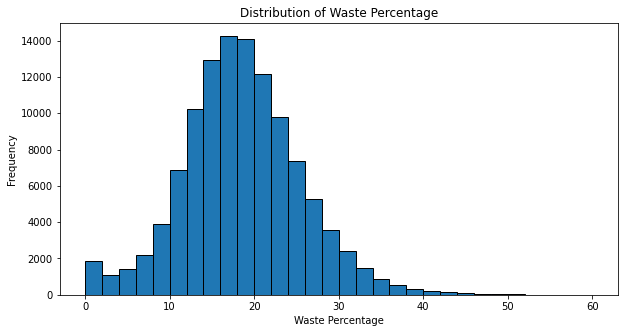

In [387]:
plt.figure(figsize=(10,5))

plt.hist(
    waste_df["waste_percentage"],
    bins=[0,2,4,6,8, 10, 12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,50,52,54,56,58,60],
    edgecolor="black"
)

plt.title("Distribution of Waste Percentage")

plt.xlabel("Waste Percentage")

plt.ylabel("Frequency")

plt.show()

In [388]:
plt.figure(figsize=(10,5))

plt.hist(
    waste_df["waste_percentage"],
    bins=[0,2,4,6,8, 10, 12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,50,52,54,56,58,60],
    edgecolor="black"
)

plt.title("Distribution of Waste Percentage")

plt.xlabel("Waste Percentage")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "Distribution of Waste Percentage.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

In [389]:
Q1 = waste_df["food_wasted_kg"].quantile(0.25)
Q3 = waste_df["food_wasted_kg"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = waste_df[
    (waste_df["food_wasted_kg"] < lower)
    |
    (waste_df["food_wasted_kg"] > upper)
]

print("Number of Outliers:", len(outliers))

print(
    "Percentage:",
    round(
        len(outliers) / len(waste_df) * 100,
        2
    ),
    "%"
)

Number of Outliers: 986
Percentage: 0.87 %


***
#### Meal-wise Analysis

In [390]:
meal_summary = (
    waste_df
    .groupby("meal_type")
    .agg(
        Total_Waste=("food_wasted_kg", "sum"),
        Average_Waste=("food_wasted_kg", "mean"),
        Median_Waste=("food_wasted_kg", "median"),
        Waste_Percentage=("waste_percentage", "mean"),
        Operations=("record_id", "count")
    )
    .round(2)
    .sort_values("Total_Waste", ascending=False)
)

meal_summary

,Total_Waste,Average_Waste,Median_Waste,Waste_Percentage,Operations
meal_type,,,,,
Lunch,440366.46,10.85,8.31,19.04,40598
Dinner,410831.85,10.33,7.97,18.13,39759
Breakfast,159559.44,7.28,7.27,18.49,21912
Snacks,60731.52,5.54,5.24,18.21,10956


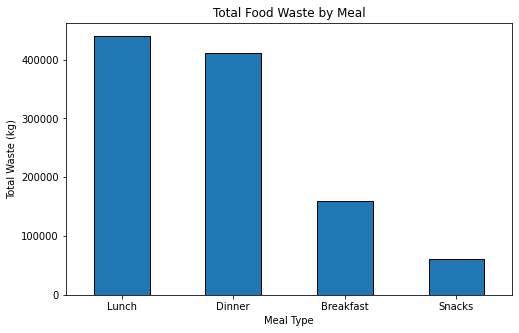

In [391]:
plt.figure(figsize=(8,5))

# plt.bar(
#     meal_summary.index,
#     meal_summary["Total_Waste"],
#     edgecolor="black"
# )

meal_summary["Total_Waste"].plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Total Food Waste by Meal")
plt.xlabel("Meal Type")
plt.ylabel("Total Waste (kg)")

plt.xticks(rotation=0)

plt.show()

In [392]:
plt.figure(figsize=(8,5))

# plt.bar(
#     meal_summary.index,
#     meal_summary["Total_Waste"],
#     edgecolor="black"
# )

meal_summary["Total_Waste"].plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Total Food Waste by Meal")
plt.xlabel("Meal Type")
plt.ylabel("Total Waste (kg)")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "Total Food Waste by Meal.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

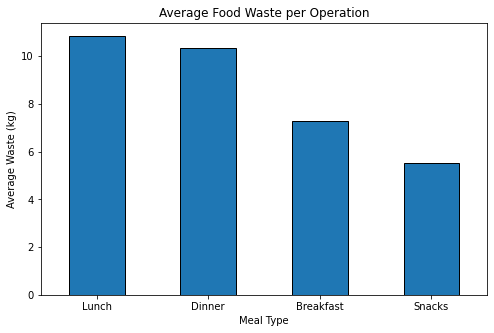

In [393]:
plt.figure(figsize=(8,5))

# plt.bar(
#     meal_summary.index,
#     meal_summary["Average_Waste"],
#     edgecolor="black"
# )

meal_summary["Average_Waste"].plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Food Waste per Operation")
plt.xlabel("Meal Type")
plt.ylabel("Average Waste (kg)")

plt.xticks(rotation=0)

plt.show()

In [394]:
plt.figure(figsize=(8,5))

# plt.bar(
#     meal_summary.index,
#     meal_summary["Average_Waste"],
#     edgecolor="black"
# )

meal_summary["Average_Waste"].plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Food Waste per Operation")
plt.xlabel("Meal Type")
plt.ylabel("Average Waste (kg)")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "Average Food Waste per Operation.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

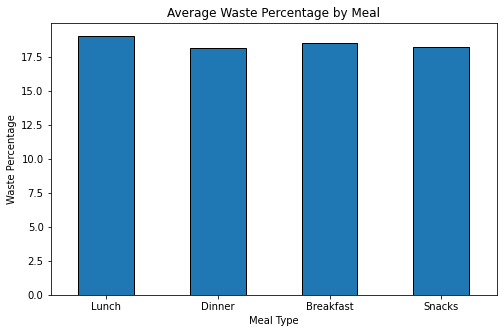

In [395]:
plt.figure(figsize=(8,5))

meal_summary["Waste_Percentage"].plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Waste Percentage by Meal")
plt.xlabel("Meal Type")
plt.ylabel("Waste Percentage")

plt.xticks(rotation=0)

plt.show()

In [396]:
plt.figure(figsize=(8,5))

meal_summary["Waste_Percentage"].plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Waste Percentage by Meal")
plt.xlabel("Meal Type")
plt.ylabel("Waste Percentage")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "Average Waste Percentage by Meal.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

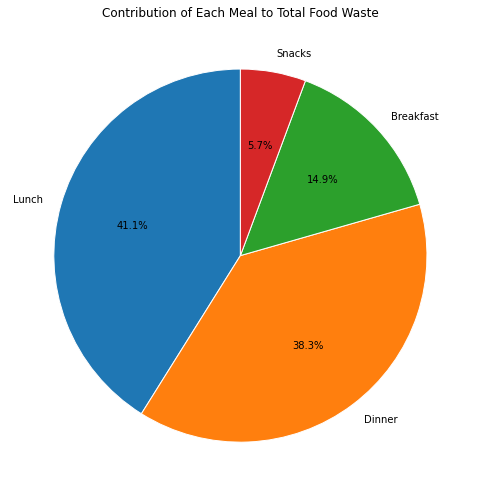

In [397]:
plt.figure(figsize=(7,7))

plt.pie(
    meal_summary["Total_Waste"],
    labels=meal_summary.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor":"white"}
)

plt.title("Contribution of Each Meal to Total Food Waste")

plt.tight_layout()
plt.show()

In [398]:
plt.figure(figsize=(7,7))

plt.pie(
    meal_summary["Total_Waste"],
    labels=meal_summary.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor":"white"}
)

plt.title("Contribution of Each Meal to Total Food Waste")

plt.tight_layout()

plt.savefig(
    "Contribution of Each Meal to Total Food Waste.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Menu Item Analysis

In [399]:
menu_summary = (
    waste_df
    .groupby("menu_item")
    .agg(
        Total_Waste=("food_wasted_kg", "sum"),
        Average_Waste=("food_wasted_kg", "mean"),
        Waste_Percentage=("waste_percentage", "mean"),
        Quality=("quality_score", "mean"),
        Operations=("record_id", "count")
    )
    .round(2)
)

menu_summary = menu_summary.sort_values(
    "Total_Waste",
    ascending=False
)

top20 = menu_summary.head(20)
top20

,Total_Waste,Average_Waste,Waste_Percentage,Quality,Operations
menu_item,,,,,
Dal Tadka,46400.88,16.94,18.04,7.99,2739
Kadhi Pakoda,46041.81,16.63,17.86,7.99,2769
Paneer Curry,45930.81,16.51,17.86,7.99,2782
Khichdi,45744.22,16.77,18.04,7.99,2728
Aloo Gobi,45492.85,16.76,18.01,7.99,2714
Roti-Sabzi,45327.20,16.70,17.92,7.99,2714
Rajma Rice,45208.08,16.77,18.03,7.99,2696
Mixed Veg,45187.91,16.95,18.11,7.99,2666
Chana Masala,44791.33,16.71,17.91,7.99,2681


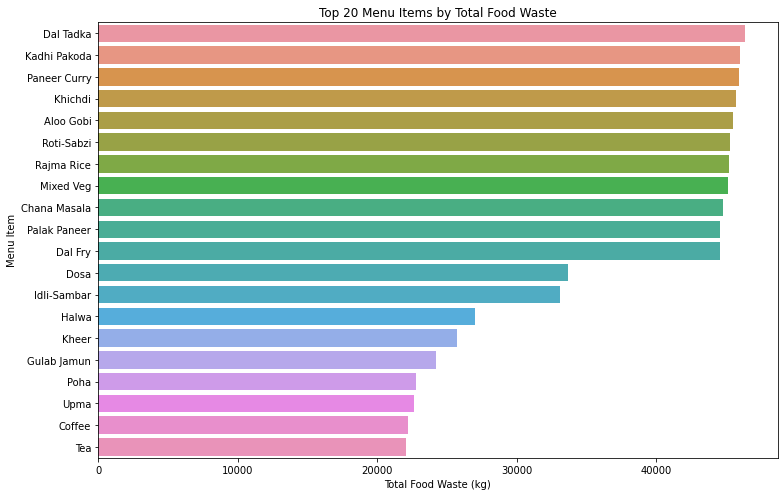

In [400]:
plt.figure(figsize=(11,7))

ax = sns.barplot(
    data=top20.reset_index(),
    y="menu_item",
    x="Total_Waste"
)

plt.title("Top 20 Menu Items by Total Food Waste")

plt.xlabel("Total Food Waste (kg)")
plt.ylabel("Menu Item")

plt.tight_layout()
plt.show()

In [401]:
plt.figure(figsize=(11,7))

ax = sns.barplot(
    data=top20.reset_index(),
    y="menu_item",
    x="Total_Waste"
)

plt.title("Top 20 Menu Items by Total Food Waste")

plt.xlabel("Total Food Waste (kg)")
plt.ylabel("Menu Item")

plt.tight_layout()

plt.savefig(
    "Top 20 Menu Items by Total Food Waste.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

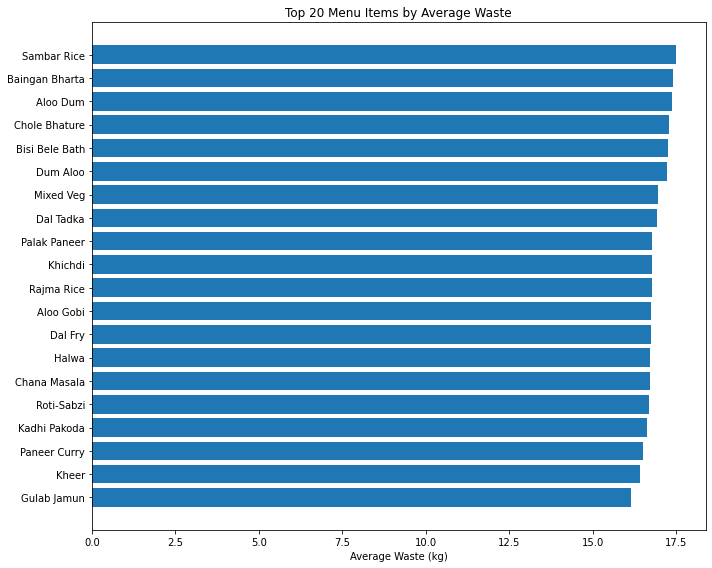

In [402]:
top_avg = (
    menu_summary
    .sort_values(
        "Average_Waste",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(10,8))

plt.barh(
    top_avg.index,
    top_avg["Average_Waste"]
)

plt.title("Top 20 Menu Items by Average Waste")
plt.xlabel("Average Waste (kg)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [403]:
top_avg = (
    menu_summary
    .sort_values(
        "Average_Waste",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(10,8))

plt.barh(
    top_avg.index,
    top_avg["Average_Waste"]
)

plt.title("Top 20 Menu Items by Average Waste")
plt.xlabel("Average Waste (kg)")
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "Top 20 Menu Items by Average Waste.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

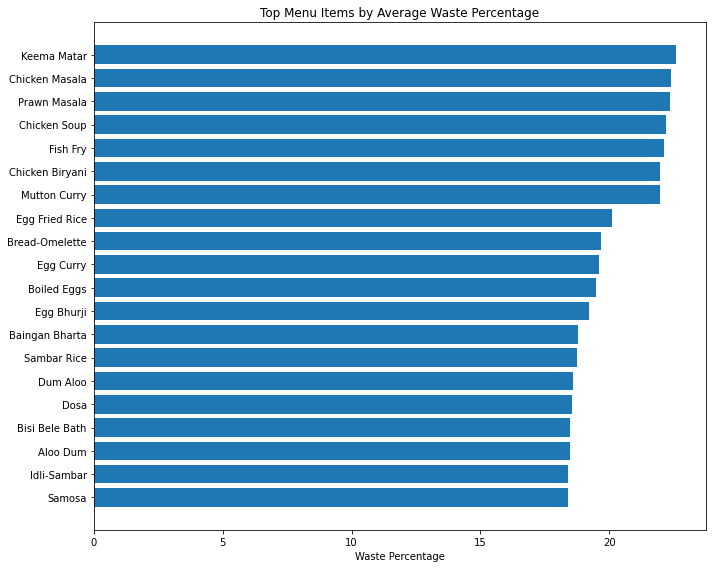

In [404]:
top_percent = (
    menu_summary
    .sort_values(
        "Waste_Percentage",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(10,8))

plt.barh(
    top_percent.index,
    top_percent["Waste_Percentage"]
)

plt.title("Top Menu Items by Average Waste Percentage")
plt.xlabel("Waste Percentage")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [405]:
top_percent = (
    menu_summary
    .sort_values(
        "Waste_Percentage",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(10,8))

plt.barh(
    top_percent.index,
    top_percent["Waste_Percentage"]
)

plt.title("Top Menu Items by Average Waste Percentage")
plt.xlabel("Waste Percentage")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "Top Menu Items by Average Waste Percentage.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

<Figure size 1008x432 with 0 Axes>

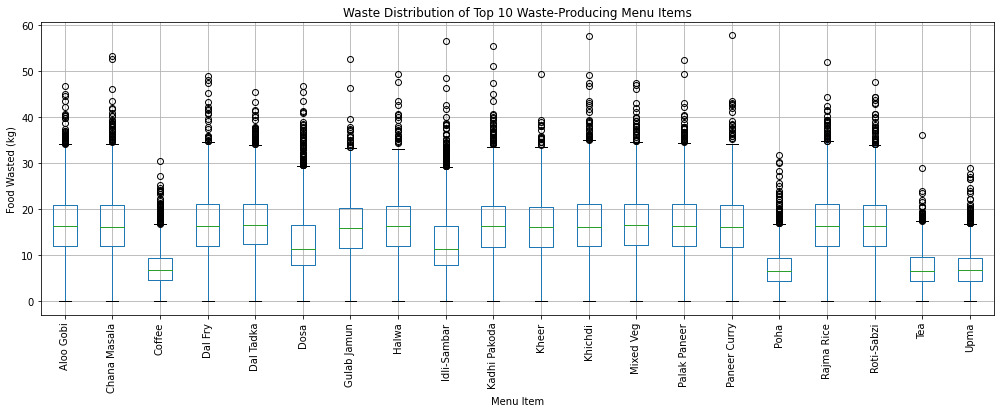

In [406]:
top10_items = top20.index.tolist()

plt.figure(figsize=(14,6))

waste_df[
    waste_df["menu_item"].isin(top10_items)
].boxplot(
    column="food_wasted_kg",
    by="menu_item",
    rot=90,
    figsize=(14,6)
)

plt.title("Waste Distribution of Top 10 Waste-Producing Menu Items")
plt.suptitle("")
plt.xlabel("Menu Item")
plt.ylabel("Food Wasted (kg)")

plt.tight_layout()
plt.show()

In [407]:
top10_items = top20.index.tolist()

plt.figure(figsize=(14,6))

waste_df[
    waste_df["menu_item"].isin(top10_items)
].boxplot(
    column="food_wasted_kg",
    by="menu_item",
    rot=90,
    figsize=(14,6)
)

plt.title("Waste Distribution of Top 10 Waste-Producing Menu Items")
plt.suptitle("")
plt.xlabel("Menu Item")
plt.ylabel("Food Wasted (kg)")

plt.tight_layout()

plt.savefig(
    "Waste Distribution of Top 10 Waste-Producing Menu Items.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

<Figure size 1008x432 with 0 Axes>

In [408]:
pareto = (
    menu_summary["Total_Waste"]
    .sort_values(ascending=False)
    .reset_index()
)

pareto["cum_percent"] = (
    pareto["Total_Waste"].cumsum()
    / pareto["Total_Waste"].sum()
    * 100
)

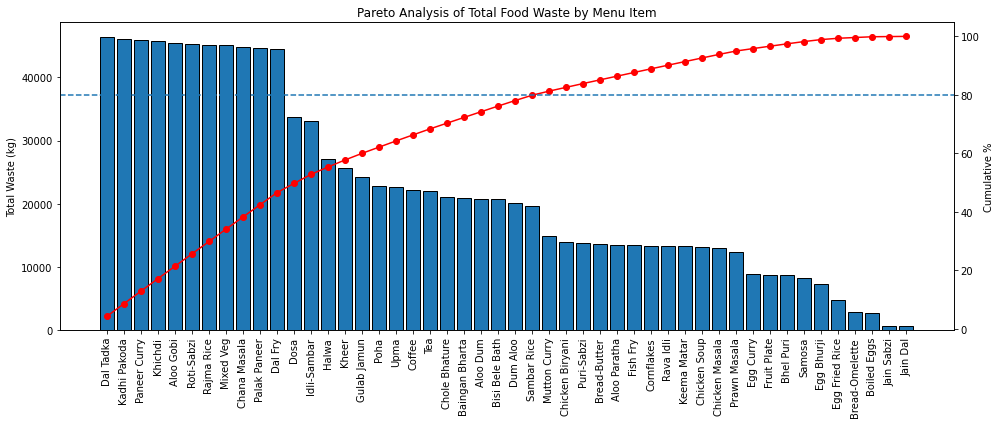

In [409]:
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(
    pareto["menu_item"],
    pareto["Total_Waste"],
    edgecolor="black"
)

ax1.set_ylabel("Total Waste (kg)")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()

ax2.plot(
    pareto["cum_percent"],
    marker="o",
    color="red"
)

ax2.axhline(
    80,
    linestyle="dashed"
)

ax2.set_ylabel("Cumulative %")

plt.title("Pareto Analysis of Total Food Waste by Menu Item")

plt.tight_layout()
plt.show()

In [410]:
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(
    pareto["menu_item"],
    pareto["Total_Waste"],
    edgecolor="black"
)

ax1.set_ylabel("Total Waste (kg)")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()

ax2.plot(
    pareto["cum_percent"],
    marker="o",
    color="red"
)

ax2.axhline(
    80,
    linestyle="dashed"
)

ax2.set_ylabel("Cumulative %")

plt.title("Pareto Analysis of Total Food Waste by Menu Item")

plt.tight_layout()

plt.savefig(
    "Pareto Analysis of Total Food Waste by Menu Item.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

In [411]:
pareto = (
    menu_summary["Average_Waste"]
    .sort_values(ascending=False)
    .reset_index()
)

pareto["cum_percent"] = (
    pareto["Average_Waste"].cumsum()
    / pareto["Average_Waste"].sum()
    * 100
)

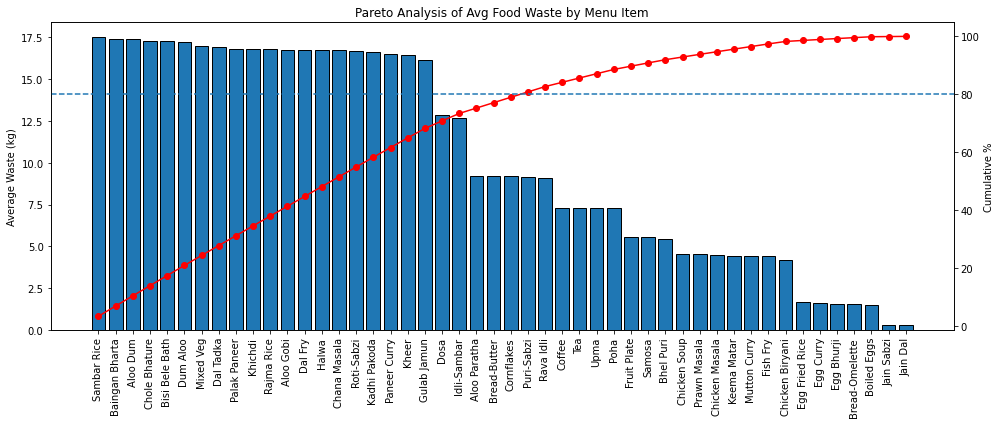

In [412]:
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(
    pareto["menu_item"],
    pareto["Average_Waste"],
    edgecolor="black"
)

ax1.set_ylabel("Average Waste (kg)")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()

ax2.plot(
    pareto["cum_percent"],
    marker="o",
    color="red"
)

ax2.axhline(
    80,
    linestyle="dashed"
)

ax2.set_ylabel("Cumulative %")

plt.title("Pareto Analysis of Avg Food Waste by Menu Item")

plt.tight_layout()
plt.show()

In [413]:
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(
    pareto["menu_item"],
    pareto["Average_Waste"],
    edgecolor="black"
)

ax1.set_ylabel("Average Waste (kg)")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()

ax2.plot(
    pareto["cum_percent"],
    marker="o",
    color="red"
)

ax2.axhline(
    80,
    linestyle="dashed"
)

ax2.set_ylabel("Cumulative %")

plt.title("Pareto Analysis of Avg Food Waste by Menu Item")

plt.tight_layout()

plt.savefig(
    "Pareto Analysis of Avg Food Waste by Menu Item.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Cuisine Analysis

In [414]:
cuisine_summary = (
    waste_df
    .groupby("cuisine_category")
    .agg(
        Average_Waste=("food_wasted_kg", "mean"),
        Median_Waste=("food_wasted_kg", "median"),
        Average_Waste_Percentage=("waste_percentage", "mean"),
        Operations=("record_id", "count")
    )
    .round(2)
    .sort_values("Average_Waste", ascending=False)
)

cuisine_summary

,Average_Waste,Median_Waste,Average_Waste_Percentage,Operations
cuisine_category,,,,
Sweet-Dessert,16.45,16.21,17.68,4679
North Indian,10.40,8.41,18.11,67757
South Indian,9.44,7.36,19.58,17912
Street Food,5.51,5.20,18.28,3082
Continental,5.23,4.27,19.27,19795


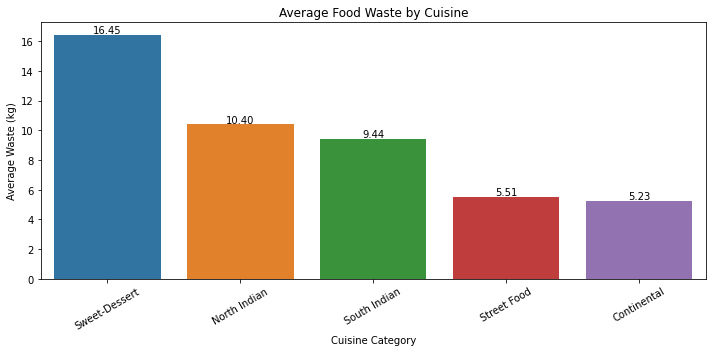

In [415]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=cuisine_summary.reset_index(),
    x="cuisine_category",
    y="Average_Waste"
)

for i, value in enumerate(cuisine_summary["Average_Waste"]):
    ax.text(
        i,
        value + 0.1,
        f"{value:.2f}",
        ha="center",
        fontsize=10
    )

plt.title("Average Food Waste by Cuisine")
plt.xlabel("Cuisine Category")
plt.ylabel("Average Waste (kg)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [416]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=cuisine_summary.reset_index(),
    x="cuisine_category",
    y="Average_Waste"
)

for i, value in enumerate(cuisine_summary["Average_Waste"]):
    ax.text(
        i,
        value + 0.1,
        f"{value:.2f}",
        ha="center",
        fontsize=10
    )

plt.title("Average Food Waste by Cuisine")
plt.xlabel("Cuisine Category")
plt.ylabel("Average Waste (kg)")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "Average Food Waste by Cuisine.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

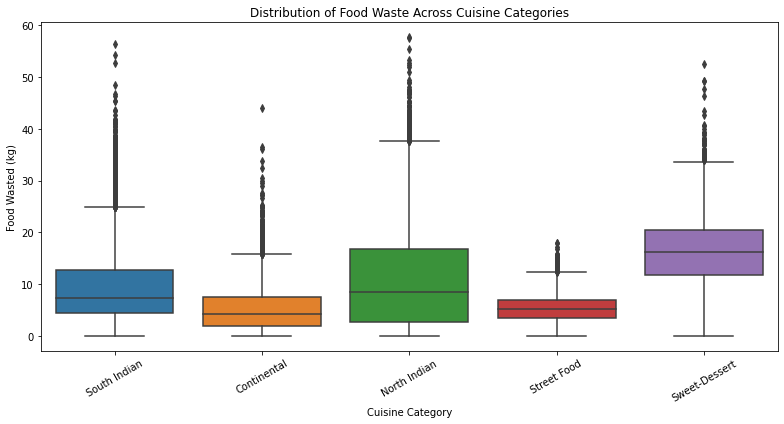

In [417]:
plt.figure(figsize=(11,6))

sns.boxplot(
    data=waste_df,
    x="cuisine_category",
    y="food_wasted_kg"
)

plt.title("Distribution of Food Waste Across Cuisine Categories")
plt.xlabel("Cuisine Category")
plt.ylabel("Food Wasted (kg)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [418]:
plt.figure(figsize=(11,6))

sns.boxplot(
    data=waste_df,
    x="cuisine_category",
    y="food_wasted_kg"
)

plt.title("Distribution of Food Waste Across Cuisine Categories")
plt.xlabel("Cuisine Category")
plt.ylabel("Food Wasted (kg)")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "Distribution of Food Waste Across Cuisine Categories.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Mess Hall Analysis

In [419]:
hall_summary = (
    waste_df
    .groupby("mess_hall_id")
    .agg(
        Total_Waste=("food_wasted_kg", "sum"),
        Average_Waste=("food_wasted_kg", "mean"),
        Waste_Percentage=("waste_percentage", "mean"),
        Average_Quality=("quality_score", "mean"),
        Operations=("record_id", "count")
    )
    .round(2)
    .sort_values("Average_Waste", ascending=False)
)

hall_summary

,Total_Waste,Average_Waste,Waste_Percentage,Average_Quality,Operations
mess_hall_id,,,,,
MH_A,385475.55,10.22,19.72,7.99,37715
MH_B,384213.61,10.18,19.71,7.99,37732
MH_G,301800.11,7.99,16.17,7.99,37778


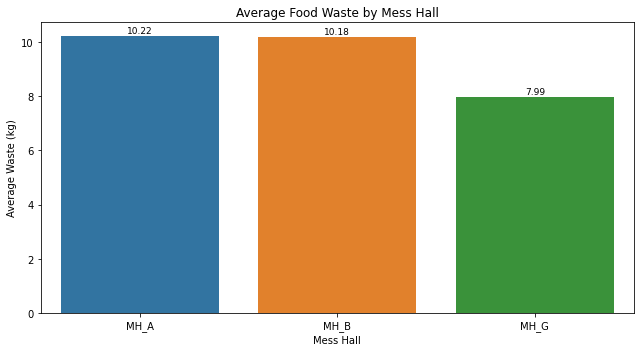

In [420]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=hall_summary.reset_index(),
    x="mess_hall_id",
    y="Average_Waste"
)

for i, value in enumerate(hall_summary["Average_Waste"]):
    ax.text(
        i,
        value + 0.1,
        f"{value:.2f}",
        ha="center",
        fontsize=9
    )

plt.title("Average Food Waste by Mess Hall")
plt.xlabel("Mess Hall")
plt.ylabel("Average Waste (kg)")

plt.tight_layout()
plt.show()

In [421]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=hall_summary.reset_index(),
    x="mess_hall_id",
    y="Average_Waste"
)

for i, value in enumerate(hall_summary["Average_Waste"]):
    ax.text(
        i,
        value + 0.1,
        f"{value:.2f}",
        ha="center",
        fontsize=9
    )

plt.title("Average Food Waste by Mess Hall")
plt.xlabel("Mess Hall")
plt.ylabel("Average Waste (kg)")

plt.tight_layout()

plt.savefig(
    "Average Food Waste by Mess Hall.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

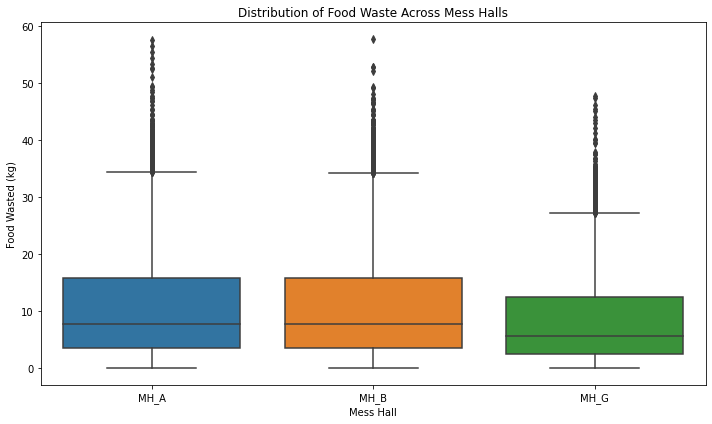

In [422]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=waste_df,
    x="mess_hall_id",
    y="food_wasted_kg"
)

plt.title("Distribution of Food Waste Across Mess Halls")
plt.xlabel("Mess Hall")
plt.ylabel("Food Wasted (kg)")

plt.tight_layout()
plt.show()

In [423]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=waste_df,
    x="mess_hall_id",
    y="food_wasted_kg"
)

plt.title("Distribution of Food Waste Across Mess Halls")
plt.xlabel("Mess Hall")
plt.ylabel("Food Wasted (kg)")

plt.tight_layout()

plt.savefig(
    "Distribution of Food Waste Across Mess Halls.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

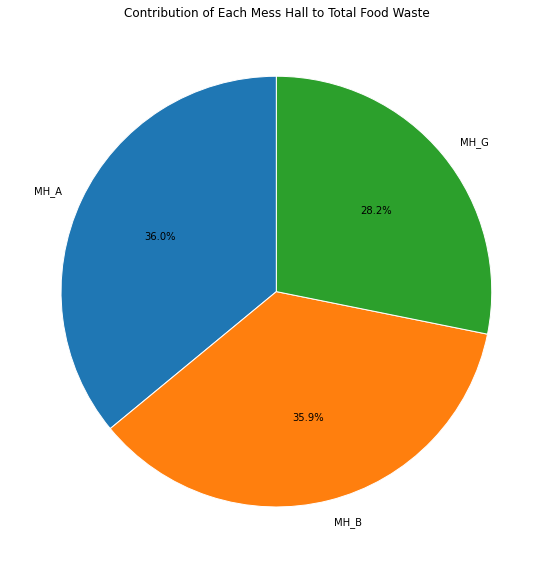

In [424]:
plt.figure(figsize=(8,8))

plt.pie(
    hall_summary["Total_Waste"],
    labels=hall_summary.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor":"white"}
)

plt.title("Contribution of Each Mess Hall to Total Food Waste")

plt.tight_layout()
plt.show()

In [425]:
plt.figure(figsize=(8,8))

plt.pie(
    hall_summary["Total_Waste"],
    labels=hall_summary.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor":"white"}
)

plt.title("Contribution of Each Mess Hall to Total Food Waste")

plt.tight_layout()

plt.savefig(
    "Contribution of Each Mess Hall to Total Food Waste.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Time Trend Analysis

In [426]:
monthly_waste = (
    waste_df
    .groupby("month_name")
    .agg(
        Total_Waste=("food_wasted_kg", "sum"),
        Average_Waste=("food_wasted_kg", "mean")
    )
)

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_waste = (
    monthly_waste
    .reindex(month_order)
)

monthly_waste

,Total_Waste,Average_Waste
month_name,,
January,79996.499089,8.326030
February,71367.622475,8.168436
March,77448.205165,8.070884
April,79583.990839,8.558339
May,73842.158459,7.684687
June,92690.425783,9.958146
July,99259.526395,10.341689
August,86865.183068,9.034340
September,77943.557047,8.363940


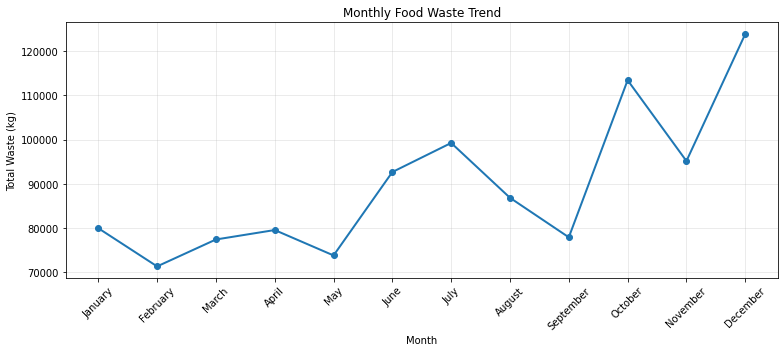

In [427]:
plt.figure(figsize=(11,5))

plt.plot(
    monthly_waste.index,
    monthly_waste["Total_Waste"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Food Waste Trend")

plt.xlabel("Month")

plt.ylabel("Total Waste (kg)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [428]:
plt.figure(figsize=(11,5))

plt.plot(
    monthly_waste.index,
    monthly_waste["Total_Waste"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Food Waste Trend")

plt.xlabel("Month")

plt.ylabel("Total Waste (kg)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Monthly Food Waste Trend.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

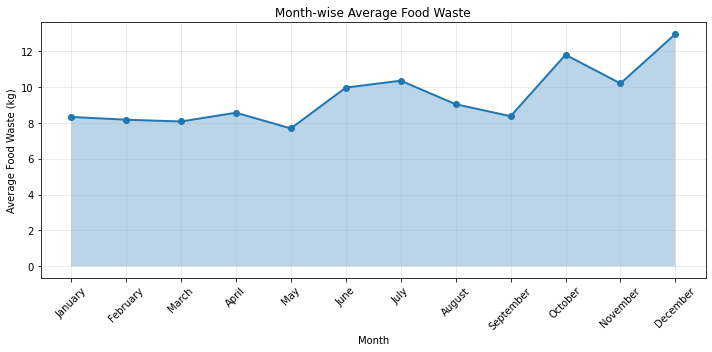

In [429]:
monthly_waste = (
    waste_df.groupby("month_name")["food_wasted_kg"]
    .mean()
    .reindex([
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December"
    ])
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_waste.index,
    monthly_waste.values,
    marker="o",
    linewidth=2
)

plt.fill_between(
    monthly_waste.index,
    monthly_waste.values,
    alpha=0.3
)

plt.title("Month-wise Average Food Waste")

plt.xlabel("Month")

plt.ylabel("Average Food Waste (kg)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [430]:
monthly_waste = (
    waste_df.groupby("month_name")["food_wasted_kg"]
    .mean()
    .reindex([
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December"
    ])
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_waste.index,
    monthly_waste.values,
    marker="o",
    linewidth=2
)

plt.fill_between(
    monthly_waste.index,
    monthly_waste.values,
    alpha=0.3
)

plt.title("Month-wise Average Food Waste")

plt.xlabel("Month")

plt.ylabel("Average Food Waste (kg)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Month-wise Average Food Waste.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

In [431]:
day_summary = (
    waste_df
    .groupby("day_of_week")
    .agg(
        Average_Waste=("food_wasted_kg","mean")
    )
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_summary = day_summary.reindex(day_order)

day_summary

,Average_Waste
day_of_week,
Monday,9.859994
Tuesday,9.254889
Wednesday,9.121415
Thursday,9.491892
Friday,8.920485
Saturday,9.342904
Sunday,10.272192


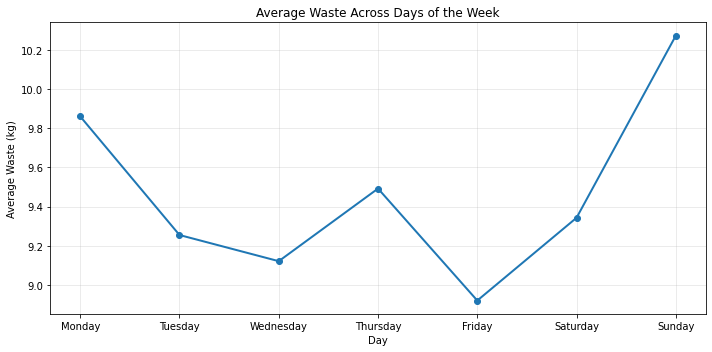

In [432]:
plt.figure(figsize=(10,5))

plt.plot(
    day_summary.index,
    day_summary["Average_Waste"],
    marker="o",
    linewidth=2
)

plt.title("Average Waste Across Days of the Week")

plt.xlabel("Day")

plt.ylabel("Average Waste (kg)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [433]:
plt.figure(figsize=(10,5))

plt.plot(
    day_summary.index,
    day_summary["Average_Waste"],
    marker="o",
    linewidth=2
)

plt.title("Average Waste Across Days of the Week")

plt.xlabel("Day")

plt.ylabel("Average Waste (kg)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Average Waste Across Days of the Week.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Relationship Analysis

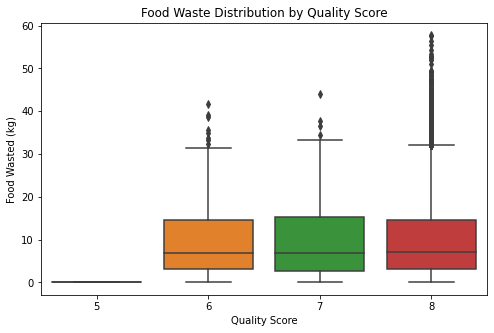

In [434]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=waste_df,
    x="quality_score",
    y="food_wasted_kg"
)

plt.title("Food Waste Distribution by Quality Score")
plt.xlabel("Quality Score")
plt.ylabel("Food Wasted (kg)")

plt.show()

In [435]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=waste_df,
    x="quality_score",
    y="food_wasted_kg"
)

plt.title("Food Waste Distribution by Quality Score")
plt.xlabel("Quality Score")
plt.ylabel("Food Wasted (kg)")

plt.tight_layout()

plt.savefig(
    "Food Waste Distribution by Quality Score.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

In [436]:
print(
    waste_df[
        ["quality_score","food_wasted_kg"]
    ].corr()
)

                quality_score  food_wasted_kg
quality_score        1.000000       -0.000384
food_wasted_kg      -0.000384        1.000000


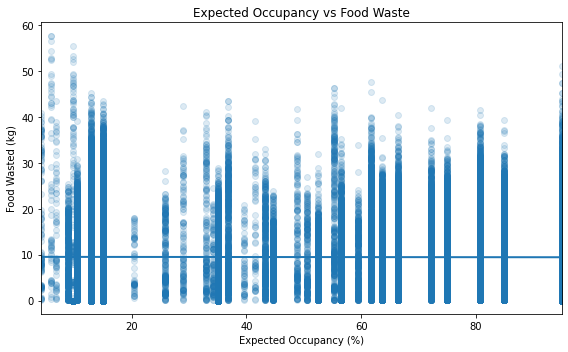

In [437]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=waste_df,
    x="expected_occupancy_percent",
    y="food_wasted_kg",
    scatter_kws={"alpha":0.15},
    line_kws={"linewidth":2}
)

plt.title("Expected Occupancy vs Food Waste")

plt.xlabel("Expected Occupancy (%)")
plt.ylabel("Food Wasted (kg)")

plt.tight_layout()
plt.show()

In [438]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=waste_df,
    x="expected_occupancy_percent",
    y="food_wasted_kg",
    scatter_kws={"alpha":0.15},
    line_kws={"linewidth":2}
)

plt.title("Expected Occupancy vs Food Waste")

plt.xlabel("Expected Occupancy (%)")
plt.ylabel("Food Wasted (kg)")

plt.tight_layout()

plt.savefig(
    "Expected Occupancy vs Food Waste.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

In [439]:
print(
    waste_df[
        [
            "expected_occupancy_percent",
            "food_wasted_kg"
        ]
    ].corr()
)

                            expected_occupancy_percent  food_wasted_kg
expected_occupancy_percent                    1.000000       -0.003436
food_wasted_kg                               -0.003436        1.000000


In [440]:
corr_cols = [
    "food_prepared_kg",
    "food_consumed_kg",
    "food_wasted_kg",
    "waste_percentage",
    "quality_score",
    "temperature_c",
    "rainfall_mm",
    "humidity_percent",
    "air_quality_index",
    "expected_occupancy_percent"
]

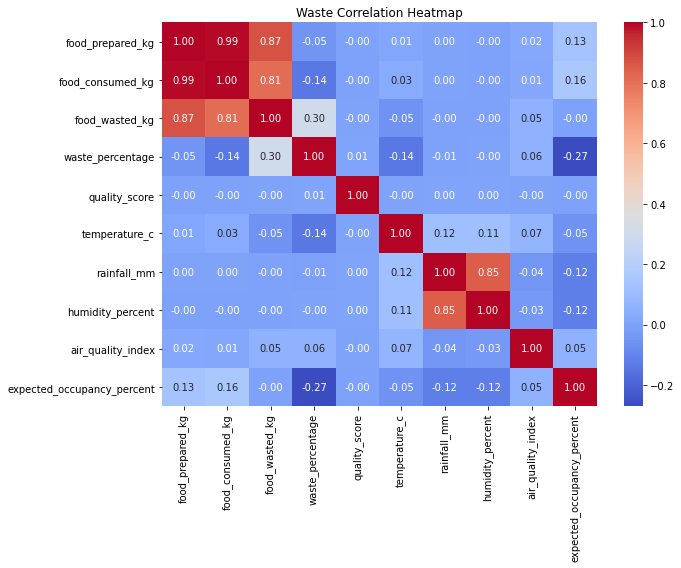

In [441]:
plt.figure(figsize=(10,8))

sns.heatmap(
    waste_df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Waste Correlation Heatmap")

plt.tight_layout()

plt.show()

In [442]:
plt.figure(figsize=(10,8))

sns.heatmap(
    waste_df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Waste Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "Waste Correlation Heatmap.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Multivariate Analysis

In [443]:
sample_df = waste_df.sample(
    5000,
    random_state=42
)

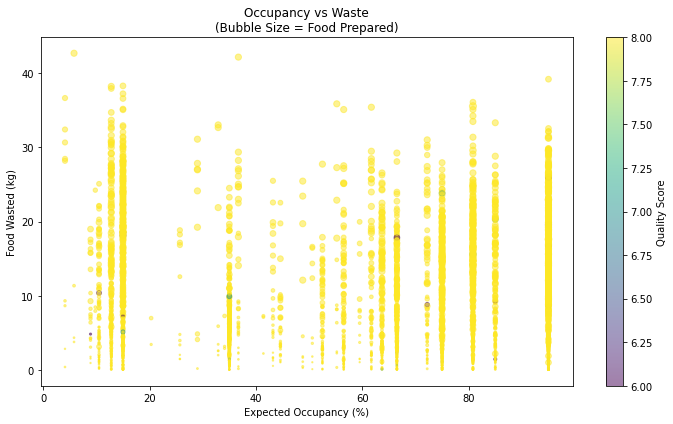

In [444]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    sample_df["expected_occupancy_percent"],
    sample_df["food_wasted_kg"],
    s=sample_df["food_prepared_kg"] / 3,
    c=sample_df["quality_score"],
    alpha=0.5
)

plt.colorbar(
    scatter,
    label="Quality Score"
)

plt.title(
    "Occupancy vs Waste\n(Bubble Size = Food Prepared)"
)

plt.xlabel("Expected Occupancy (%)")

plt.ylabel("Food Wasted (kg)")

plt.tight_layout()

plt.show()

In [445]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    sample_df["expected_occupancy_percent"],
    sample_df["food_wasted_kg"],
    s=sample_df["food_prepared_kg"] / 3,
    c=sample_df["quality_score"],
    alpha=0.5
)

plt.colorbar(
    scatter,
    label="Quality Score"
)

plt.title(
    "Occupancy vs Waste\n(Bubble Size = Food Prepared)"
)

plt.xlabel("Expected Occupancy (%)")

plt.ylabel("Food Wasted (kg)")

plt.tight_layout()

plt.savefig(
    "Occupancy vs Waste.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

In [446]:
multivariate_summary = (
    waste_df
    .groupby(
        [
            "meal_type",
            "quality_score"
        ]
    )
    .agg(
        Avg_Waste=("food_wasted_kg","mean"),
        Avg_Waste_Pct=("waste_percentage","mean"),
        Avg_Prepared=("food_prepared_kg","mean")
    )
    .round(2)
)

multivariate_summary

Avg_Waste  Avg_Waste_Pct  Avg_Prepared
meal_type quality_score                                        
Breakfast 6                   6.79          18.40         39.20
          7                   7.62          17.65         46.74
          8                   7.28          18.50         39.96
Dinner    6                   9.81          17.15         57.92
          7                  10.74          18.75         56.26
          8                  10.33          18.14         57.57
Lunch     5                   0.00           0.00         27.94
          6                  11.69          18.77         60.54
          7                  10.75          17.62         60.49
          8                  10.84          19.04         57.51
Snacks    6                   5.69          17.80         32.51
          7                   5.84          18.48         31.48
          8                   5.54          18.21         30.58

***
### for attendance_df

#### Attendance Distribution

In [447]:
attendance_df["attendance_percentage"].describe()

count    21912.000000
mean        43.946711
std         22.840592
min          4.890000
25%         25.330000
50%         41.330000
75%         61.330000
max        100.000000
Name: attendance_percentage, dtype: float64

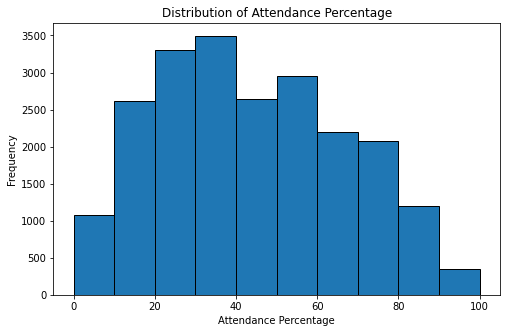

In [448]:
plt.figure(figsize=(8,5))

plt.hist(
    attendance_df["attendance_percentage"],
    bins=[0,10,20,30,40,50,60,70,80,90,100],
    edgecolor="black"
)

plt.title("Distribution of Attendance Percentage")
plt.xlabel("Attendance Percentage")
plt.ylabel("Frequency")

plt.show()

In [449]:
plt.figure(figsize=(8,5))

plt.hist(
    attendance_df["attendance_percentage"],
    bins=[0,10,20,30,40,50,60,70,80,90,100],
    edgecolor="black"
)

plt.title("Distribution of Attendance Percentage")
plt.xlabel("Attendance Percentage")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "Distribution of Attendance Percentage.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

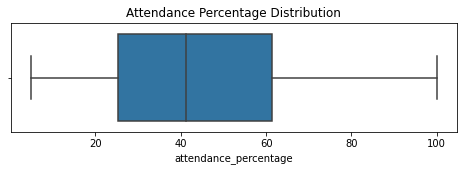

In [450]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=attendance_df["attendance_percentage"]
)

plt.title("Attendance Percentage Distribution")

plt.show()

***
#### Meal-wise Attendance

In [451]:
meal_attendance = (
    attendance_df
    .groupby("meal_type")
    .agg(
        Avg_Attendance=("attendance_percentage","mean"),
        Avg_Present=("present_for_meal","mean")
    )
    .round(2)
    .sort_values(
        "Avg_Attendance",
        ascending=False
    )
)

meal_attendance

,Avg_Attendance,Avg_Present
meal_type,,
Lunch,59.17,235.24
Dinner,51.89,206.25
Breakfast,38.49,153.01
Snacks,26.24,104.24


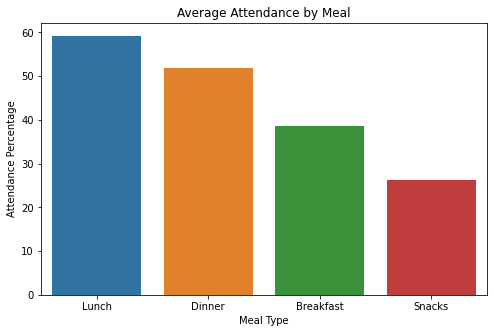

In [452]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=meal_attendance.reset_index(),
    x="meal_type",
    y="Avg_Attendance"
)

plt.title("Average Attendance by Meal")

plt.xlabel("Meal Type")
plt.ylabel("Attendance Percentage")

plt.show()

In [453]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=meal_attendance.reset_index(),
    x="meal_type",
    y="Avg_Attendance"
)

plt.title("Average Attendance by Meal")

plt.xlabel("Meal Type")
plt.ylabel("Attendance Percentage")

plt.tight_layout()

plt.savefig(
    "Average Attendance by Meal.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Attendance Trend Over Time

In [454]:
monthly_attendance = (
    attendance_df
    .groupby("date")
    ["attendance_percentage"]
    .mean()
    .resample("M")
    .mean()
)

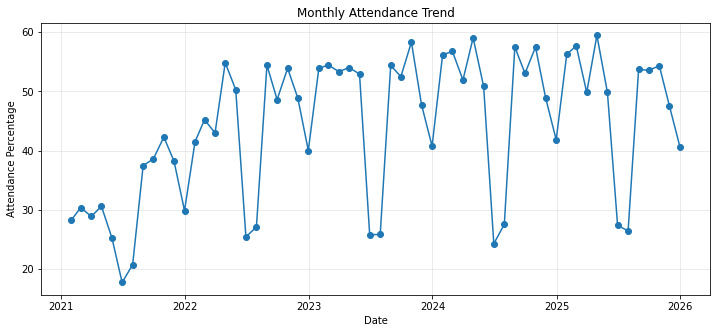

In [455]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_attendance.index,
    monthly_attendance.values,
    marker = 'o'
)

plt.title("Monthly Attendance Trend")

plt.xlabel("Date")

plt.ylabel("Attendance Percentage")

plt.grid(alpha=0.3)

plt.show()

In [456]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_attendance.index,
    monthly_attendance.values,
    marker = 'o'
)

plt.title("Monthly Attendance Trend")

plt.xlabel("Date")

plt.ylabel("Attendance Percentage")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Monthly Attendance Trend.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Exam Impact

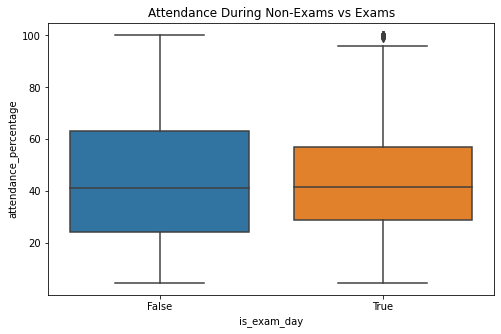

In [457]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=attendance_df,
    x="is_exam_day",
    y="attendance_percentage"
)

plt.title("Attendance During Non-Exams vs Exams")

plt.show()

In [458]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=attendance_df,
    x="is_exam_day",
    y="attendance_percentage"
)

plt.title("Attendance During Non-Exams vs Exams")

plt.tight_layout()

plt.savefig(
    "Attendance During Non-Exams vs Exams.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Festival Impact

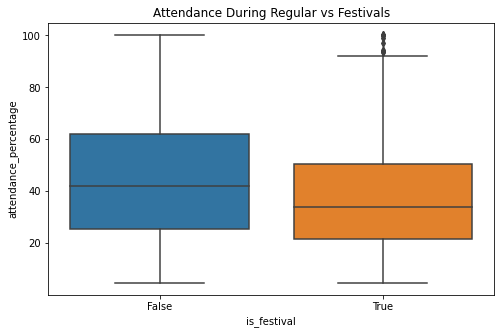

In [459]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=attendance_df,
    x="is_festival",
    y="attendance_percentage"
)

plt.title("Attendance During Regular vs Festivals")

plt.show()

In [460]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=attendance_df,
    x="is_festival",
    y="attendance_percentage"
)

plt.title("Attendance During Regular vs Festivals")

plt.tight_layout()

plt.savefig(
    "Attendance During Regular vs Festivals.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Weather Impact on Attendance

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\regression.py:397: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, **kws)


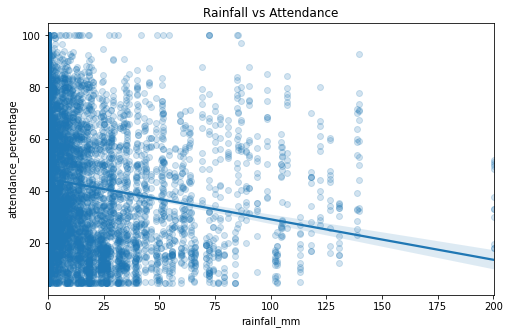

In [461]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=attendance_df,
    x="rainfall_mm",
    y="attendance_percentage",
    scatter_kws={"alpha":0.2, "cmap": "viridis"},
)

plt.title("Rainfall vs Attendance")

plt.show()

In [462]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=attendance_df,
    x="rainfall_mm",
    y="attendance_percentage",
    scatter_kws={"alpha":0.2, "cmap": "viridis"},
)

plt.title("Rainfall vs Attendance")

plt.tight_layout()

plt.savefig(
    "Rainfall vs Attendance.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

In [463]:
attendance_df[
    ["rainfall_mm", "attendance_percentage"]
].corr()

,rainfall_mm,attendance_percentage
rainfall_mm,1.000000,-0.113378
attendance_percentage,-0.113378,1.000000


***
#### Counter Preference Analysis

In [464]:
counter_pref = attendance_df[
    [
        "veg_counter_count",
        "non_veg_counter_count",
        "egg_counter_count"
    ]
].sum()

In [465]:
from matplotlib.ticker import FuncFormatter

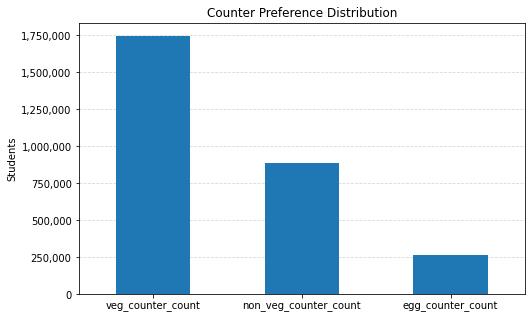

In [466]:
counter_pref.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Counter Preference Distribution")
plt.ylabel("Students")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x):,}")
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.gca().set_axisbelow(True)
plt.xticks(rotation = 'horizontal')

plt.show()

In [467]:
counter_pref.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Counter Preference Distribution")
plt.ylabel("Students")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x):,}")
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.gca().set_axisbelow(True)
plt.xticks(rotation = 'horizontal')

plt.tight_layout()

plt.savefig(
    "Counter Preference Distribution.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

In [468]:
hall_attendance = (
    attendance_df
    .groupby("mess_hall_id")
    .agg(
        Avg_Attendance=("attendance_percentage", "mean"),
        Avg_Present=("present_for_meal", "mean"),
        Operations=("attendance_id", "count")
    )
    .round(2)
    .sort_values(
        "Avg_Attendance",
        ascending=False
    )
)

hall_attendance

,Avg_Attendance,Avg_Present,Operations
mess_hall_id,,,
MH_G,46.15,138.44,7304
MH_B,42.86,192.85,7304
MH_A,42.84,192.76,7304


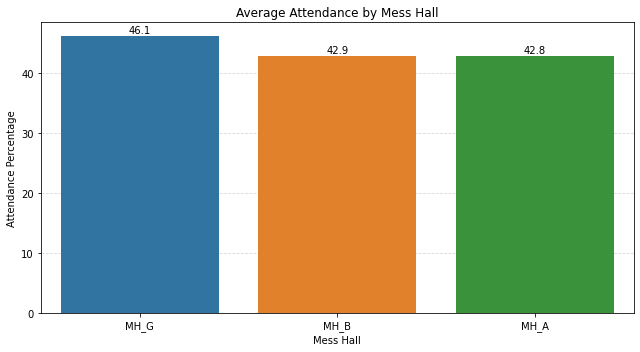

In [469]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=hall_attendance.reset_index(),
    x="mess_hall_id",
    y="Avg_Attendance"
)

for i, value in enumerate(hall_attendance["Avg_Attendance"]):
    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}",
        ha="center"
    )

plt.title("Average Attendance by Mess Hall")
plt.xlabel("Mess Hall")
plt.ylabel("Attendance Percentage")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.gca().set_axisbelow(True)

plt.tight_layout()

plt.show()

In [470]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=hall_attendance.reset_index(),
    x="mess_hall_id",
    y="Avg_Attendance"
)

for i, value in enumerate(hall_attendance["Avg_Attendance"]):
    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}",
        ha="center"
    )

plt.title("Average Attendance by Mess Hall")
plt.xlabel("Mess Hall")
plt.ylabel("Attendance Percentage")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.gca().set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "Average Attendance by Mess Hall.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

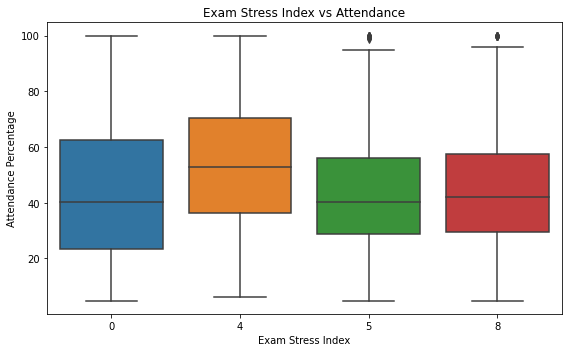

In [471]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=attendance_df,
    x="exam_stress_index",
    y="attendance_percentage"
)

plt.title(
    "Exam Stress Index vs Attendance"
)

plt.xlabel("Exam Stress Index")

plt.ylabel("Attendance Percentage")

plt.tight_layout()

plt.show()

In [472]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=attendance_df,
    x="exam_stress_index",
    y="attendance_percentage"
)

plt.title(
    "Exam Stress Index vs Attendance"
)

plt.xlabel("Exam Stress Index")

plt.ylabel("Attendance Percentage")

plt.tight_layout()

plt.savefig(
    "Exam Stress Index vs Attendance.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
### for feedback_df

#### Overall Rating Distribution

In [473]:
feedback_df["overall_rating"].describe()

count    47281.000000
mean         3.399103
std          1.237364
min          1.000000
25%          2.000000
50%          4.000000
75%          4.000000
max          5.000000
Name: overall_rating, dtype: float64

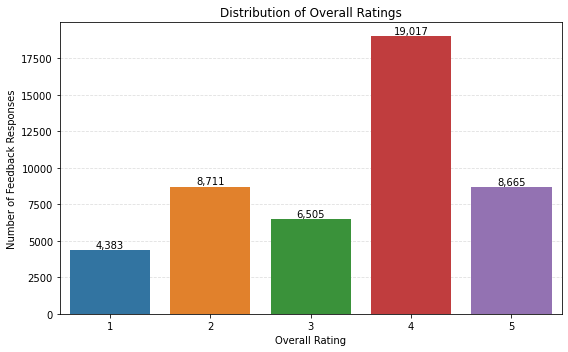

In [474]:
rating_dist = (
    feedback_df["overall_rating"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=rating_dist.index,
    y=rating_dist.values
)

for i, value in enumerate(rating_dist.values):
    ax.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.title("Distribution of Overall Ratings")
plt.xlabel("Overall Rating")
plt.ylabel("Number of Feedback Responses")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

In [475]:
rating_dist = (
    feedback_df["overall_rating"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=rating_dist.index,
    y=rating_dist.values
)

for i, value in enumerate(rating_dist.values):
    ax.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.title("Distribution of Overall Ratings")
plt.xlabel("Overall Rating")
plt.ylabel("Number of Feedback Responses")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "Distribution of Overall Ratings.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Rating Component Analysis

In [476]:
rating_summary = (
    feedback_df[
        [
            "taste_rating",
            "freshness_rating",
            "hygiene_rating",
            "smell_rating"
        ]
    ]
    .mean()
    .sort_values(ascending=False)
)

rating_summary

hygiene_rating      3.517184
taste_rating        2.989065
freshness_rating    2.974979
smell_rating        2.848507
dtype: float64

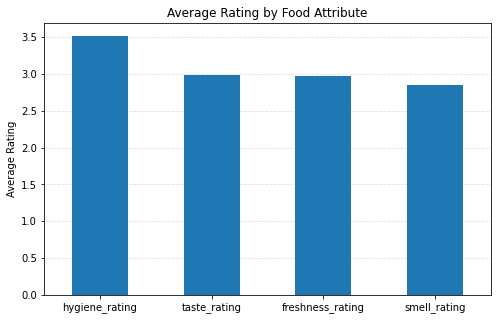

In [477]:
plt.figure(figsize=(8,5))

rating_summary.plot(
    kind="bar"
)

plt.title("Average Rating by Food Attribute")
plt.ylabel("Average Rating")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)
plt.xticks(rotation='horizontal')

plt.show()

In [478]:
plt.figure(figsize=(8,5))

rating_summary.plot(
    kind="bar"
)

plt.title("Average Rating by Food Attribute")
plt.ylabel("Average Rating")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)
plt.xticks(rotation='horizontal')

plt.tight_layout()

plt.savefig(
    "Average Rating by Food Attribute.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Meal-wise Satisfaction

In [479]:
meal_rating = (
    feedback_df
    .groupby("meal_type")
    ["overall_rating"]
    .mean()
    .sort_values(ascending=False)
)

meal_rating

meal_type
Lunch        3.414702
Snacks       3.403644
Breakfast    3.389233
Dinner       3.388738
Name: overall_rating, dtype: float64

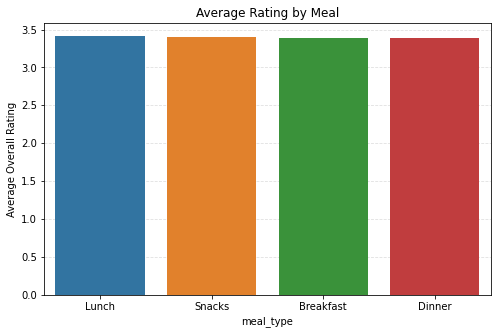

In [480]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=meal_rating.index,
    y=meal_rating.values
)

plt.title("Average Rating by Meal")

plt.ylabel("Average Overall Rating")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.show()

In [481]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=meal_rating.index,
    y=meal_rating.values
)

plt.title("Average Rating by Meal")

plt.ylabel("Average Overall Rating")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "Average Rating by Meal.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Best and Worst Menu Items

In [482]:
menu_rating = (
    feedback_df
    .groupby("menu_item")
    .agg(
        Avg_Rating=("overall_rating","mean"),
        Reviews=("feedback_id","count")
    )
)

menu_rating = menu_rating[
    menu_rating["Reviews"] >= 100
]

In [483]:
top10 = (
    menu_rating
    .sort_values(
        "Avg_Rating",
        ascending=False
    )
    .head(10)
)

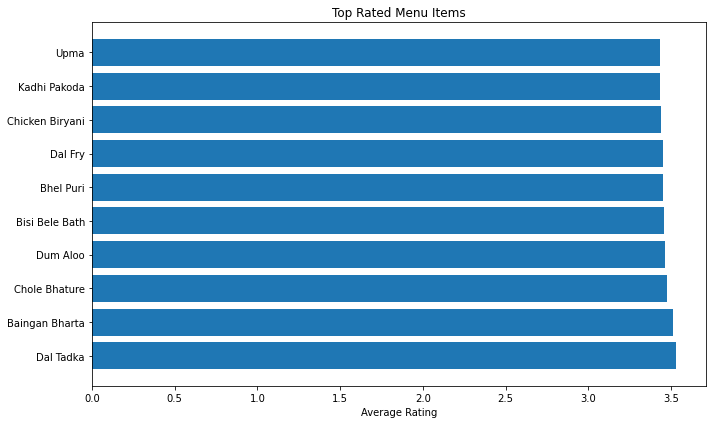

In [484]:
plt.figure(figsize=(10,6))

plt.barh(
    top10.index,
    top10["Avg_Rating"]
)

plt.title("Top Rated Menu Items")

plt.xlabel("Average Rating")

plt.tight_layout()

plt.show()

In [485]:
plt.figure(figsize=(10,6))

plt.barh(
    top10.index,
    top10["Avg_Rating"]
)

plt.title("Top Rated Menu Items")

plt.xlabel("Average Rating")

plt.tight_layout()

plt.savefig(
    "Top Rated Menu Items.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

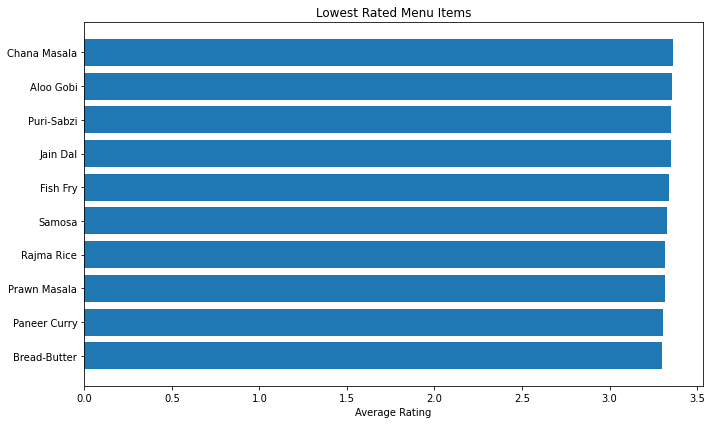

In [486]:
bottom10 = (
    menu_rating
    .sort_values(
        "Avg_Rating"
    )
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    bottom10.index,
    bottom10["Avg_Rating"]
)

plt.title("Lowest Rated Menu Items")

plt.xlabel("Average Rating")

plt.tight_layout()

plt.show()

In [487]:
bottom10 = (
    menu_rating
    .sort_values(
        "Avg_Rating"
    )
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    bottom10.index,
    bottom10["Avg_Rating"]
)

plt.title("Lowest Rated Menu Items")

plt.xlabel("Average Rating")

plt.tight_layout()

plt.savefig(
    "Lowest Rated Menu Items.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Cuisine Satisfaction

In [488]:
cuisine_rating = (
    feedback_df
    .groupby("preferred_cuisine")
    .agg(
        Avg_Rating=("overall_rating", "mean"),
        Reviews=("feedback_id", "count")
    )
    .round(2)
    .sort_values("Avg_Rating", ascending=False)
)

cuisine_rating

,Avg_Rating,Reviews
preferred_cuisine,,
No_Preference,3.40,6953
North_Indian,3.40,15832
South_Indian,3.39,11086
Continental,3.36,1888


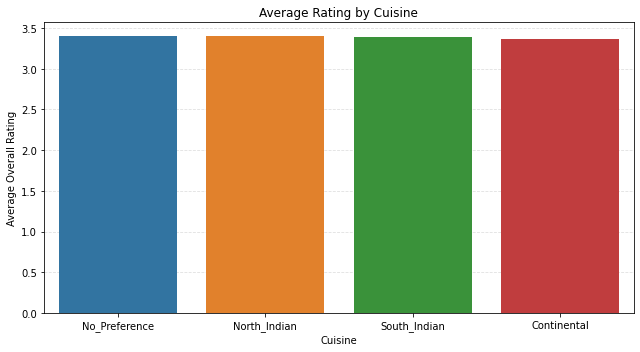

In [489]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=cuisine_rating.reset_index(),
    x="preferred_cuisine",
    y="Avg_Rating"
)

plt.title("Average Rating by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Average Overall Rating")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

In [490]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=cuisine_rating.reset_index(),
    x="preferred_cuisine",
    y="Avg_Rating"
)

plt.title("Average Rating by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Average Overall Rating")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "Average Rating by Cuisine.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

In [491]:
complaint_summary = (
    feedback_df
    .groupby("meal_type")
    ["complaint_flag"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

complaint_summary

meal_type
Lunch        28.587066
Snacks       27.661017
Dinner       27.595258
Breakfast    27.537092
Name: complaint_flag, dtype: float64

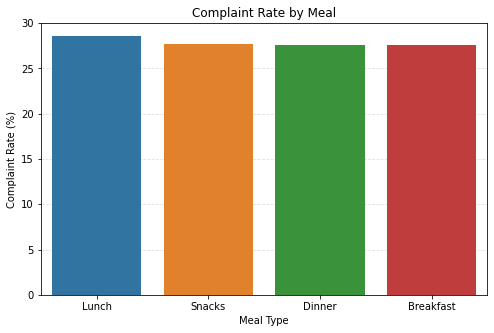

In [492]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=complaint_summary.index,
    y=complaint_summary.values
)

plt.title("Complaint Rate by Meal")
plt.xlabel("Meal Type")
plt.ylabel("Complaint Rate (%)")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.show()

In [493]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=complaint_summary.index,
    y=complaint_summary.values
)

plt.title("Complaint Rate by Meal")
plt.xlabel("Meal Type")
plt.ylabel("Complaint Rate (%)")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "Complaint Rate by Meal.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Satisfaction Drivers Analysis

In [494]:
rating_corr = (
    feedback_df[
        [
            "overall_rating",
            "taste_rating",
            "freshness_rating",
            "hygiene_rating",
            "smell_rating"
        ]
    ]
    .corr()
)

rating_corr

,overall_rating,taste_rating,freshness_rating,hygiene_rating,smell_rating
overall_rating,1.000000,0.002038,0.008645,0.002215,-0.006793
taste_rating,0.002038,1.000000,0.028969,0.001756,0.100069
freshness_rating,0.008645,0.028969,1.000000,-0.004277,0.016786
hygiene_rating,0.002215,0.001756,-0.004277,1.000000,-0.010305
smell_rating,-0.006793,0.100069,0.016786,-0.010305,1.000000


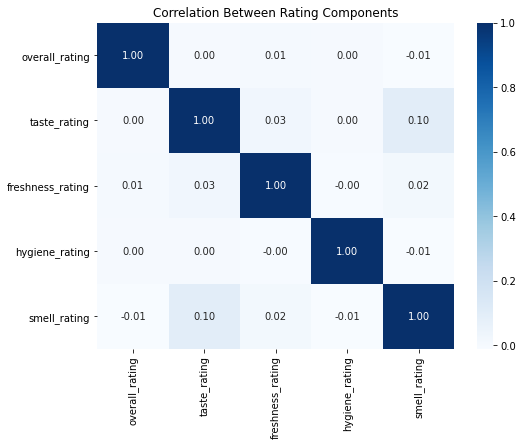

In [495]:
plt.figure(figsize=(8,6))

sns.heatmap(
    rating_corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title(
    "Correlation Between Rating Components"
)

plt.show()

In [496]:
plt.figure(figsize=(8,6))

sns.heatmap(
    rating_corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title(
    "Correlation Between Rating Components"
)

plt.tight_layout()

plt.savefig(
    "Correlation Between Rating Components.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
### for students_df

#### Department Distribution

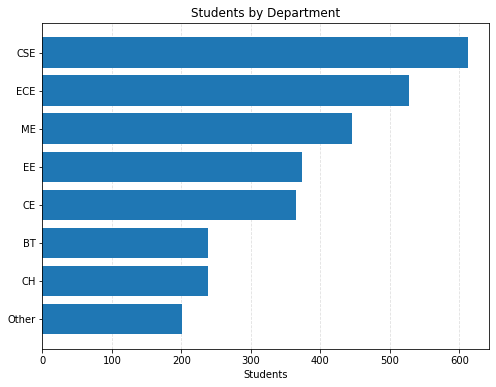

In [497]:
dept_dist = (
    students_df["department"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(8,6))

plt.barh(
    dept_dist.index,
    dept_dist.values
)

plt.title("Students by Department")
plt.xlabel("Students")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.show()

In [498]:
dept_dist = (
    students_df["department"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(8,6))

plt.barh(
    dept_dist.index,
    dept_dist.values
)

plt.title("Students by Department")
plt.xlabel("Students")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "Students by Department.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Dietary Preference Distribution

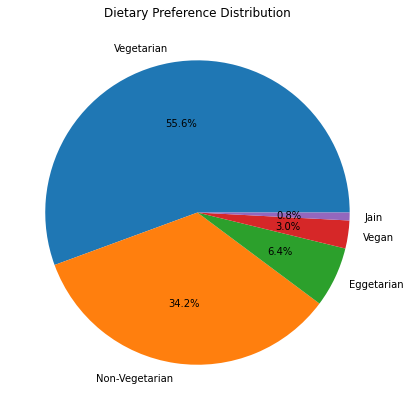

In [499]:
diet_dist = (
    students_df["diet_group"]
    .value_counts()
)

plt.figure(figsize=(7,7))

plt.pie(
    diet_dist.values,
    labels=diet_dist.index,
    autopct="%1.1f%%"
)

plt.title("Dietary Preference Distribution")

plt.show()

In [500]:
diet_dist = (
    students_df["diet_group"]
    .value_counts()
)

plt.figure(figsize=(7,7))

plt.pie(
    diet_dist.values,
    labels=diet_dist.index,
    autopct="%1.1f%%"
)

plt.title("Dietary Preference Distribution")

plt.tight_layout()

plt.savefig(
    "Dietary Preference Distribution.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Home Region Distribution

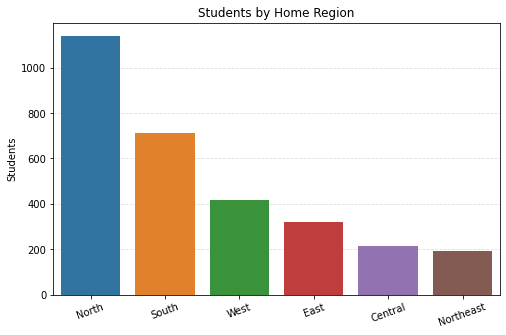

In [501]:
region_dist = (
    students_df["home_region"]
    .value_counts()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_dist.index,
    y=region_dist.values
)

plt.title("Students by Home Region")

plt.ylabel("Students")

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.show()

In [502]:
region_dist = (
    students_df["home_region"]
    .value_counts()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_dist.index,
    y=region_dist.values
)

plt.title("Students by Home Region")

plt.ylabel("Students")

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "Students by Home Region.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Attendance Category Distribution

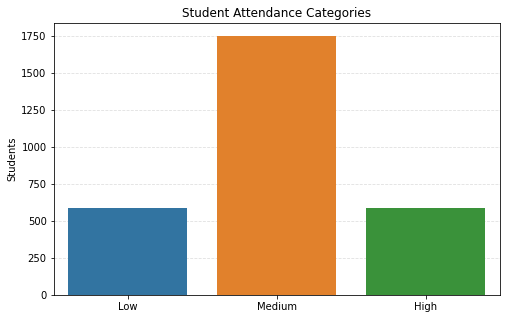

In [503]:
attendance_dist = (
    students_df["attendance_category"]
    .value_counts()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=attendance_dist.index,
    y=attendance_dist.values
)

plt.title("Student Attendance Categories")

plt.ylabel("Students")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.show()

In [504]:
attendance_dist = (
    students_df["attendance_category"]
    .value_counts()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=attendance_dist.index,
    y=attendance_dist.values
)

plt.title("Student Attendance Categories")

plt.ylabel("Students")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "Student Attendance Categories.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Distance Category Distribution

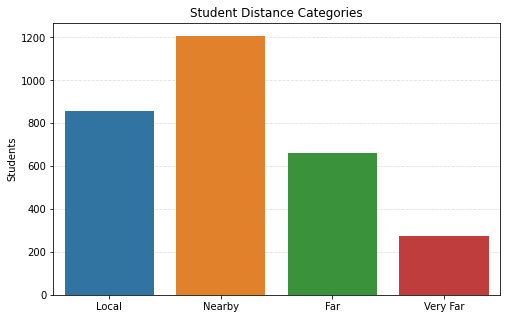

In [505]:
distance_dist = (
    students_df["distance_category"]
    .value_counts()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=distance_dist.index,
    y=distance_dist.values
)

plt.title("Student Distance Categories")

plt.ylabel("Students")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.show()

In [506]:
distance_dist = (
    students_df["distance_category"]
    .value_counts()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=distance_dist.index,
    y=distance_dist.values
)

plt.title("Student Distance Categories")

plt.ylabel("Students")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "Student Distance Categories.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
#### Taste Preference Distribution

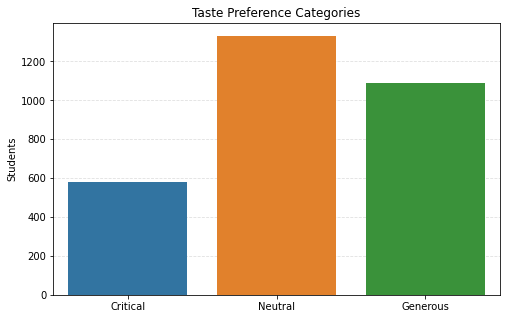

In [507]:
taste_dist = (
    students_df["taste_preference_category"]
    .value_counts()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=taste_dist.index,
    y=taste_dist.values
)

plt.title("Taste Preference Categories")

plt.ylabel("Students")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.show()

In [508]:
taste_dist = (
    students_df["taste_preference_category"]
    .value_counts()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=taste_dist.index,
    y=taste_dist.values
)

plt.title("Taste Preference Categories")

plt.ylabel("Students")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "Taste Preference Categories.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

***
### Cross-Dataset Analysis

#### Rating vs Waste

In [509]:
menu_rating = (
    feedback_df
    .groupby("menu_item")
    ["overall_rating"]
    .mean()
    .reset_index()
)

menu_waste = (
    waste_df
    .groupby("menu_item")
    ["food_wasted_kg"]
    .mean()
    .reset_index()
)

In [510]:
rating_waste = (
    menu_rating
    .merge(
        menu_waste,
        on="menu_item",
        how="inner"
    )
)

In [511]:
rating_waste[
    ["overall_rating", "food_wasted_kg"]
].corr()

,overall_rating,food_wasted_kg
overall_rating,1.000000,0.294928
food_wasted_kg,0.294928,1.000000


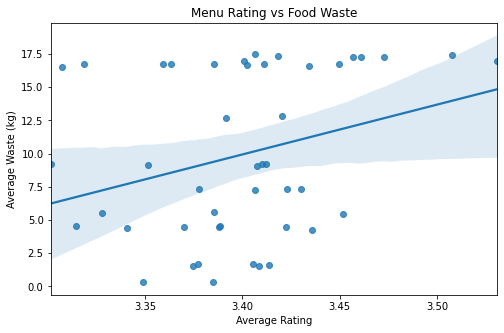

In [512]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=rating_waste,
    x="overall_rating",
    y="food_wasted_kg"
)

plt.title(
    "Menu Rating vs Food Waste"
)

plt.xlabel("Average Rating")

plt.ylabel("Average Waste (kg)")

plt.show()

In [555]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=rating_waste,
    x="overall_rating",
    y="food_wasted_kg"
)

plt.title(
    "Menu Rating vs Food Waste"
)

plt.xlabel("Average Rating")

plt.ylabel("Average Waste (kg)")

plt.tight_layout()

plt.savefig(
    "Menu Rating vs Food Waste.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

#### Menu Performance Matrix

In [514]:
menu_rating = (
    feedback_df
    .groupby("menu_item")
    ["overall_rating"]
    .mean()
    .reset_index()
)

menu_waste = (
    waste_df
    .groupby("menu_item")
    ["food_wasted_kg"]
    .mean()
    .reset_index()
)

menu_cost = (
    waste_df
    .groupby("menu_item")
    ["total_cost_inr"]
    .mean()
    .reset_index()
)

In [515]:
menu_matrix = (
    menu_rating
    .merge(menu_waste, on="menu_item")
    .merge(menu_cost, on="menu_item")
)

menu_matrix.head()

,menu_item,overall_rating,food_wasted_kg,total_cost_inr
0,Aloo Dum,3.418301,17.376826,1928.308136
1,Aloo Gobi,3.359264,16.762286,2078.614000
2,Aloo Paratha,3.412221,9.219704,2110.195246
3,Baingan Bharta,3.507607,17.402918,2550.606140
4,Bhel Puri,3.451550,5.466437,3022.087353


In [516]:
rating_cutoff = menu_matrix["overall_rating"].median()

waste_cutoff = menu_matrix["food_wasted_kg"].median()

print("Rating Cutoff:", rating_cutoff)
print("Waste Cutoff:", waste_cutoff)

Rating Cutoff: 3.4051825677267376
Waste Cutoff: 9.171482857142854


In [517]:
conditions = [
    (
        (menu_matrix["overall_rating"] >= rating_cutoff)
        &
        (menu_matrix["food_wasted_kg"] < waste_cutoff)
    ),

    (
        (menu_matrix["overall_rating"] >= rating_cutoff)
        &
        (menu_matrix["food_wasted_kg"] >= waste_cutoff)
    ),

    (
        (menu_matrix["overall_rating"] < rating_cutoff)
        &
        (menu_matrix["food_wasted_kg"] < waste_cutoff)
    ),

    (
        (menu_matrix["overall_rating"] < rating_cutoff)
        &
        (menu_matrix["food_wasted_kg"] >= waste_cutoff)
    )
]

choices = [
    "Star Performer",
    "Portion Issue",
    "Niche Item",
    "Immediate Attention"
]

menu_matrix["performance_segment"] = np.select(
    conditions,
    choices
)

In [518]:
menu_matrix["performance_segment"].value_counts()

Portion Issue          13
Niche Item             12
Immediate Attention    10
Star Performer         10
Name: performance_segment, dtype: int64

In [519]:
# %pip install --user --upgrade matplotlib

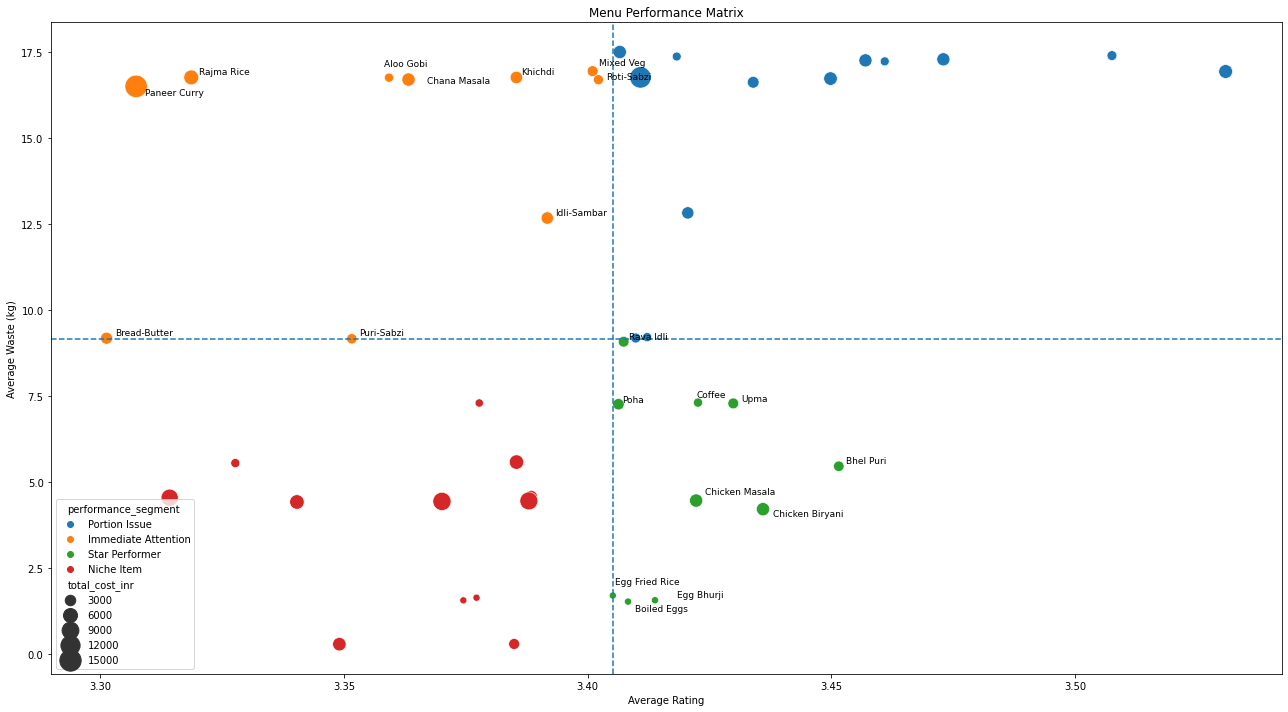

In [520]:
from adjustText import adjust_text

plt.figure(figsize=(18, 10))

sns.scatterplot(
    data=menu_matrix,
    x="overall_rating",
    y="food_wasted_kg",
    hue="performance_segment",
    size="total_cost_inr",
    sizes=(50,500)
)

label_df = menu_matrix[
    menu_matrix["performance_segment"].isin(
        ["Star Performer", "Immediate Attention"]
    )
]

texts = []

for _, row in label_df.iterrows():

    text = plt.text(
        row["overall_rating"],
        row["food_wasted_kg"],
        row["menu_item"],
        fontsize=9
    )

    texts.append(text)

# adjust_text(
#     texts,
#     expand_points=(2, 2),
#     expand_text=(2, 2),
#     force_points=0.5,
#     force_text=1.5,
#     arrowprops=dict(
#         arrowstyle="-",
#         color="gray",
#         lw=0.5
#     )
# )

adjust_text(texts)

plt.axvline(
    rating_cutoff,
    linestyle="--"
)

plt.axhline(
    waste_cutoff,
    linestyle="--"
)

plt.title(
    "Menu Performance Matrix"
)

plt.xlabel("Average Rating")

plt.ylabel("Average Waste (kg)")

plt.tight_layout()

plt.show()

In [556]:
from adjustText import adjust_text

plt.figure(figsize=(18, 10))

sns.scatterplot(
    data=menu_matrix,
    x="overall_rating",
    y="food_wasted_kg",
    hue="performance_segment",
    size="total_cost_inr",
    sizes=(50,500)
)

label_df = menu_matrix[
    menu_matrix["performance_segment"].isin(
        ["Star Performer", "Immediate Attention"]
    )
]

texts = []

for _, row in label_df.iterrows():

    text = plt.text(
        row["overall_rating"],
        row["food_wasted_kg"],
        row["menu_item"],
        fontsize=9
    )

    texts.append(text)

# adjust_text(
#     texts,
#     expand_points=(2, 2),
#     expand_text=(2, 2),
#     force_points=0.5,
#     force_text=1.5,
#     arrowprops=dict(
#         arrowstyle="-",
#         color="gray",
#         lw=0.5
#     )
# )

adjust_text(texts)

plt.axvline(
    rating_cutoff,
    linestyle="--"
)

plt.axhline(
    waste_cutoff,
    linestyle="--"
)

plt.title(
    "Menu Performance Matrix"
)

plt.xlabel("Average Rating")

plt.ylabel("Average Waste (kg)")

plt.tight_layout()

plt.savefig(
    "Menu Performance Matrix.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

#### Exam Impact Analysis

In [522]:
exam_attendance = (
    attendance_df
    .groupby("is_exam_day")
    ["attendance_percentage"]
    .agg(["mean", "median", "count"])
    .round(2)
)

exam_attendance

,mean,median,count
is_exam_day,,,
False,44.11,41.33,18072
True,43.17,41.62,3840


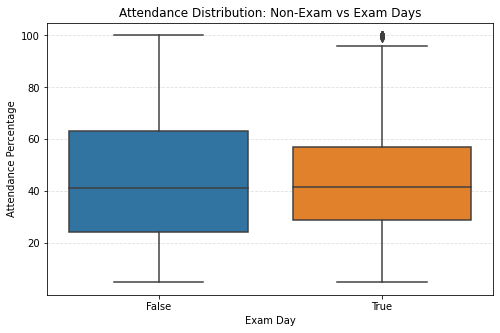

In [523]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=attendance_df,
    x="is_exam_day",
    y="attendance_percentage"
)

plt.title("Attendance Distribution: Non-Exam vs Exam Days")

plt.xlabel("Exam Day")
plt.ylabel("Attendance Percentage")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.show()

In [524]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=attendance_df,
    x="is_exam_day",
    y="attendance_percentage"
)

plt.title("Attendance Distribution: Non-Exam vs Exam Days")

plt.xlabel("Exam Day")
plt.ylabel("Attendance Percentage")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "Attendance Distribution - Non-Exam vs Exam Days.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

In [525]:
exam_waste = (
    waste_df
    .groupby("is_exam_day")
    ["food_wasted_kg"]
    .agg(["mean", "median", "count"])
    .round(2)
)

exam_waste

,mean,median,count
is_exam_day,,,
False,9.76,7.29,93369
True,8.08,5.93,19856


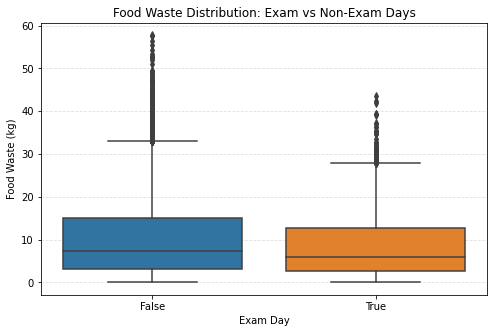

In [526]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=waste_df,
    x="is_exam_day",
    y="food_wasted_kg"
)

plt.title("Food Waste Distribution: Exam vs Non-Exam Days")

plt.xlabel("Exam Day")
plt.ylabel("Food Waste (kg)")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.show()

In [527]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=waste_df,
    x="is_exam_day",
    y="food_wasted_kg"
)

plt.title("Food Waste Distribution: Exam vs Non-Exam Days")

plt.xlabel("Exam Day")
plt.ylabel("Food Waste (kg)")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    "Food Waste Distribution - Exam vs Non-Exam Days.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)

plt.close()

In [528]:
exam_summary = pd.DataFrame({
    "Attendance (%)": attendance_df.groupby("is_exam_day")["attendance_percentage"].mean(),
    "Waste (kg)": waste_df.groupby("is_exam_day")["food_wasted_kg"].mean()
}).round(2)

exam_summary

,Attendance (%),Waste (kg)
is_exam_day,,
False,44.11,9.76
True,43.17,8.08


---
# Insights Obtained

In [529]:
insights = pd.DataFrame(
    columns=[
        "Category",
        "Observation",
        "Business_Insight",
        "Recommendation",
        "Priority"
    ]
)

In [530]:
#insight_1
highest_waste_meal = (
    waste_df.groupby("meal_type")["food_wasted_kg"]
    .sum()
    .idxmax()
)

highest_waste_value = (
    waste_df.groupby("meal_type")["food_wasted_kg"]
    .sum()
    .max()
)

insights.loc[len(insights)] = [
    "Waste",
    f"{highest_waste_meal} generated the highest total waste ({highest_waste_value:,.0f} kg).",
    "A significant share of food waste originates from a single meal period.",
    f"Improve forecasting and batch preparation during {highest_waste_meal}.",
    "High"
]

In [531]:
#insight_2
avg_waste_pct = waste_df["waste_percentage"].mean()

insights.loc[len(insights)] = [
    "Waste",
    f"Average food waste percentage was {avg_waste_pct:.2f}%.",
    "A considerable portion of prepared food is not consumed.",
    "Implement demand forecasting and portion optimization.",
    "High"
]

In [532]:
#insight_3
menu = (
    waste_df.groupby("menu_item")["food_wasted_kg"]
    .mean()
    .idxmax()
)

waste = (
    waste_df.groupby("menu_item")["food_wasted_kg"]
    .mean()
    .max()
)

insights.loc[len(insights)] = [
    "Waste",
    f"{menu} recorded the highest average waste ({waste:.2f} kg).",
    "This menu item may suffer from low acceptance or overproduction.",
    "Review demand and serving quantity for this item.",
    "High"
]

In [533]:
#insight_4
hall = (
    waste_df.groupby("mess_hall_id")["food_wasted_kg"]
    .mean()
    .idxmin()
)

insights.loc[len(insights)] = [
    "Operations",
    f"{hall} recorded the lowest average food waste.",
    "Operational practices in this mess hall appear more efficient.",
    "Benchmark and replicate best practices across other halls.",
    "Medium"
]

In [534]:
#insight_5
avg_attendance = (
    attendance_df["attendance_percentage"]
    .mean()
)

insights.loc[len(insights)] = [
    "Attendance",
    f"Average meal attendance was {avg_attendance:.2f}%.",
    "Attendance levels determine meal demand and preparation requirements.",
    "Use attendance trends for demand forecasting.",
    "High"
]

In [535]:
#insight_6
meal = (
    attendance_df.groupby("meal_type")
    ["attendance_percentage"]
    .mean()
    .idxmax()
)

value = (
    attendance_df.groupby("meal_type")
    ["attendance_percentage"]
    .mean()
    .max()
)

insights.loc[len(insights)] = [
    "Attendance",
    f"{meal} recorded the highest attendance ({value:.2f}%).",
    "Student participation is strongest during this meal period.",
    "Prioritize service quality during this meal.",
    "Medium"
]

In [536]:
#insight_7
corr = attendance_df[
    ["rainfall_mm","attendance_percentage"]
].corr().iloc[0,1]

insights.loc[len(insights)] = [
    "Attendance",
    f"Rainfall and attendance showed a correlation of {corr:.2f}.",
    "Weather conditions influence student dining behavior.",
    "Adjust meal preparation during adverse weather.",
    "Medium"
]

In [537]:
# insight_8
exam_att = (
    attendance_df.groupby("is_exam_day")
    ["attendance_percentage"]
    .mean()
)

insights.loc[len(insights)] = [
    "Attendance",
    f"Attendance on exam days averaged {exam_att.get(True, np.nan):.2f}% compared to {exam_att.get(False, np.nan):.2f}% on non-exam days.",
    "Academic schedules influence dining demand.",
    "Incorporate academic calendar data into forecasting models.",
    "High"
]

In [538]:
# insight_9
rating = feedback_df["overall_rating"].mean()

insights.loc[len(insights)] = [
    "Feedback",
    f"Average overall rating was {rating:.2f}/5.",
    "Students are moderately satisfied with mess services.",
    "Focus on key dissatisfaction drivers to improve ratings.",
    "High"
]

In [539]:
# insight_10
attributes = [
    "taste_rating",
    "freshness_rating",
    "hygiene_rating",
    "smell_rating"
]

best = (
    feedback_df[attributes]
    .mean()
    .idxmax()
)

best_score = (
    feedback_df[attributes]
    .mean()
    .max()
)

insights.loc[len(insights)] = [
    "Feedback",
    f"{best} received the highest average score ({best_score:.2f}).",
    "This is currently the strongest aspect of food service quality.",
    "Maintain existing standards in this area.",
    "Low"
]

In [540]:
# insight_11
worst = (
    feedback_df[attributes]
    .mean()
    .idxmin()
)

worst_score = (
    feedback_df[attributes]
    .mean()
    .min()
)

insights.loc[len(insights)] = [
    "Feedback",
    f"{worst} received the lowest average score ({worst_score:.2f}).",
    "This factor is driving dissatisfaction.",
    "Prioritize improvements in this area.",
    "High"
]

In [541]:
# insight_12
complaint_rate = (
    feedback_df["complaint_flag"]
    .mean() * 100
)

insights.loc[len(insights)] = [
    "Feedback",
    f"Overall complaint rate was {complaint_rate:.2f}%.",
    "A significant share of students report service issues.",
    "Investigate recurring complaint categories.",
    "High"
]

In [542]:
# insight_13
diet = (
    students_df["diet_group"]
    .value_counts()
    .idxmax()
)

pct = (
    students_df["diet_group"]
    .value_counts(normalize=True)
    .max() * 100
)

insights.loc[len(insights)] = [
    "Students",
    f"{diet} students represent {pct:.1f}% of the student population.",
    "Menu planning should align with dominant dietary preferences.",
    "Prioritize menu offerings for the largest dietary segment.",
    "Medium"
]

In [543]:
# insight_14
cat = (
    students_df["attendance_category"]
    .value_counts()
    .idxmax()
)

insights.loc[len(insights)] = [
    "Students",
    f"Most students belong to the {cat} attendance category.",
    "Student attendance behavior is concentrated in one segment.",
    "Use segmentation for targeted engagement strategies.",
    "Low"
]

In [544]:
# insight_15
corr = rating_waste[
    ["overall_rating","food_wasted_kg"]
].corr().iloc[0,1]

insights.loc[len(insights)] = [
    "Cross Analysis",
    f"Menu ratings and food waste showed a correlation of {corr:.2f}.",
    "Student satisfaction may influence food consumption behavior.",
    "Monitor poorly rated menu items for waste reduction opportunities.",
    "High"
]

In [545]:
# insight_16
star_count = (
    menu_matrix["performance_segment"]
    .eq("Star Performer")
    .sum()
)

insights.loc[len(insights)] = [
    "Cross Analysis",
    f"{star_count} menu items were classified as Star Performers.",
    "These items achieve both high satisfaction and low waste.",
    "Use them as benchmarks for future menu design.",
    "High"
]

In [546]:
# insight_17
attention_count = (
    menu_matrix["performance_segment"]
    .eq("Immediate Attention")
    .sum()
)

insights.loc[len(insights)] = [
    "Cross Analysis",
    f"{attention_count} menu items require immediate attention.",
    "These items combine low satisfaction with high waste.",
    "Review recipes, portion sizes, and demand patterns.",
    "High"
]

In [547]:
# insight_18
insights.loc[len(insights)] = [
    "Statistics",
    f"Food waste distribution is positively skewed (skewness = {waste_df['food_wasted_kg'].skew():.2f}).",
    "Most observations have moderate waste, while a few generate exceptionally high waste.",
    "Focus on extreme waste events for maximum impact.",
    "Medium"
]

In [548]:
# insight_19
Q1 = waste_df["food_wasted_kg"].quantile(0.25)
Q3 = waste_df["food_wasted_kg"].quantile(0.75)
IQR = Q3 - Q1

outliers = (
    waste_df["food_wasted_kg"]
    > (Q3 + 1.5*IQR)
).sum()

pct = outliers / len(waste_df) * 100

insights.loc[len(insights)] = [
    "Statistics",
    f"{outliers:,} observations ({pct:.2f}%) were identified as waste outliers.",
    "Extreme waste events are relatively rare.",
    "Investigate high-waste incidents individually.",
    "Medium"
]

In [549]:
# insight_20
std_rating = feedback_df["overall_rating"].std()

insights.loc[len(insights)] = [
    "Statistics",
    f"Overall ratings showed a standard deviation of {std_rating:.2f}.",
    "Student satisfaction is relatively consistent across observations.",
    "Focus on targeted improvements rather than broad changes.",
    "Low"
]

In [550]:
insights

,Category,Observation,Business_Insight,Recommendation,Priority
0,Waste,"Lunch generated the highest total waste (440,3...",A significant share of food waste originates f...,Improve forecasting and batch preparation duri...,High
1,Waste,Average food waste percentage was 18.53%.,A considerable portion of prepared food is not...,Implement demand forecasting and portion optim...,High
2,Waste,Sambar Rice recorded the highest average waste...,This menu item may suffer from low acceptance ...,Review demand and serving quantity for this item.,High
3,Operations,MH_G recorded the lowest average food waste.,Operational practices in this mess hall appear...,Benchmark and replicate best practices across ...,Medium
4,Attendance,Average meal attendance was 43.95%.,Attendance levels determine meal demand and pr...,Use attendance trends for demand forecasting.,High
5,Attendance,Lunch recorded the highest attendance (59.17%).,Student participation is strongest during this...,Prioritize service quality during this meal.,Medium
6,Attendance,Rainfall and attendance showed a correlation o...,Weather conditions influence student dining be...,Adjust meal preparation during adverse weather.,Medium
7,Attendance,Attendance on exam days averaged 43.17% compar...,Academic schedules influence dining demand.,Incorporate academic calendar data into foreca...,High
8,Feedback,Average overall rating was 3.40/5.,Students are moderately satisfied with mess se...,Focus on key dissatisfaction drivers to improv...,High
9,Feedback,hygiene_rating received the highest average sc...,This is currently the strongest aspect of food...,Maintain existing standards in this area.,Low


In [551]:
waste_df.to_csv(
    "waste_analytics.csv",
    index=False
)

attendance_df.to_csv(
    "attendance_analytics.csv",
    index=False
)

feedback_df.to_csv(
    "feedback_analytics.csv",
    index=False
)

students_df.to_csv(
    "students_analytics.csv",
    index=False
)

In [552]:
menu_matrix.to_csv(
    "menu_performance_matrix.csv",
    index=False
)

rating_waste.to_csv(
    "rating_vs_waste.csv",
    index=False
)

insights.to_csv(
    "insights_repository.csv",
    index=False
)